In [50]:
pip install imbalanced-learn


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import logging
from typing import Tuple
from sklearn.base import BaseEstimator
import time
from xgboost import XGBClassifier
from collections import Counter
import scipy.stats
warnings.filterwarnings('ignore')

In [3]:
df1 = pd.read_csv('Converted clients dataset.csv', sep = ';')
df2 = pd.read_csv('Leads dataset.csv', sep =';', encoding='latin1')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
df1.head()

,client_id,flavour,sub_project,item_category,quantity,is_subscription,is_upsell,is_supplement,order_id,item_amount_in_usd,country,gender,age,starting_bmi,starting_weight_in_kg,target_weight_in_kg,quiz_health_state,quiz_linked_to,quiz_poop,quiz_symptoms,quiz_symptoms_two,quiz_allergies,quiz_medical_conditions,quiz_digestive,quiz_physically_active,quiz_leisure,quiz_pregnant,quiz_breastfeeding
0,1,Strawberry,Original,Colonbroom 3 Month OTP,3,No,No,Yes,2551370,137.97,United States,male,33.0,25.055989,83.91,77.11,NaN,NaN,everyday,"mood, sugar, digestion, pain",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Strawberry,Original,Colonbroom 6 Month Subscription,6,Yes,No,Yes,2447652,167.96,United States,female,37.0,22.821003,64.41,58.97,great,bloating,everyday,"stomach, sugar, rectal","digestion, sugar, rectal",lactose,none,none,often,30-60min,no,no
2,3,Strawberry,Original,Colonbroom 6 Month Subscription,6,Yes,No,Yes,2563397,143.93,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Strawberry,Original,Colonbroom 1 Month OTP,1,No,No,Yes,2457912,69.99,United States,male,38.0,29.681764,92.99,83.91,NaN,NaN,everyday,"fungal, sugar",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Strawberry,Original,Colonbroom 3 Month Subscription,3,Yes,No,Yes,2585188,131.97,United States,male,57.0,26.878830,92.99,83.91,good,bloating,twice,none,none,none,none,none,sometimes,30-60min,NaN,NaN


In [5]:
df2.head()

,lead_id,country,gender,age,starting_bmi,starting_weight_in_kg,target_weight_in_kg,quiz_health_state,quiz_linked_to,quiz_poop,quiz_symptoms,quiz_symptoms_two,quiz_allergies,quiz_medical_conditions,quiz_digestive,quiz_physically_active,quiz_pregnant,quiz_breastfeeding,quiz_leisure
0,1,United States,female,50.0,21.078353,52.62,50.80,average,"bloating, weight_gain",everyday,"moodswings, sugar, fatigue",none,other,none,none,moderate,no,no,15-30min
1,2,United Kingdom,female,40.0,26.592798,96.00,77.00,worse,"bloating, weight_gain",everyday,"sugar, moodswings, fatigue",appetite,none,none,gastritis,very_light,no,no,15-30min
2,3,United States,female,49.0,34.739369,91.17,93.89,great,weight_gain,less,none,prefer_not_to_say,citrus,diabetes,prefer_not_to_say,moderate,no,no,little
3,4,United States,female,48.0,31.433264,78.47,69.40,average,"weight_gain, bloating, overeating",everyday,"sugar, fatigue, heartburn",pain,none,none,none,light,no,no,30-60min
4,5,United Kingdom,male,44.0,35.869912,135.00,120.00,good,"bloating, constipation, weight_gain",everyday,sugar,appetite,none,none,IBS,active,NaN,NaN,90+min


In [6]:
df = pd.concat([df1,df2])

In [7]:
df.isna().sum()

client_id                  100000
flavour                    118743
sub_project                100000
item_category              100000
quantity                   100000
is_subscription            100000
is_upsell                  100000
is_supplement              100000
order_id                   100000
item_amount_in_usd         100000
country                         0
gender                       8809
age                          8246
starting_bmi                 8375
starting_weight_in_kg        8375
target_weight_in_kg          8243
quiz_health_state           12141
quiz_linked_to              12049
quiz_poop                   12233
quiz_symptoms               12168
quiz_symptoms_two           12124
quiz_allergies              12074
quiz_medical_conditions     12046
quiz_digestive              12017
quiz_physically_active      11942
quiz_leisure                11921
quiz_pregnant               83058
quiz_breastfeeding          83044
lead_id                    132541
dtype: int64

In [8]:
all_na = df.iloc[:, 11:27].isna().all(axis=1)   # check those values that are na from gender to quiz_breastfeeding (in all columns)
df = df[~all_na]
df.isna().sum()

client_id                   98905
flavour                    116956
sub_project                 98905
item_category               98905
quantity                    98905
is_subscription             98905
is_upsell                   98905
is_supplement               98905
order_id                    98905
item_amount_in_usd          98905
country                         0
gender                       1078
age                           515
starting_bmi                  644
starting_weight_in_kg         644
target_weight_in_kg           512
quiz_health_state            4410
quiz_linked_to               4318
quiz_poop                    4502
quiz_symptoms                4437
quiz_symptoms_two            4393
quiz_allergies               4343
quiz_medical_conditions      4315
quiz_digestive               4286
quiz_physically_active       4211
quiz_leisure                 4190
quiz_pregnant               75327
quiz_breastfeeding          75313
lead_id                    125905
dtype: int64

### GENDER COLUMN

In [9]:
df.loc[((df['quiz_pregnant'] == 'yes') | (df['quiz_breastfeeding'] == 'yes')) & (df['gender'] == 'male'), 'gender'] = 'female'   # changing gender to female where person is pregnant or breastfeeding
df.loc[df['gender'] =='male', ['quiz_breastfeeding', 'pregnant']] = 'no'

In [10]:
df['gender'].fillna('Unknown', inplace = True)  #1st option
# df.dropna(subset=['gender'], inplace=True)   #2nd option

### AGE COLUMN

In [11]:
df['age'].sort_values(ascending= False).head(7)  #there was only one person in history that has lived >= 120 years

14080    120.0
38740    120.0
6368     120.0
71416    120.0
29750    120.0
77200    120.0
45046    111.0
Name: age, dtype: float64

In [12]:
df.loc[(df['age'] == 120), 'age'] = np.NaN  # changing age equal to 120 to NaN

In [13]:
non_integers = (df['age'].dropna() % 1 != 0)
non_integers.value_counts()   # no values with decimal points

age
False    224289
Name: count, dtype: int64

In [14]:
# df['numeric_column'].fillna(df['numeric_column'].median(), inplace=True)   # fill with median

df['age'].interpolate(method='linear', inplace=True)      # interpolation

# df.dropna(subset=['numeric_column'], inplace=True)     # drop columns


# train_df = df[df['age'].notna()]                     # predictive modelling method
# prediction_df = df[df['age'].isna()]
# features = ['feature1', 'feature2', 'feature3']
# X_train = train_df[features]
# y_train = train_df['numeric_column']
# model = LinearRegression()
# model.fit(X_train, y_train)
# X_predict = prediction_df[features]
# predicted_values = model.predict(X_predict)
# df.loc[df['numeric_column'].isna(), 'numeric_column'] = predicted_values





### STARTING BMI COLUMN & STARTING WEIGHT IN KG

In [15]:
df['starting_bmi'].describe() # no negative values

count    224166.000000
mean         31.373504
std           7.863426
min          10.070000
25%          25.825528
50%          29.831426
75%          35.330000
max         385.690000
Name: starting_bmi, dtype: float64

In [16]:
df['starting_weight_in_kg'].describe()  # no negative values

count    224166.000000
mean         88.876803
std          22.346835
min          39.920000
25%          72.570000
50%          86.180000
75%         102.060000
max         273.516000
Name: starting_weight_in_kg, dtype: float64

In [17]:
df['starting_weight_in_kg'].sort_values(ascending= False).head(10) # possible to observe these values

96250     273.516
125804    252.000
9334      250.000
11858     250.000
5465      249.480
50677     249.480
78779     249.480
3814      249.480
12292     249.480
10926     248.570
Name: starting_weight_in_kg, dtype: float64

In [18]:
df['starting_weight_in_kg'].sort_values(ascending= True).head(10) # possible to observe these values

9424      39.92
3953      39.92
3317      39.92
26877     39.92
8270      39.92
87171     39.92
11515     40.00
10229     40.00
2880      40.00
130840    40.00
Name: starting_weight_in_kg, dtype: float64

In [19]:
df['starting_bmi'].sort_values(ascending= False).head(20)

97340    385.690000
73386    158.502400
11510    121.428571
94713    120.473600
1681     112.244898
75933    107.451428
75934    107.451428
5594     106.095679
2432     106.095679
7898     102.205487
12462    100.649244
272       99.121748
9808      99.111111
16350     98.700800
2521      98.700800
9152      98.484033
10907     98.164820
86164     98.000000
86165     98.000000
5149      95.744249
Name: starting_bmi, dtype: float64

In [20]:
df['starting_bmi'].sort_values(ascending= True).head(5) # BMI below 14 will be regarded to as error, as BMI of less than 18.5 is already underweight.

93664     10.070000
95287     13.030000
101294    13.990000
97996     15.780000
35393     16.936218
Name: starting_bmi, dtype: float64

In [21]:
df.loc[(df['starting_bmi'] > 120), 'starting_bmi'] = np.NaN
df.loc[(df['starting_bmi'] < 14), 'starting_bmi'] = np.NaN

In [22]:
print('The mean of starting_bmi', df['starting_bmi'].mean(), 'The median of starting_bmi', df['starting_bmi'].median())
print('The mean of starting_weight_in_kg', df['starting_weight_in_kg'].mean(), 'The median of starting_weight_in_kg', df['starting_weight_in_kg'].median())
print('Data is not significantly skewed, so we will fill missing values with median')

The mean of starting_bmi 31.370811842342555 The median of starting_bmi 29.831425598
The mean of starting_weight_in_kg 88.87680307004631 The median of starting_weight_in_kg 86.18
Data is not significantly skewed, so we will fill missing values with median


In [23]:
df['starting_bmi'].fillna(df['starting_bmi'].median(), inplace= True)
df['starting_weight_in_kg'].fillna(df['starting_weight_in_kg'].median(), inplace= True)

### TARGET WEIGHT IN KG

In [24]:
df['target_weight_in_kg'].describe()  # we only have non-logical values of 0

count    224298.000000
mean         73.287901
std          15.803083
min           0.000000
25%          61.230000
50%          70.310000
75%          81.650000
max         250.000000
Name: target_weight_in_kg, dtype: float64

In [25]:
df.loc[(df['target_weight_in_kg'] == 0), 'target_weight_in_kg'] = np.NaN    # change 0 values to NaN

In [26]:
print('The mean of target_weight_in_kg', df['target_weight_in_kg'].mean(), 'The median of starting_bmi', df['target_weight_in_kg'].median())
print('Data is not significantly skewed, so we will fill missing values with median')

The mean of target_weight_in_kg 73.29312878429835 The median of starting_bmi 70.31
Data is not significantly skewed, so we will fill missing values with median


In [27]:
df['target_weight_in_kg'].fillna(df['target_weight_in_kg'].median(), inplace = True)

In [28]:
df.isna().sum()

client_id                   98905
flavour                    116956
sub_project                 98905
item_category               98905
quantity                    98905
is_subscription             98905
is_upsell                   98905
is_supplement               98905
order_id                    98905
item_amount_in_usd          98905
country                         0
gender                          0
age                             0
starting_bmi                    0
starting_weight_in_kg           0
target_weight_in_kg             0
quiz_health_state            4410
quiz_linked_to               4318
quiz_poop                    4502
quiz_symptoms                4437
quiz_symptoms_two            4393
quiz_allergies               4343
quiz_medical_conditions      4315
quiz_digestive               4286
quiz_physically_active       4211
quiz_leisure                 4190
quiz_pregnant               75327
quiz_breastfeeding           4132
lead_id                    125905
pregnant      

### QUIZ COLUMNS

In [29]:
quiz_na = df.iloc[:, 16:27].isna().all(axis=1)   # check where we do not have any quiz answers
df = df[~quiz_na]     # drop them as it is not useful to not have any quiz answers data
df.isna().sum()

client_id                   98781
flavour                    116231
sub_project                 98781
item_category               98781
quantity                    98781
is_subscription             98781
is_upsell                   98781
is_supplement               98781
order_id                    98781
item_amount_in_usd          98781
country                         0
gender                          0
age                             0
starting_bmi                    0
starting_weight_in_kg           0
target_weight_in_kg             0
quiz_health_state             481
quiz_linked_to                389
quiz_poop                     573
quiz_symptoms                 508
quiz_symptoms_two             464
quiz_allergies                414
quiz_medical_conditions       386
quiz_digestive                357
quiz_physically_active        282
quiz_leisure                  261
quiz_pregnant               71398
quiz_breastfeeding           1346
lead_id                    122100
pregnant      

In [30]:
df.columns
quiz_col = ['quiz_health_state',
       'quiz_linked_to', 'quiz_poop', 'quiz_symptoms', 'quiz_symptoms_two',
       'quiz_allergies', 'quiz_medical_conditions', 'quiz_digestive',
       'quiz_physically_active', 'quiz_leisure', 'quiz_pregnant',
       'quiz_breastfeeding']

In [31]:
for column in quiz_col:
    df[column].fillna('undisclosed', inplace=True)

df.isna().sum()

client_id                   98781
flavour                    116231
sub_project                 98781
item_category               98781
quantity                    98781
is_subscription             98781
is_upsell                   98781
is_supplement               98781
order_id                    98781
item_amount_in_usd          98781
country                         0
gender                          0
age                             0
starting_bmi                    0
starting_weight_in_kg           0
target_weight_in_kg             0
quiz_health_state               0
quiz_linked_to                  0
quiz_poop                       0
quiz_symptoms                   0
quiz_symptoms_two               0
quiz_allergies                  0
quiz_medical_conditions         0
quiz_digestive                  0
quiz_physically_active          0
quiz_leisure                    0
quiz_pregnant                   0
quiz_breastfeeding              0
lead_id                    122100
pregnant      

### ORDER COLUMNS

In [32]:
df.iloc[:, :10].isna().sum()

client_id              98781
flavour               116231
sub_project            98781
item_category          98781
quantity               98781
is_subscription        98781
is_upsell              98781
is_supplement          98781
order_id               98781
item_amount_in_usd     98781
dtype: int64

In [33]:
order_col = df.columns[1:10]
actually_missing_order_col = []
for i in order_col:
    if df[i].isna().sum() != df['client_id'].isna().sum():
        actually_missing_order_col.append(i)

In [34]:
print(f'While there are many missing values in order information columns, they can mostly be atributed to the fact there was no conversion, and aftet checking if missing values actually correspond to an observation bein a lead, we see missing values only in column {actually_missing_order_col}')
print('consequently we look at the features of those observations in which flavour is "actually missing"')

While there are many missing values in order information columns, they can mostly be atributed to the fact there was no conversion, and aftet checking if missing values actually correspond to an observation bein a lead, we see missing values only in column ['flavour']
consequently we look at the features of those observations in which flavour is "actually missing"


In [35]:
df_flavour = df[(df['flavour'].isna()) & (df['client_id'].notna())]

In [36]:
unflavoured = df_flavour['item_category'].value_counts().index
print(unflavoured)
flavoured = []
for i in unflavoured:
    temp_df = df[df['item_category'] == i]
    if temp_df['flavour'].notna().sum() > 0:
        flavoured.append(i)

Index(['DF Capsules', 'Fat Burners', 'Sugar Cravings', 'DF 6 Month Supply Box',
       'DF 3 Month Supply Box', 'Shipping', 'DF 1 Month Supply Box', 'Shakers',
       'ColonBroom Trial', 'Colonbroom 1 Month OTP',
       'Colonbroom 3 Month Subscription', 'Colonbroom 1 Month Subscription',
       'Colonbroom 3 Month OTP'],
      dtype='object', name='item_category')


In [37]:
flavoured

['Fat Burners',
 'Colonbroom 1 Month OTP',
 'Colonbroom 3 Month Subscription',
 'Colonbroom 1 Month Subscription',
 'Colonbroom 3 Month OTP']

In [38]:
unflavoured = [item for item in unflavoured if item not in flavoured]
for i in flavoured:
    temp_df = df[df['item_category'] == i]
    print(i, temp_df['flavour'].value_counts())
    missing = temp_df['flavour'].isna().sum()
    print(f'{missing} missing values')

Fat Burners flavour
Strawberry    3
Name: count, dtype: int64
3257 missing values
Colonbroom 1 Month OTP flavour
Strawberry    11552
Tropical       3685
Premium         846
Name: count, dtype: int64
150 missing values
Colonbroom 3 Month Subscription flavour
Strawberry    19791
Tropical       6234
Premium        2640
Name: count, dtype: int64
132 missing values
Colonbroom 1 Month Subscription flavour
Strawberry    8087
Tropical      2753
Premium       1452
Name: count, dtype: int64
122 missing values
Colonbroom 3 Month OTP flavour
Strawberry    10328
Tropical       3297
Premium         709
Name: count, dtype: int64
112 missing values


We observe that, even though, as per task description, most flavoured items are colonbroom products, there is an error of 3 instanses of fat burners having flavour too.
We assume that all discrepancies are due to some kind of error, and change all fat burner flavours to none as well as input missing colonbroom flavours as uncertain.

In [39]:
df.loc[df['item_category'] == 'Fat Burners', 'flavour'] = 'None'
df.loc[df['item_category'] == 'Fat Burners', 'flavour'].isna().sum()

0

In [40]:
fill_value = 'uncertain'
df.loc[df['item_category'].str.startswith('ColonBroom') & df['item_category'].notna(), 'flavour'] = fill_value
flavour_counts = df.loc[df['flavour'].isna(), 'item_category'].value_counts()
flavour_counts

item_category
DF Capsules                        4657
Sugar Cravings                     1948
DF 6 Month Supply Box              1692
DF 3 Month Supply Box              1575
Shipping                           1494
DF 1 Month Supply Box              1351
Shakers                             615
Colonbroom 1 Month OTP              150
Colonbroom 3 Month Subscription     132
Colonbroom 1 Month Subscription     122
Colonbroom 3 Month OTP              112
Name: count, dtype: int64

No other colonbroom products are in the missing flavours category so we can simply remove these as the task states that flavours are only aplicable to CB

In [41]:
df.loc[(df['flavour'].isna()) & (df['client_id'].notna()), 'flavour'] = 'none'

In [42]:
df.isna().sum()

client_id                   98781
flavour                     98781
sub_project                 98781
item_category               98781
quantity                    98781
is_subscription             98781
is_upsell                   98781
is_supplement               98781
order_id                    98781
item_amount_in_usd          98781
country                         0
gender                          0
age                             0
starting_bmi                    0
starting_weight_in_kg           0
target_weight_in_kg             0
quiz_health_state               0
quiz_linked_to                  0
quiz_poop                       0
quiz_symptoms                   0
quiz_symptoms_two               0
quiz_allergies                  0
quiz_medical_conditions         0
quiz_digestive                  0
quiz_physically_active          0
quiz_leisure                    0
quiz_pregnant                   0
quiz_breastfeeding              0
lead_id                    122100
pregnant      

# Analysis of buyers and non-buyers characteristics

In [43]:
non_buyers = df.dropna(subset = 'lead_id')
buyers = df.dropna(subset = 'client_id')
non_buyers['buyers'] = 'Non-Buyers'
buyers['buyers'] = 'Buyers'
combined_data = pd.concat([non_buyers, buyers], ignore_index=True)

### Age and Gender analysis

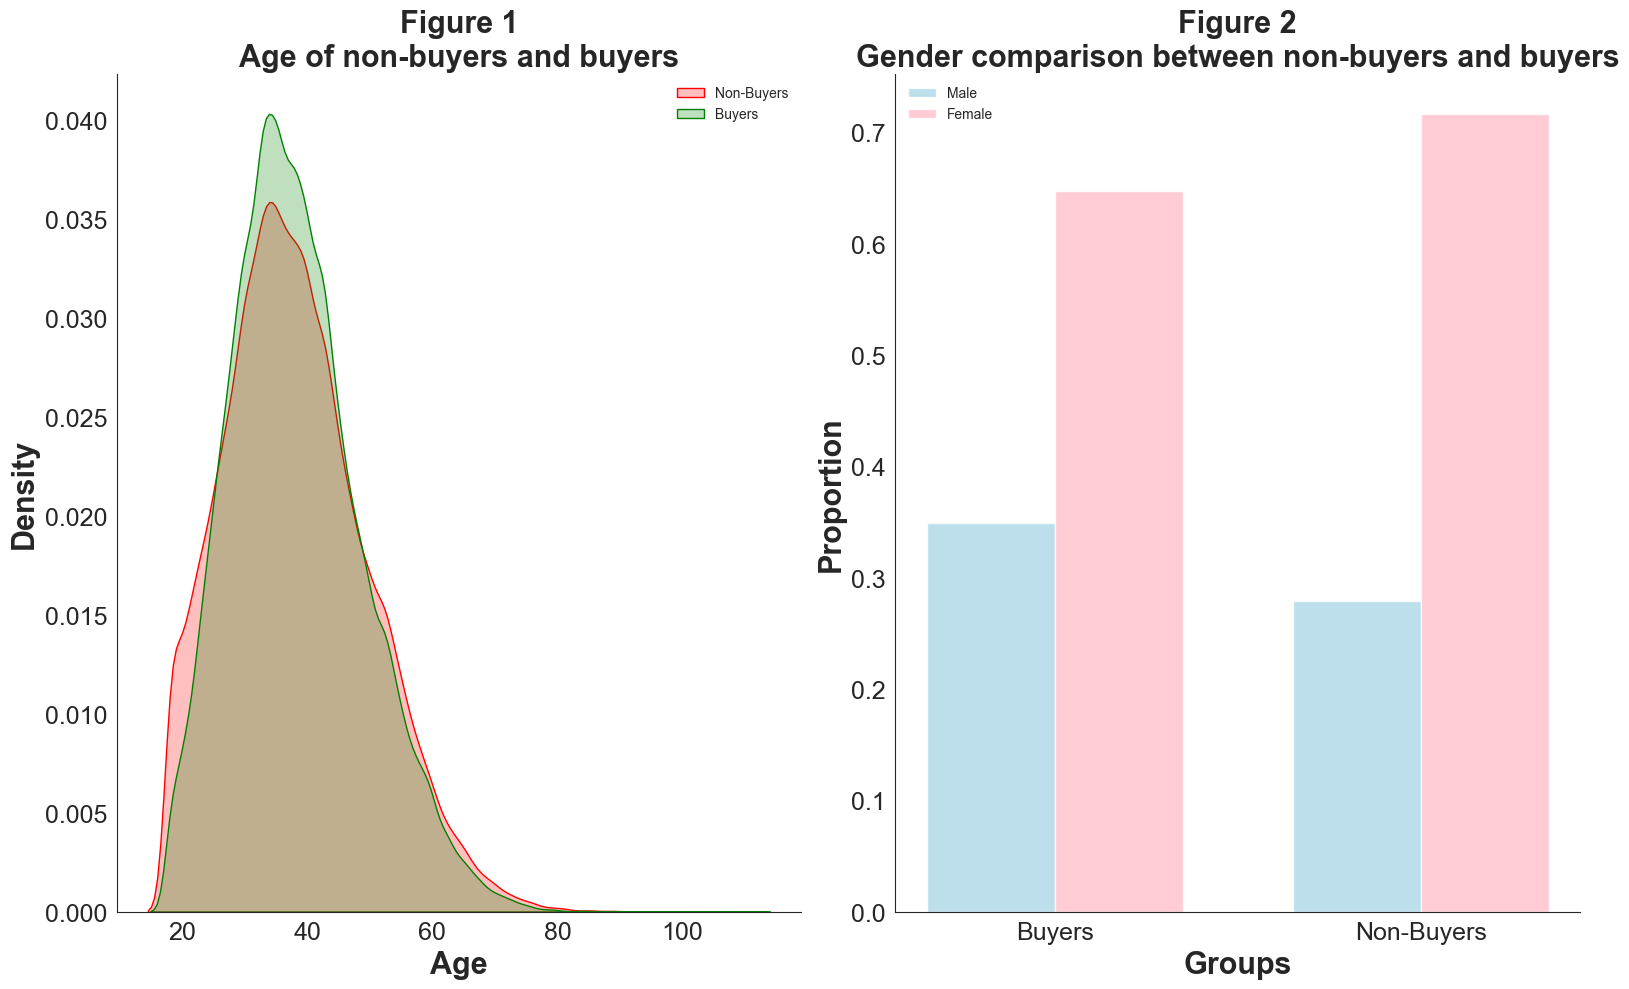

In [44]:
sns.set_style("white")
fig, axs = plt.subplots(1, 2, figsize=(16, 10))

sns.kdeplot(x=non_buyers['age'], fill=True, color='red', ax=axs[0], label='Non-Buyers')
sns.kdeplot(x=buyers['age'], fill=True, color='green', ax=axs[0], label='Buyers')
axs[0].set_title('Figure 1\nAge of non-buyers and buyers', fontweight='bold', fontsize=22)
axs[0].set_xlabel('Age', fontweight='bold', fontsize=22)
axs[0].set_ylabel('Density', fontweight='bold', fontsize=22)
legend = axs[0].legend()
legend.get_frame().set_linewidth(0)

gender_counts = combined_data.groupby('buyers')['gender'].value_counts(normalize=True).rename('Proportion').reset_index()
pivot_data = gender_counts.pivot(index='buyers', columns='gender', values='Proportion')
groups = pivot_data.index
male_proportions = pivot_data['male']
female_proportions = pivot_data['female']
bar_width = 0.35
index = np.arange(len(groups))
axs[1].bar(index, male_proportions, bar_width,
           alpha=0.8,
           color='lightblue',
           label='Male')

axs[1].bar(index + bar_width, female_proportions, bar_width,
           alpha=0.8,
           color='pink',
           label='Female')

axs[1].set_xlabel('Groups', fontweight='bold', fontsize=22)
axs[1].set_ylabel('Proportion', fontweight='bold', fontsize=22)
axs[1].set_title('Figure 2\nGender comparison between non-buyers and buyers', fontweight='bold', fontsize=22)
axs[1].set_xticks(index + bar_width / 2)
axs[1].set_xticklabels(groups)
legend = axs[1].legend()
legend.get_frame().set_linewidth(0)

for ax in axs:
    ax.tick_params(axis='both', which='major', labelsize=18, width=3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()


### Figure 1 shows the density plot of age in groups of buyers and non-buyers. As shown, people of age 30-40 are the majority of both buyers and non-buyers. However, this age group represents a higher proportion of buyers compared to non-buyers. This inclines that individuals between the ages of 30-40 are more dedicated to buying. However, younger individuals take up a significant proportion of non-buyers. All in all, 30-40 age group is the most profitable. 

### Figure 2 indicates the proportion of each gender in two groups of people who buy and those who do not. As indicated in buyers' bars, there are more female buyers than male buyers, but males also represent a significant proportion. On the other hand, females also are majority among those who do not make a purchase. That indicates that company has more female customers. 

### Starting BMI and Starting Weight in kg

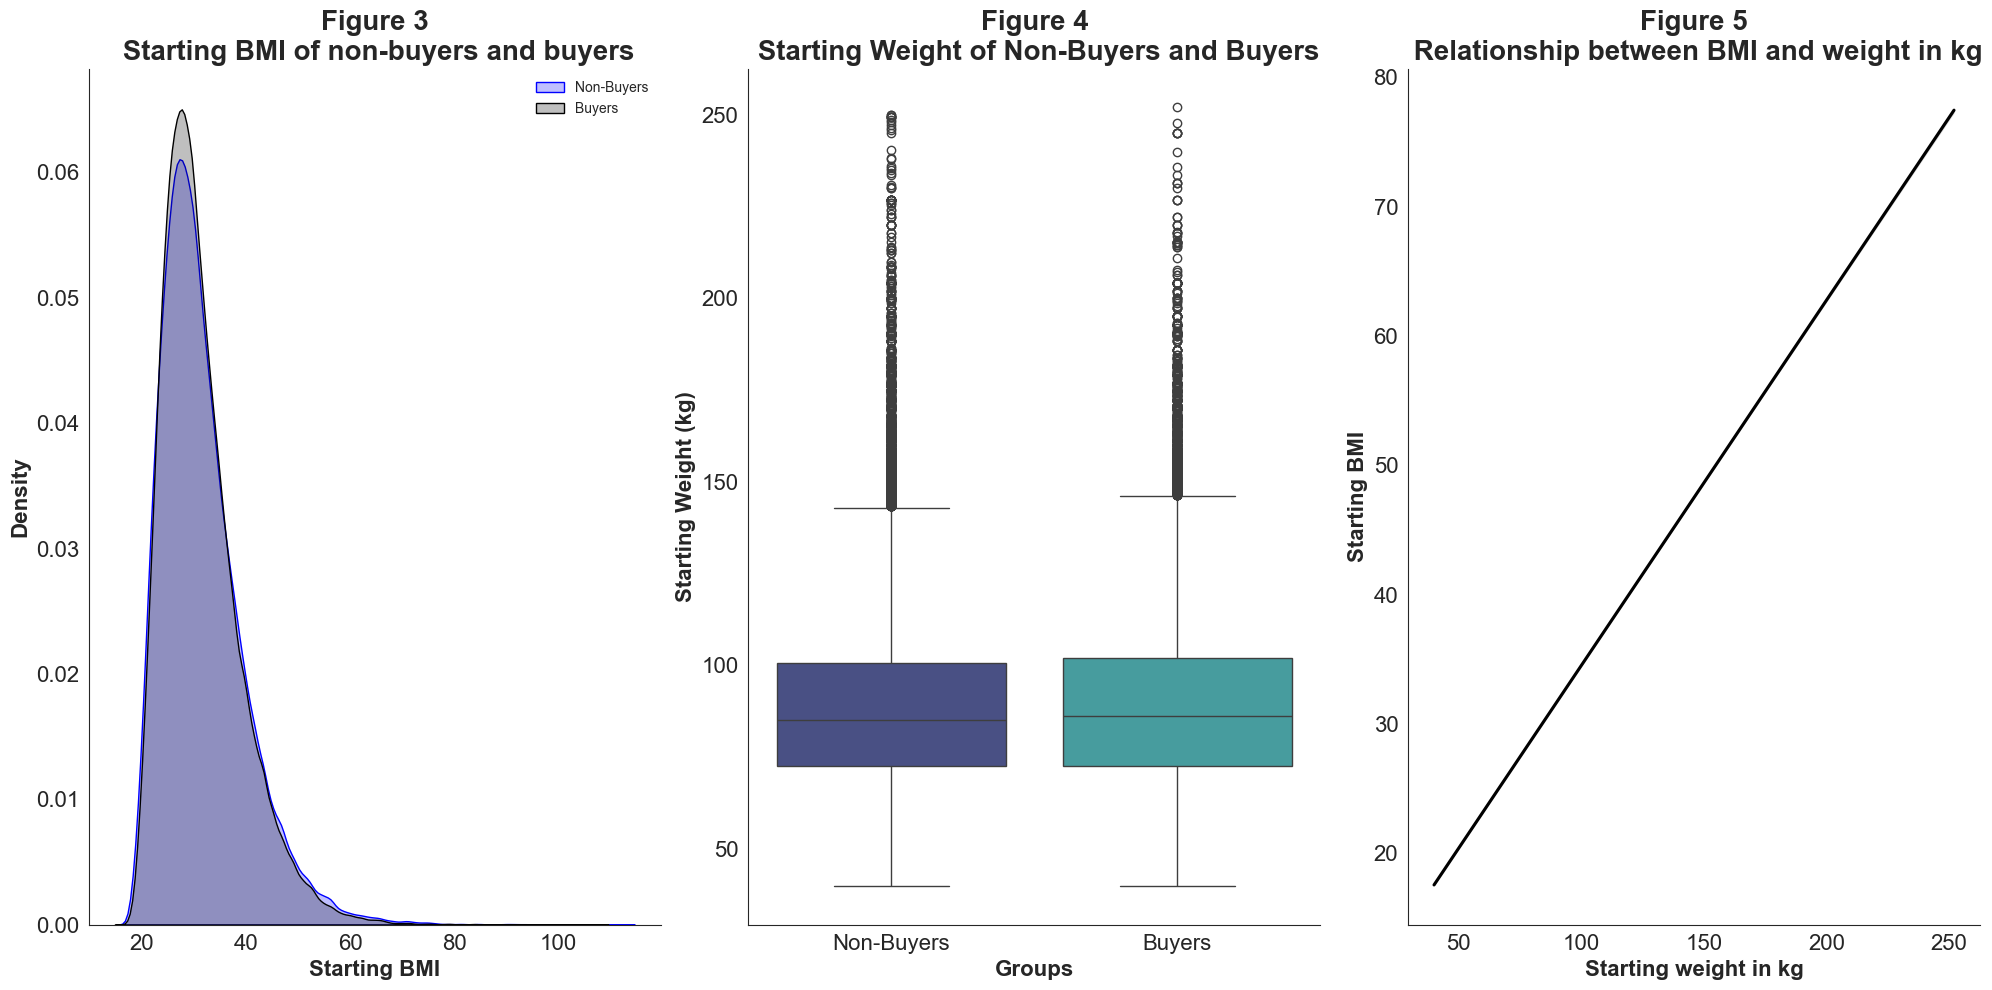

In [45]:
sns.set_style("white")
fig, axs = plt.subplots(1, 3, figsize=(20, 10))

sns.kdeplot(x=non_buyers['starting_bmi'], fill = True, color = 'blue', ax = axs[0], label = 'Non-Buyers')
sns.kdeplot(x=buyers['starting_bmi'], fill = True, color = 'black', ax =axs[0], label = 'Buyers')
axs[0].set_title('Figure 3\n Starting BMI of non-buyers and buyers', fontweight = 'bold', fontsize=20)
axs[0].set_xlabel('Starting BMI', fontweight = 'bold', fontsize=16)
axs[0].set_ylabel('Density', fontweight = 'bold', fontsize=16)
legend = axs[0].legend()
legend.get_frame().set_linewidth(0)

sns.boxplot(x='buyers', y='starting_weight_in_kg', data=combined_data, ax=axs[1], palette='mako')
axs[1].set_title('Figure 4\n Starting Weight of Non-Buyers and Buyers', fontweight = 'bold', fontsize=20)
axs[1].set_xlabel('Groups', fontweight = 'bold', fontsize=16)
axs[1].set_ylabel('Starting Weight (kg)', fontweight = 'bold', fontsize=16)

sns.regplot(x= 'starting_weight_in_kg', y='starting_bmi', data = combined_data, ax= axs[2], color = 'black', scatter = False)
axs[2].set_title('Figure 5\n Relationship between BMI and weight in kg', fontweight = 'bold', fontsize=20)
axs[2].set_xlabel('Starting weight in kg', fontweight = 'bold', fontsize=16)
axs[2].set_ylabel('Starting BMI', fontweight = 'bold', fontsize=16)

for plot in range(0,3):
    axs[plot].tick_params(axis='both', which='major', labelsize=16, width='3')
    axs[plot].spines['top'].set_visible(False)
    axs[plot].spines['right'].set_visible(False)

plt.tight_layout()

### Figure 3 is the density plot for starting BMI between buyers and non-buyers. Two density plots are close to identical, but the people are more probable to be buyers if their BMI is around 30 (overweight). Such BMI takes up the highest proportion of buyers’ data.  

### Figure 4 digs deeper into analysis between weight and buying. It visualizes boxplots of starting weight between two groups. As indicated by the median (horizontal line inside the box) and quartiles (borders of the box), buyers have slightly higher starting weight. However, difference is very small. Both buyers and non-buyers also have significant number of outliers. 

### Figure 5 is the regression plot between BMI and weight in kilograms. We ensure that there is perfect correlation between weight and BMI, so our data is valid. 

### All in all, overweight people have slightly higher likeability of being buyers, but the distribution of peoples’ weight and BMI is very similar among the groups. 

### Target weight

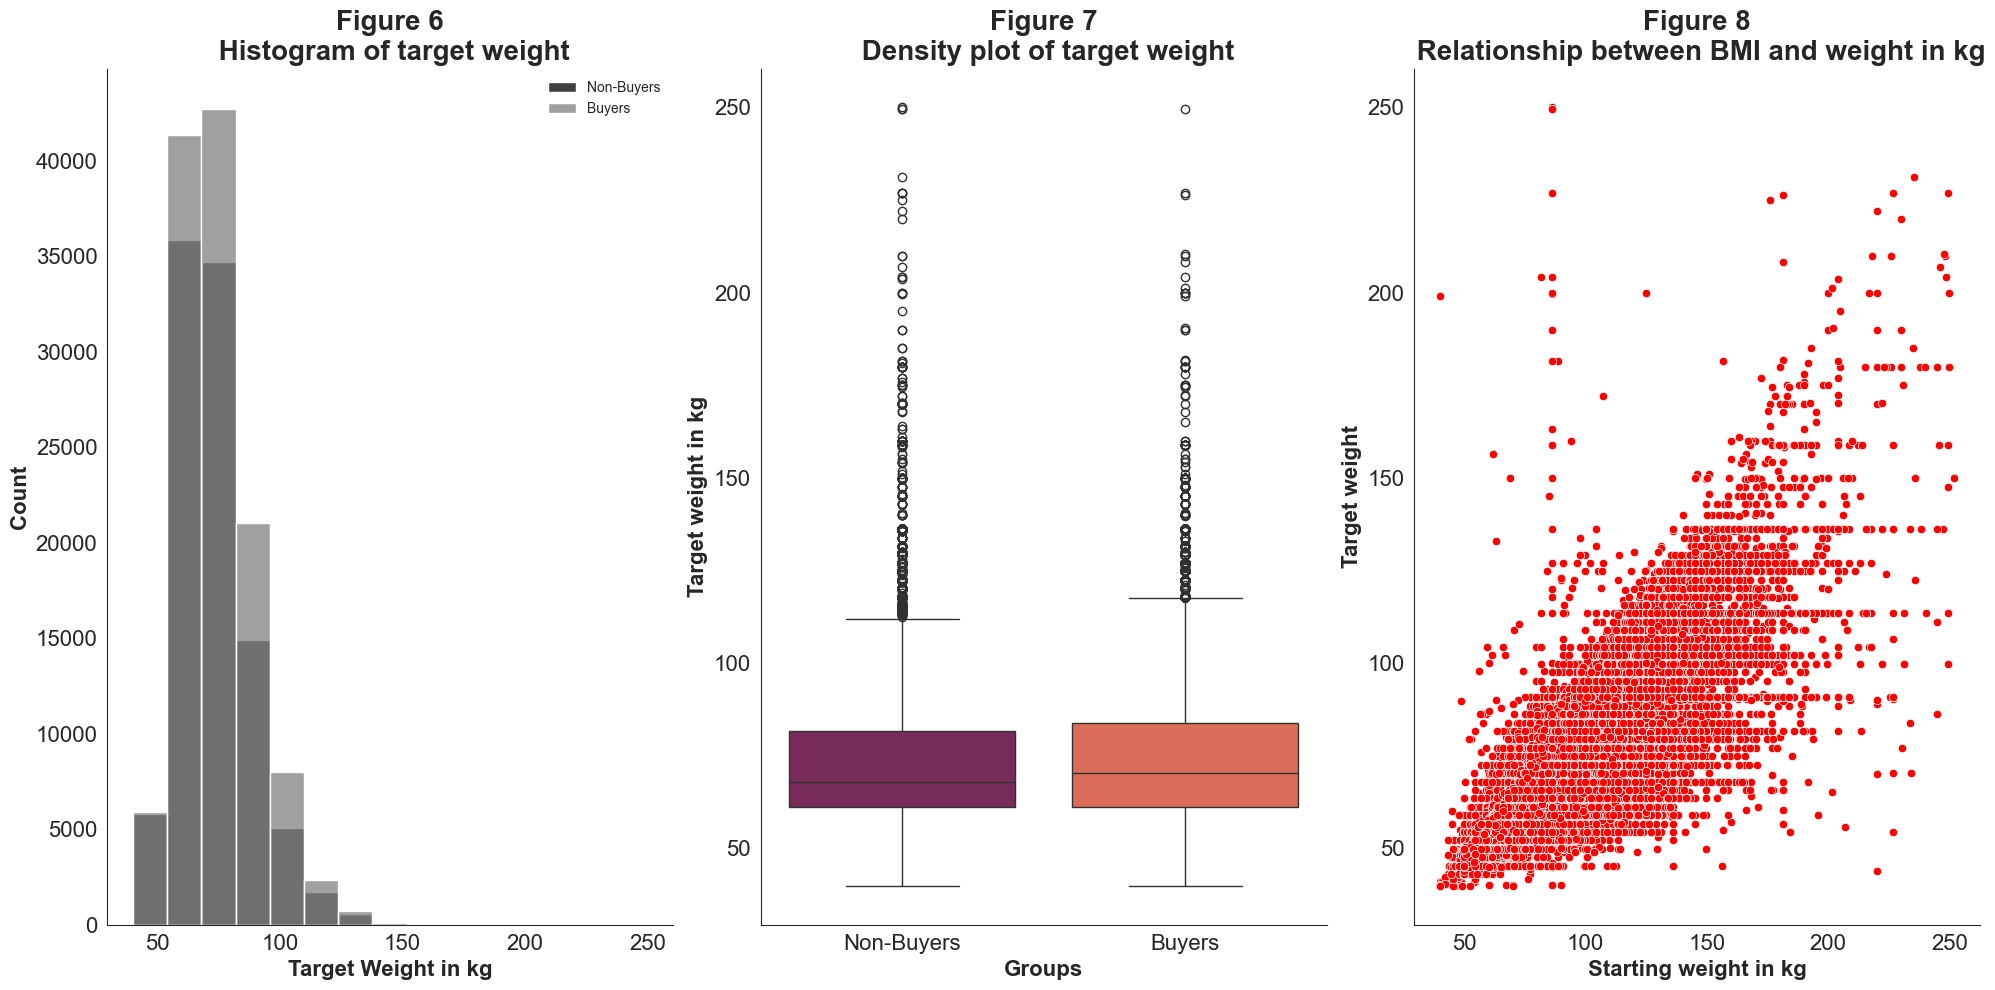

In [46]:
sns.set_style("white")
fig, axs = plt.subplots(1, 3, figsize=(20, 10))

sns.histplot(non_buyers['target_weight_in_kg'], bins = 15, color = 'black', ax=axs[0], label = 'Non-Buyers')
sns.histplot(buyers['target_weight_in_kg'], bins = 15, color = 'gray', ax=axs[0], label = 'Buyers')
axs[0].set_title('Figure 6\n Histogram of target weight', fontweight = 'bold', fontsize=20)
axs[0].set_xlabel('Target Weight in kg', fontweight = 'bold', fontsize=16)
axs[0].set_ylabel('Count', fontweight = 'bold', fontsize=16)
legend = axs[0].legend()
legend.get_frame().set_linewidth(0)

sns.boxplot(x='buyers', y='target_weight_in_kg', data=combined_data, palette='rocket', ax=axs[1])
axs[1].set_title('Figure 7\n Density plot of target weight', fontweight = 'bold', fontsize=20)
axs[1].set_ylabel('Target weight in kg', fontweight = 'bold', fontsize=16)
axs[1].set_xlabel('Groups', fontweight = 'bold', fontsize=16)

sns.scatterplot(x= 'starting_weight_in_kg', y='target_weight_in_kg', data = combined_data, ax= axs[2], color = 'red')
axs[2].set_title('Figure 8\n Relationship between BMI and weight in kg', fontweight = 'bold', fontsize=20)
axs[2].set_xlabel('Starting weight in kg', fontweight = 'bold', fontsize=16)
axs[2].set_ylabel('Target weight', fontweight = 'bold', fontsize=16)

for plot in range(0,3):
    axs[plot].tick_params(axis='both', which='major', labelsize=16, width='3')
    axs[plot].spines['top'].set_visible(False)
    axs[plot].spines['right'].set_visible(False)

plt.tight_layout()

### Figure 6 and 7 continues the analysis of relationship between buying and weight. Two graphs show similar information, but Figure 6 is the histogram and Figure 7 is the boxplot. Two graphs are outputted to understand the relationship better. In Figure 6 we can see that buyers seem to have significantly higher target weight. But it could be due to class imbalance, as there is no bin where non-buyers have more count. Figure 7 (which accounts for the class imbalance) is the boxplots of buyers and non-buyers and their distribution of target weight data. Similarly, as in Figure 4, we can see that buyers have slightly higher median and quartiles. It indicates that target weight of buyers seems to be little bit higher than non-buyers. Once again, both groups have many significant outliers, so there are surely people who are not buying and have high target weight. 

### Figure 8 is a scatterplot between starting weight and target weight. There is almost perfect collinearity between variables, as when starting weight increases, target weight does too by very similar proportion. But there are some outliers. Some lightweight people want to gain a lot of weight and some heavyweights want to lose plenty of kilograms. However, the outliers take up only a small part of data, so it can be concluded that people who weight more, surely have higher target weight. 

### All in all, buyers are concluded to have higher target weight (they have higher starting weight as well, as was concluded in Figure 8). But the difference between people who buy and those who do not is significantly small, as the distribution is similar. 

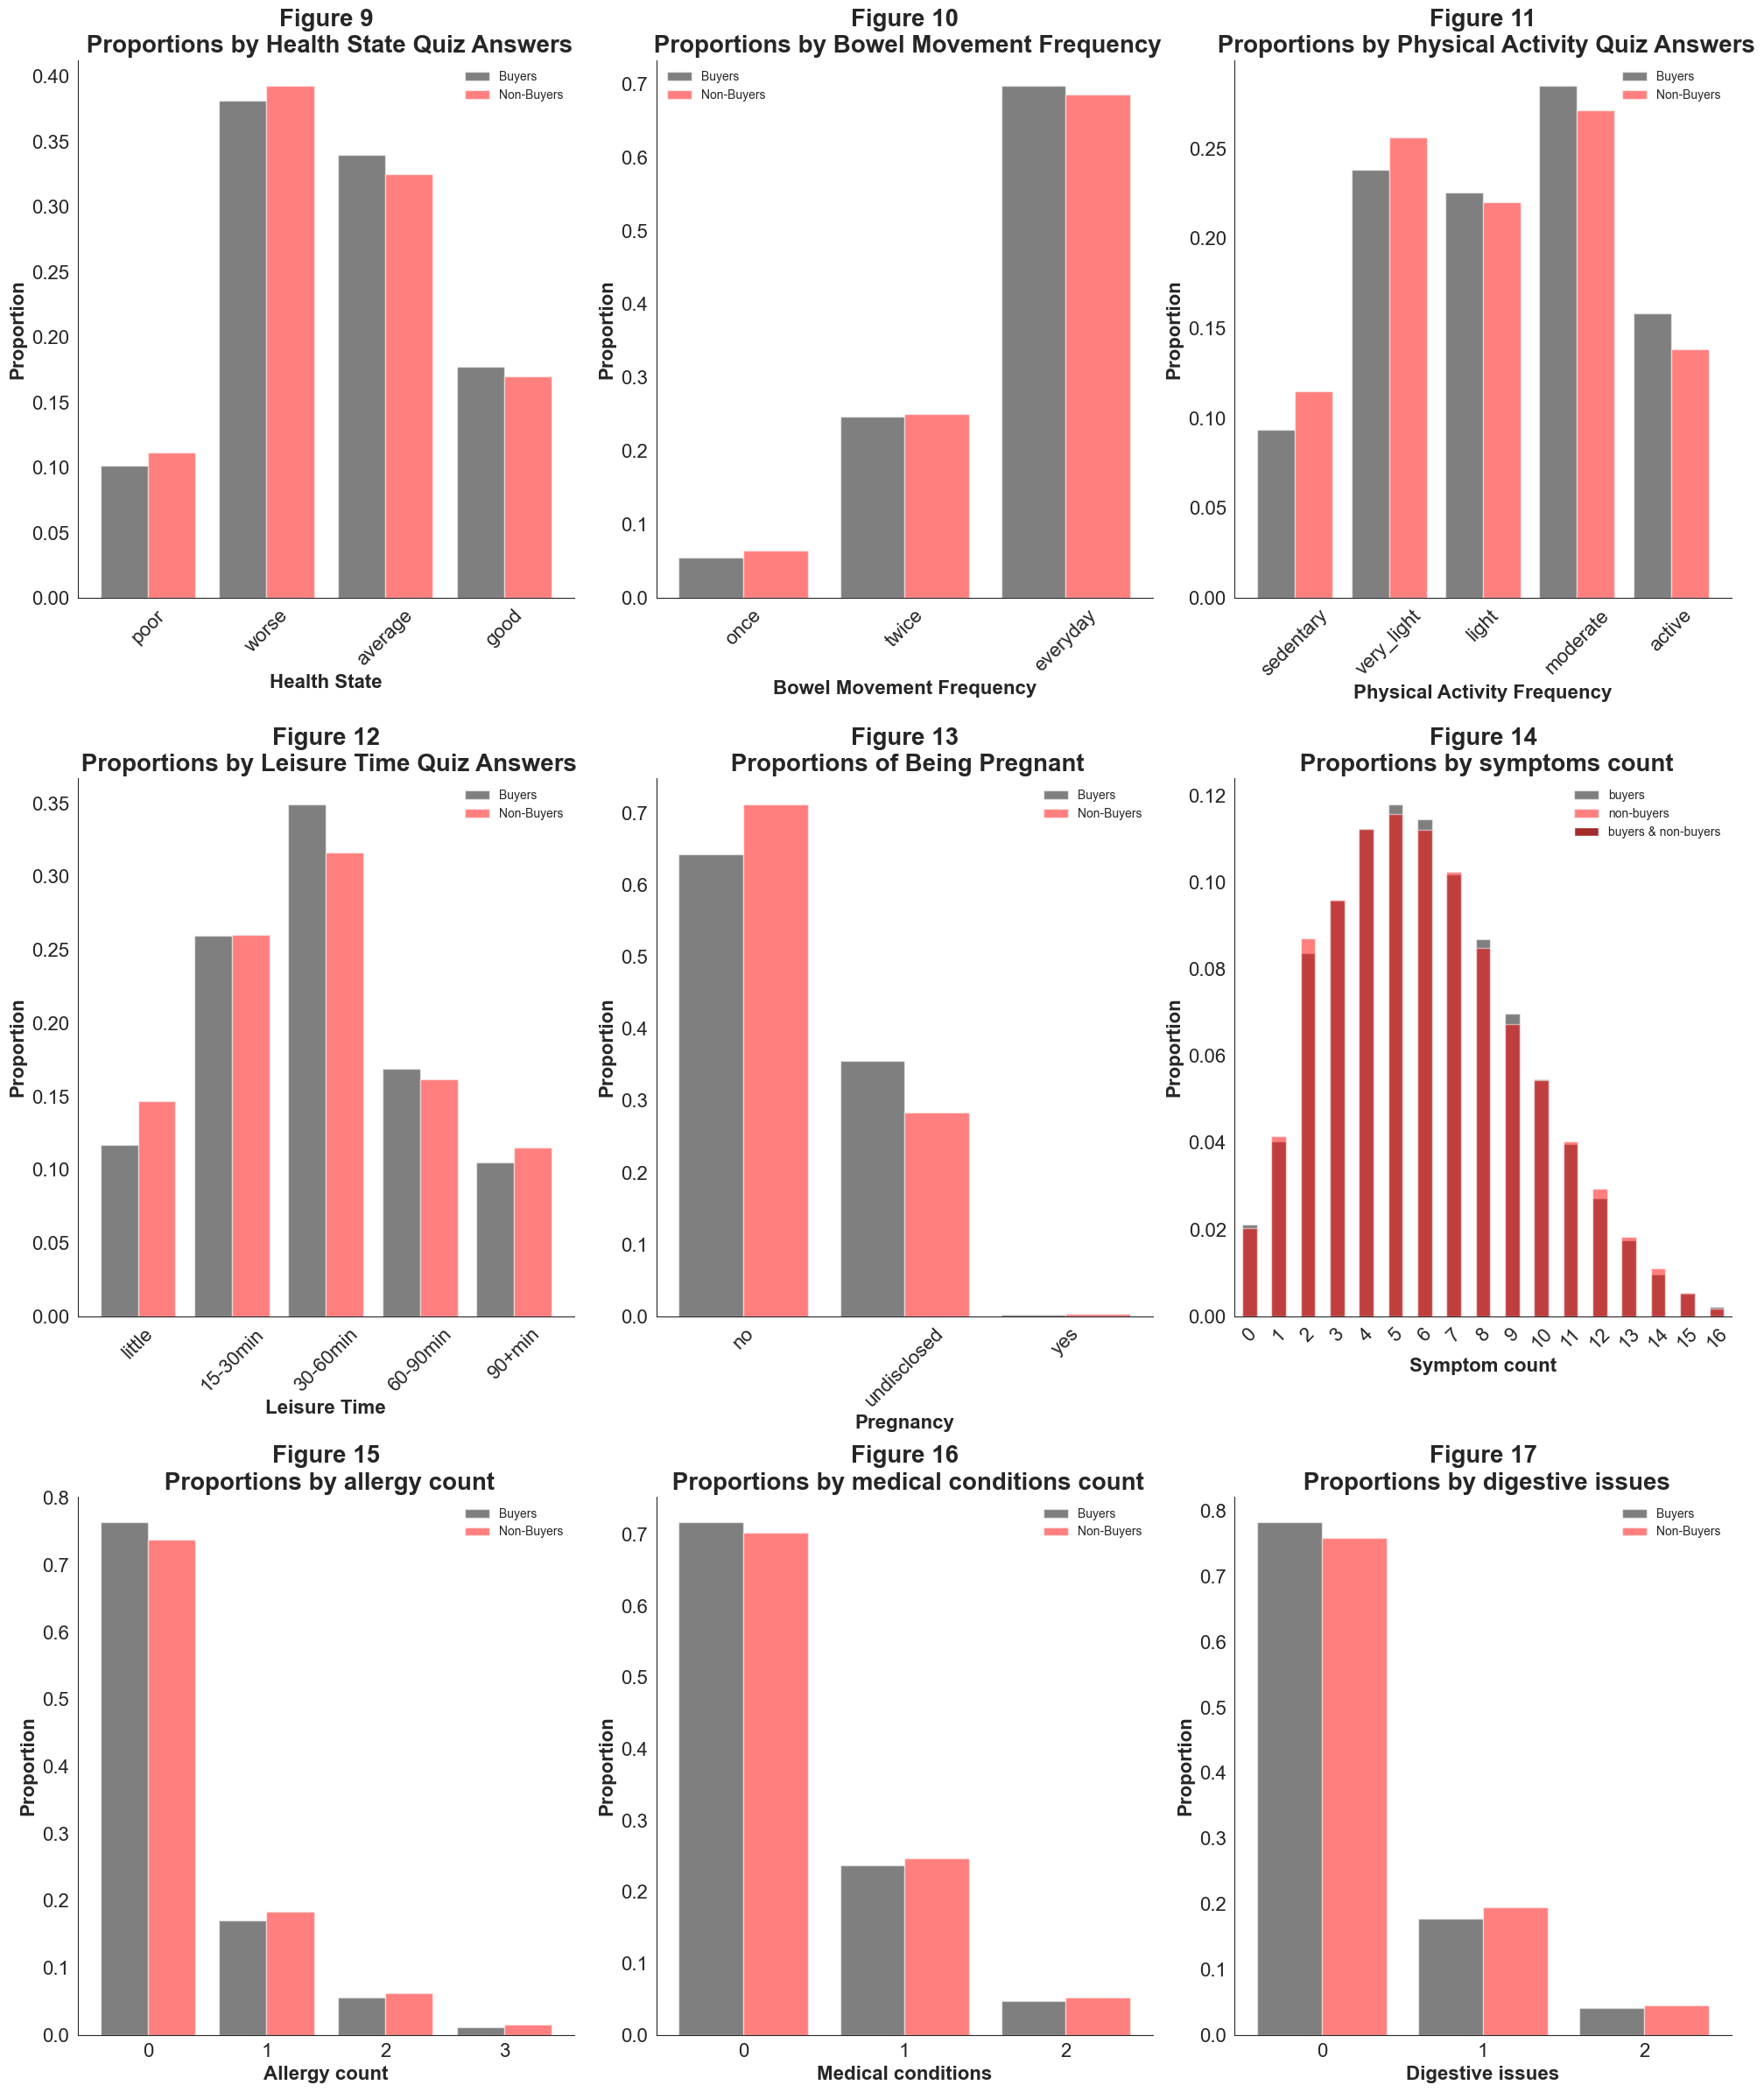

In [47]:
sns.set_style("white")
fig, axs = plt.subplots(3, 3, figsize=(20,24))

selected_answers = ['poor', 'worse', 'average', 'good']
buyers_filtered = buyers[buyers['quiz_health_state'].isin(selected_answers)]
non_buyers_filtered = non_buyers[non_buyers['quiz_health_state'].isin(selected_answers)]
buyers_health = buyers_filtered['quiz_health_state'].value_counts(normalize=True).reindex(selected_answers, fill_value=0)
non_buyers_health = non_buyers_filtered['quiz_health_state'].value_counts(normalize=True).reindex(selected_answers, fill_value=0)
x_positions = range(len(selected_answers))
axs[0,0].bar(x_positions, buyers_health, width=0.4, color='black', alpha=0.5, label='Buyers')
axs[0,0].bar([x + 0.4 for x in x_positions], non_buyers_health, width=0.4, color='red', alpha=0.5, label='Non-Buyers')
axs[0,0].set_xticks([x + 0.2 for x in x_positions])
axs[0,0].set_xticklabels(selected_answers, rotation=45, ha='center')
axs[0,0].set_title('Figure 9\n Proportions by Health State Quiz Answers', fontweight = 'bold', fontsize=20)
axs[0,0].set_xlabel('Health State', fontweight = 'bold', fontsize=16)
axs[0,0].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[0,0].legend()
legend.get_frame().set_linewidth(0)


selected_answers_poop = ['once', 'twice', 'everyday']
buyers_poop_filtered = buyers[buyers['quiz_poop'].isin(selected_answers_poop)]
non_buyers_poop_filtered = non_buyers[non_buyers['quiz_poop'].isin(selected_answers_poop)]
buyers_poop_proportions = buyers_poop_filtered['quiz_poop'].value_counts(normalize=True).reindex(selected_answers_poop, fill_value=0)
non_buyers_poop_proportions = non_buyers_poop_filtered['quiz_poop'].value_counts(normalize=True).reindex(selected_answers_poop, fill_value=0)
x_positions_poop = range(len(selected_answers_poop))
axs[0, 1].bar(x_positions_poop, buyers_poop_proportions, width=0.4, color='black', alpha=0.5, label='Buyers')
axs[0, 1].bar([x + 0.4 for x in x_positions_poop], non_buyers_poop_proportions, width=0.4, color='red', alpha=0.5, label='Non-Buyers')
axs[0, 1].set_xticks([x + 0.2 for x in x_positions_poop])
axs[0, 1].set_xticklabels(selected_answers_poop, rotation=45, ha='center')
axs[0, 1].set_title('Figure 10\n Proportions by Bowel Movement Frequency', fontweight = 'bold', fontsize=20)
axs[0, 1].set_xlabel('Bowel Movement Frequency', fontweight = 'bold', fontsize=16)
axs[0, 1].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[0,1].legend()
legend.get_frame().set_linewidth(0)


selected_values_active = ['sedentary', 'very_light', 'light', 'moderate', 'active']
buyers_active_filtered = buyers[buyers['quiz_physically_active'].isin(selected_values_active)]
non_buyers_active_filtered = non_buyers[non_buyers['quiz_physically_active'].isin(selected_values_active)]
buyers_active_proportions = buyers_active_filtered['quiz_physically_active'].value_counts(normalize=True).reindex(selected_values_active, fill_value=0)
non_buyers_active_proportions = non_buyers_active_filtered['quiz_physically_active'].value_counts(normalize=True).reindex(selected_values_active, fill_value=0)
x_positions_active = range(len(selected_values_active))
axs[0, 2].bar(x_positions_active, buyers_active_proportions, width=0.4, color='black', alpha=0.5, label='Buyers')
axs[0, 2].bar([x + 0.4 for x in x_positions_active], non_buyers_active_proportions, width=0.4, color='red', alpha=0.5, label='Non-Buyers')
axs[0, 2].set_xticks([x + 0.2 for x in x_positions_active])
axs[0, 2].set_xticklabels(selected_values_active, rotation=45, ha='center')
axs[0, 2].set_title('Figure 11\n Proportions by Physical Activity Quiz Answers', fontweight = 'bold', fontsize=20)
axs[0, 2].set_xlabel('Physical Activity Frequency', fontweight = 'bold', fontsize=16)
axs[0, 2].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[0,2].legend()
legend.get_frame().set_linewidth(0)

selected_leisure_answers = ['little', '15-30min', '30-60min', '60-90min', '90+min']
buyers_leisure_filtered = buyers[buyers['quiz_leisure'].isin(selected_leisure_answers)]
non_buyers_leisure_filtered = non_buyers[non_buyers['quiz_leisure'].isin(selected_leisure_answers)]
buyers_leisure_proportions = buyers_leisure_filtered['quiz_leisure'].value_counts(normalize=True).reindex(selected_leisure_answers, fill_value=0)
non_buyers_leisure_proportions = non_buyers_leisure_filtered['quiz_leisure'].value_counts(normalize=True).reindex(selected_leisure_answers, fill_value=0)
x_positions_leisure = range(len(selected_leisure_answers))
axs[1, 0].bar(x_positions_leisure, buyers_leisure_proportions, width = 0.4, color='black', alpha=0.5, label='Buyers')
axs[1, 0].bar([x + 0.4 for x in x_positions_leisure], non_buyers_leisure_proportions, width = 0.4, color='red', alpha=0.5, label='Non-Buyers')
axs[1, 0].set_xticks([x + 0.2 for x in x_positions_leisure])
axs[1, 0].set_xticklabels(selected_leisure_answers, rotation=45, ha='center')
axs[1, 0].set_title('Figure 12\n Proportions by Leisure Time Quiz Answers', fontweight = 'bold', fontsize=20)
axs[1, 0].set_xlabel('Leisure Time', fontweight = 'bold', fontsize=16)
axs[1, 0].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[1,0].legend()
legend.get_frame().set_linewidth(0)

buyers_pregnant = buyers['quiz_pregnant'].value_counts(normalize= True)
non_buyers_pregnant = non_buyers['quiz_pregnant'].value_counts(normalize= True)
x_positions_pregnant = range(len(buyers_pregnant))
axs[1, 1].bar(x_positions_pregnant, buyers_pregnant, width = 0.4, color='black', alpha=0.5, label='Buyers')
axs[1, 1].bar([x + 0.4 for x in x_positions_pregnant], non_buyers_pregnant, width = 0.4, color='red', alpha=0.5, label='Non-Buyers')
axs[1, 1].set_xticks([x + 0.2 for x in x_positions_pregnant])
axs[1, 1].set_xticklabels(non_buyers_pregnant.index, rotation=45, ha='center')
axs[1, 1].set_title('Figure 13\n Proportions of Being Pregnant', fontweight = 'bold', fontsize=20)
axs[1, 1].set_xlabel('Pregnancy', fontweight = 'bold', fontsize=16)
axs[1, 1].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[1,1].legend()
legend.get_frame().set_linewidth(0)

def calculate_symptom_sum(row):
    symptoms = row['quiz_symptoms'].split(',') + row['quiz_symptoms_two'].split(',')
    symptom_count = sum(1 for symptom in symptoms if symptom not in ['none', ''])
    return symptom_count

buyers['symptom_count'] = buyers.apply(calculate_symptom_sum, axis=1)
non_buyers['symptom_count'] = non_buyers.apply(calculate_symptom_sum, axis=1)

buyers_symptoms = buyers['symptom_count'].value_counts(normalize= True).sort_index()
buyers_symptoms.plot(kind='bar', ax=axs[1,2], color='black', alpha = 0.5, label = 'buyers')
non_buyers_symptoms = non_buyers['symptom_count'].value_counts(normalize= True).sort_index()
non_buyers_symptoms.plot(kind='bar', ax=axs[1,2], color='red', alpha = 0.5, label = 'non-buyers')
handles, labels = axs[1,2].get_legend_handles_labels()
handles.append(plt.Rectangle((0, 0), 1, 1, fc="brown"))
labels.append('buyers & non-buyers')
axs[1,2].set_title('Figure 14\n Proportions by symptoms count', fontweight = 'bold', fontsize=20)
axs[1,2].set_xlabel('Symptom count', fontweight = 'bold', fontsize=16)
axs[1,2].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[1,2].set_xticklabels(buyers_symptoms.index, rotation=45)
legend = axs[1,2].legend(handles, labels)
legend.get_frame().set_linewidth(0)


def calculate_allergy_count(row):
    allergies = row['quiz_allergies'].split(',')
    allergy_count = sum(1 for allergy in allergies if allergy not in ['none', '']) 
    return allergy_count

buyers['allergy_count'] = buyers.apply(calculate_allergy_count, axis=1)
non_buyers['allergy_count'] = non_buyers.apply(calculate_allergy_count, axis=1)
selected_allergy_counts = [0, 1, 2, 3]
buyers_allergy_filtered = buyers[buyers['allergy_count'].isin(selected_allergy_counts)]
non_buyers_allergy_filtered = non_buyers[non_buyers['allergy_count'].isin(selected_allergy_counts)]
buyers_allergy_proportions = buyers_allergy_filtered['allergy_count'].value_counts(normalize=True).reindex(selected_allergy_counts, fill_value=0)
non_buyers_allergy_proportions = non_buyers_allergy_filtered['allergy_count'].value_counts(normalize=True).reindex(selected_allergy_counts, fill_value=0)
x_positions_allergy = range(len(selected_allergy_counts))
axs[2, 0].bar(x_positions_allergy, buyers_allergy_proportions, width=0.4, color='black', alpha=0.5, label='Buyers')
axs[2, 0].bar([x + 0.4 for x in x_positions_allergy], non_buyers_allergy_proportions, width=0.4, color='red', alpha=0.5, label='Non-Buyers')
axs[2, 0].set_xticks([x + 0.2 for x in x_positions_allergy])
axs[2, 0].set_xticklabels(selected_allergy_counts)
axs[2, 0].set_title('Figure 15\n Proportions by allergy count', fontweight = 'bold', fontsize=20)
axs[2, 0].set_xlabel('Allergy count', fontweight = 'bold', fontsize=16)
axs[2, 0].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[2,0].legend()
legend.get_frame().set_linewidth(0)



def calculate_medical_sum(row):
    medical = row['quiz_medical_conditions'].split(',')
    medical_count = sum(1 for condition in medical if condition not in ['none', ''])
    return medical_count

buyers['medical_count'] = buyers.apply(calculate_medical_sum, axis=1)
non_buyers['medical_count'] = non_buyers.apply(calculate_medical_sum, axis=1)

selected_medical_counts = [0, 1, 2]
buyers_medical_filtered = buyers[buyers['medical_count'].isin(selected_medical_counts)]
non_buyers_medical_filtered = non_buyers[non_buyers['medical_count'].isin(selected_medical_counts)]
buyers_medical_proportions = buyers_medical_filtered['medical_count'].value_counts(normalize=True).reindex(selected_medical_counts, fill_value=0)
non_buyers_medical_proportions = non_buyers_medical_filtered['medical_count'].value_counts(normalize=True).reindex(selected_medical_counts, fill_value=0)
x_positions_medical = range(len(selected_medical_counts))
axs[2, 1].bar(x_positions_medical, buyers_medical_proportions, width=0.4, color='black', alpha=0.5, label='Buyers')
axs[2, 1].bar([x + 0.4 for x in x_positions_medical], non_buyers_medical_proportions, width=0.4, color='red', alpha=0.5, label='Non-Buyers')
axs[2, 1].set_xticks([x + 0.2 for x in x_positions_medical])
axs[2, 1].set_xticklabels(selected_medical_counts)
axs[2, 1].set_title('Figure 16\n Proportions by medical conditions count', fontweight = 'bold', fontsize=20)
axs[2, 1].set_xlabel('Medical conditions', fontweight = 'bold', fontsize=16)
axs[2, 1].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[2,1].legend()
legend.get_frame().set_linewidth(0)

def calculate_digestive_count(row):
    digestive = row['quiz_digestive'].split(',')
    digestive_count = sum(1 for issue in digestive if issue not in ['none', '']) 
    return digestive_count

buyers['digestive_count'] = buyers.apply(calculate_digestive_count, axis=1)
non_buyers['digestive_count'] = non_buyers.apply(calculate_digestive_count, axis=1)

selected_digestive_counts = [0, 1, 2]
buyers_digestive_filtered = buyers[buyers['digestive_count'].isin(selected_digestive_counts)]
non_buyers_digestive_filtered = non_buyers[non_buyers['digestive_count'].isin(selected_digestive_counts)]
buyers_digestive_proportions = buyers_digestive_filtered['digestive_count'].value_counts(normalize=True).reindex(selected_digestive_counts, fill_value=0)
non_buyers_digestive_proportions = non_buyers_digestive_filtered['digestive_count'].value_counts(normalize=True).reindex(selected_digestive_counts, fill_value=0)
x_positions_digestive = range(len(selected_digestive_counts))
axs[2, 2].bar(x_positions_digestive, buyers_digestive_proportions, width=0.4, color='black', alpha=0.5, label='Buyers')
axs[2, 2].bar([x + 0.4 for x in x_positions_digestive], non_buyers_digestive_proportions, width=0.4, color='red', alpha=0.5, label='Non-Buyers')
axs[2, 2].set_xticks([x + 0.2 for x in x_positions_digestive])
axs[2, 2].set_xticklabels(selected_digestive_counts)
axs[2, 2].set_title('Figure 17\n Proportions by digestive issues', fontweight = 'bold', fontsize=20)
axs[2, 2].set_xlabel('Digestive issues', fontweight = 'bold', fontsize=16)
axs[2, 2].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[2,2].legend()
legend.get_frame().set_linewidth(0)


for row in axs:
    for ax in row:
        ax.tick_params(axis='both', which='major', labelsize=16, width=3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()

### All 9 figures are the bar plots that show differences between buyers’ and non-buyers’ proportions in different quiz answers.  

### Starting from Figure 9, we can see that counterintuitively non-buyers are more likely to feel worse than average and poor than buyers. However, people who are feeling worse than average, also take most buyers. Buyers have more people in proportion who feel average or good. However, data between health state quiz answers between two groups are distributed similarly, as the differences in proportions are small. 

### Moving to the Figure 10, graph shows that buyers have slightly more people (in proportion) with higher bowel movement.  

### Figure 11 shows the physical activity of buyers and non-buyers. The relationship between physical activity and becoming a buyer can be clearly seen. People who have low physical activity, are non-buyers more often. Buyers are significantly more active. The difference between groups is also large on the minimal physical activity and maximum physical activity and small in the option of the middle choice. So, it can be concluded that people who have average physical activity do not differ so much in their choice of becoming a client, but the more active the person is the more likely he is to buy. 

### Figure 12 shows how much time of leisure is spent doing something active between buyers and non-buyers. And as shown in the graph, buyers spend more time doing something active than non-buyers (with a small proportion outlier of 90+ min). The least option of leisure time has significantly more non-buyers while 30-60 minutes workout have much more people who buy (in proportion). 

### Figure 13 indicates a relationship between pregnancy and being in a group of buyers or non-buyers. Bigger proportion of non-buyers are not pregnant. If we would have complete data of survey, we could conclude that buyers are more likely to be pregnant as they have a smaller proportion of non-pregnant respondents. But we have very little data of people that are pregnant, as almost all who did not select 'not pregnant' did not want to answer the question. So, it is very difficult to determine the relationship between pregnancy and buying as we do not have complete answers. On the other hand, it could be that not pregnant are less likely to buy. 

### Figure 14 shows the relationship between number of symptoms and buying a product. Distribution of data among two groups are very similar. However, people with moderate number of symptoms are slightly more likely to be buyers. 

### Figures 15,16, and 17 show the relationships between becoming a buyer and having allergies, medical conditions or digestive issues. In all three graphs distribution of data between buyers and non-buyers are nearly identical, but there are slightly more buyers in proportion to non-buyers who do not have any medical issues. There is more non-buyers if the number of medical issues rise, but the difference is significantly small. So, it could be concluded that there is a small relationship between buying and not having any medical issues, but it is important to keep in mind the small size of the effect.

# How do these characteristics vary between OTP and subscription-based customers and are there differences among those that choose 1, 3 or 6 bottles?

In [48]:
subscription = df[df['is_subscription'] == 'Yes']
one_time = df[df['is_subscription'] == 'No']
subscription['subscribers'] = 'Subscribers'
one_time['subscribers'] = 'One time purchasers'
combined_sub = pd.concat([subscription, one_time], ignore_index=True)

# Analysis of Subscribers and One-Time Purchasers

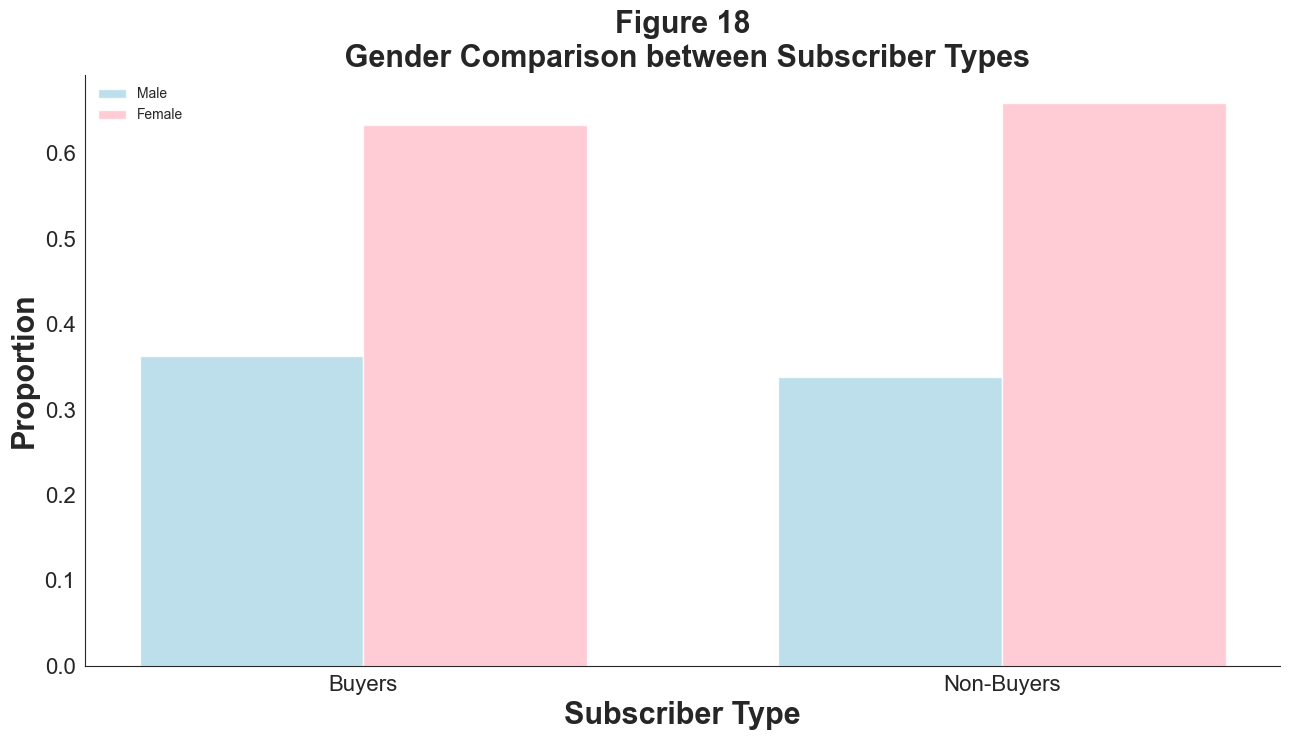

In [49]:
gender_counts = combined_sub.groupby('subscribers')['gender'].value_counts(normalize=True).rename('Proportion').reset_index()
pivot_data = gender_counts.pivot(index='subscribers', columns='gender', values='Proportion')

sns.set_style("white")
fig, axs = plt.subplots(1, 1, figsize=(13, 7.5))

bar_width = 0.35
index = np.arange(len(groups))

rects1 = axs.bar(index, pivot_data['male'], bar_width,
                alpha=0.8,
                color='lightblue',
                label='Male')

rects2 = axs.bar(index + bar_width, pivot_data['female'], bar_width,
                alpha=0.8,
                color='pink',
                label='Female')

axs.set_xlabel('Subscriber Type', fontweight='bold', fontsize=22)
axs.set_ylabel('Proportion', fontweight='bold', fontsize=22)
axs.set_title('Figure 18\n Gender Comparison between Subscriber Types', fontweight='bold', fontsize=22)
axs.set_xticks(index + bar_width / 2)
axs.set_xticklabels(groups)
legend = axs.legend()
legend.get_frame().set_linewidth(0)
axs.tick_params(axis='both', which='major', labelsize=16, width=3)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

plt.tight_layout()

### Figure 18 indicates how females and males are divided between subscribers and one-time purchasers. Both one-time purchasers and subscribers have more females than males. Gender proportions between two groups do not differ significantly. So, as there are more females in our dataset, we have more females in both OTP and subscriptions. By looking at the gender we cannot distinguish who is more likely to become a one-time purchaser or a subscriber. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


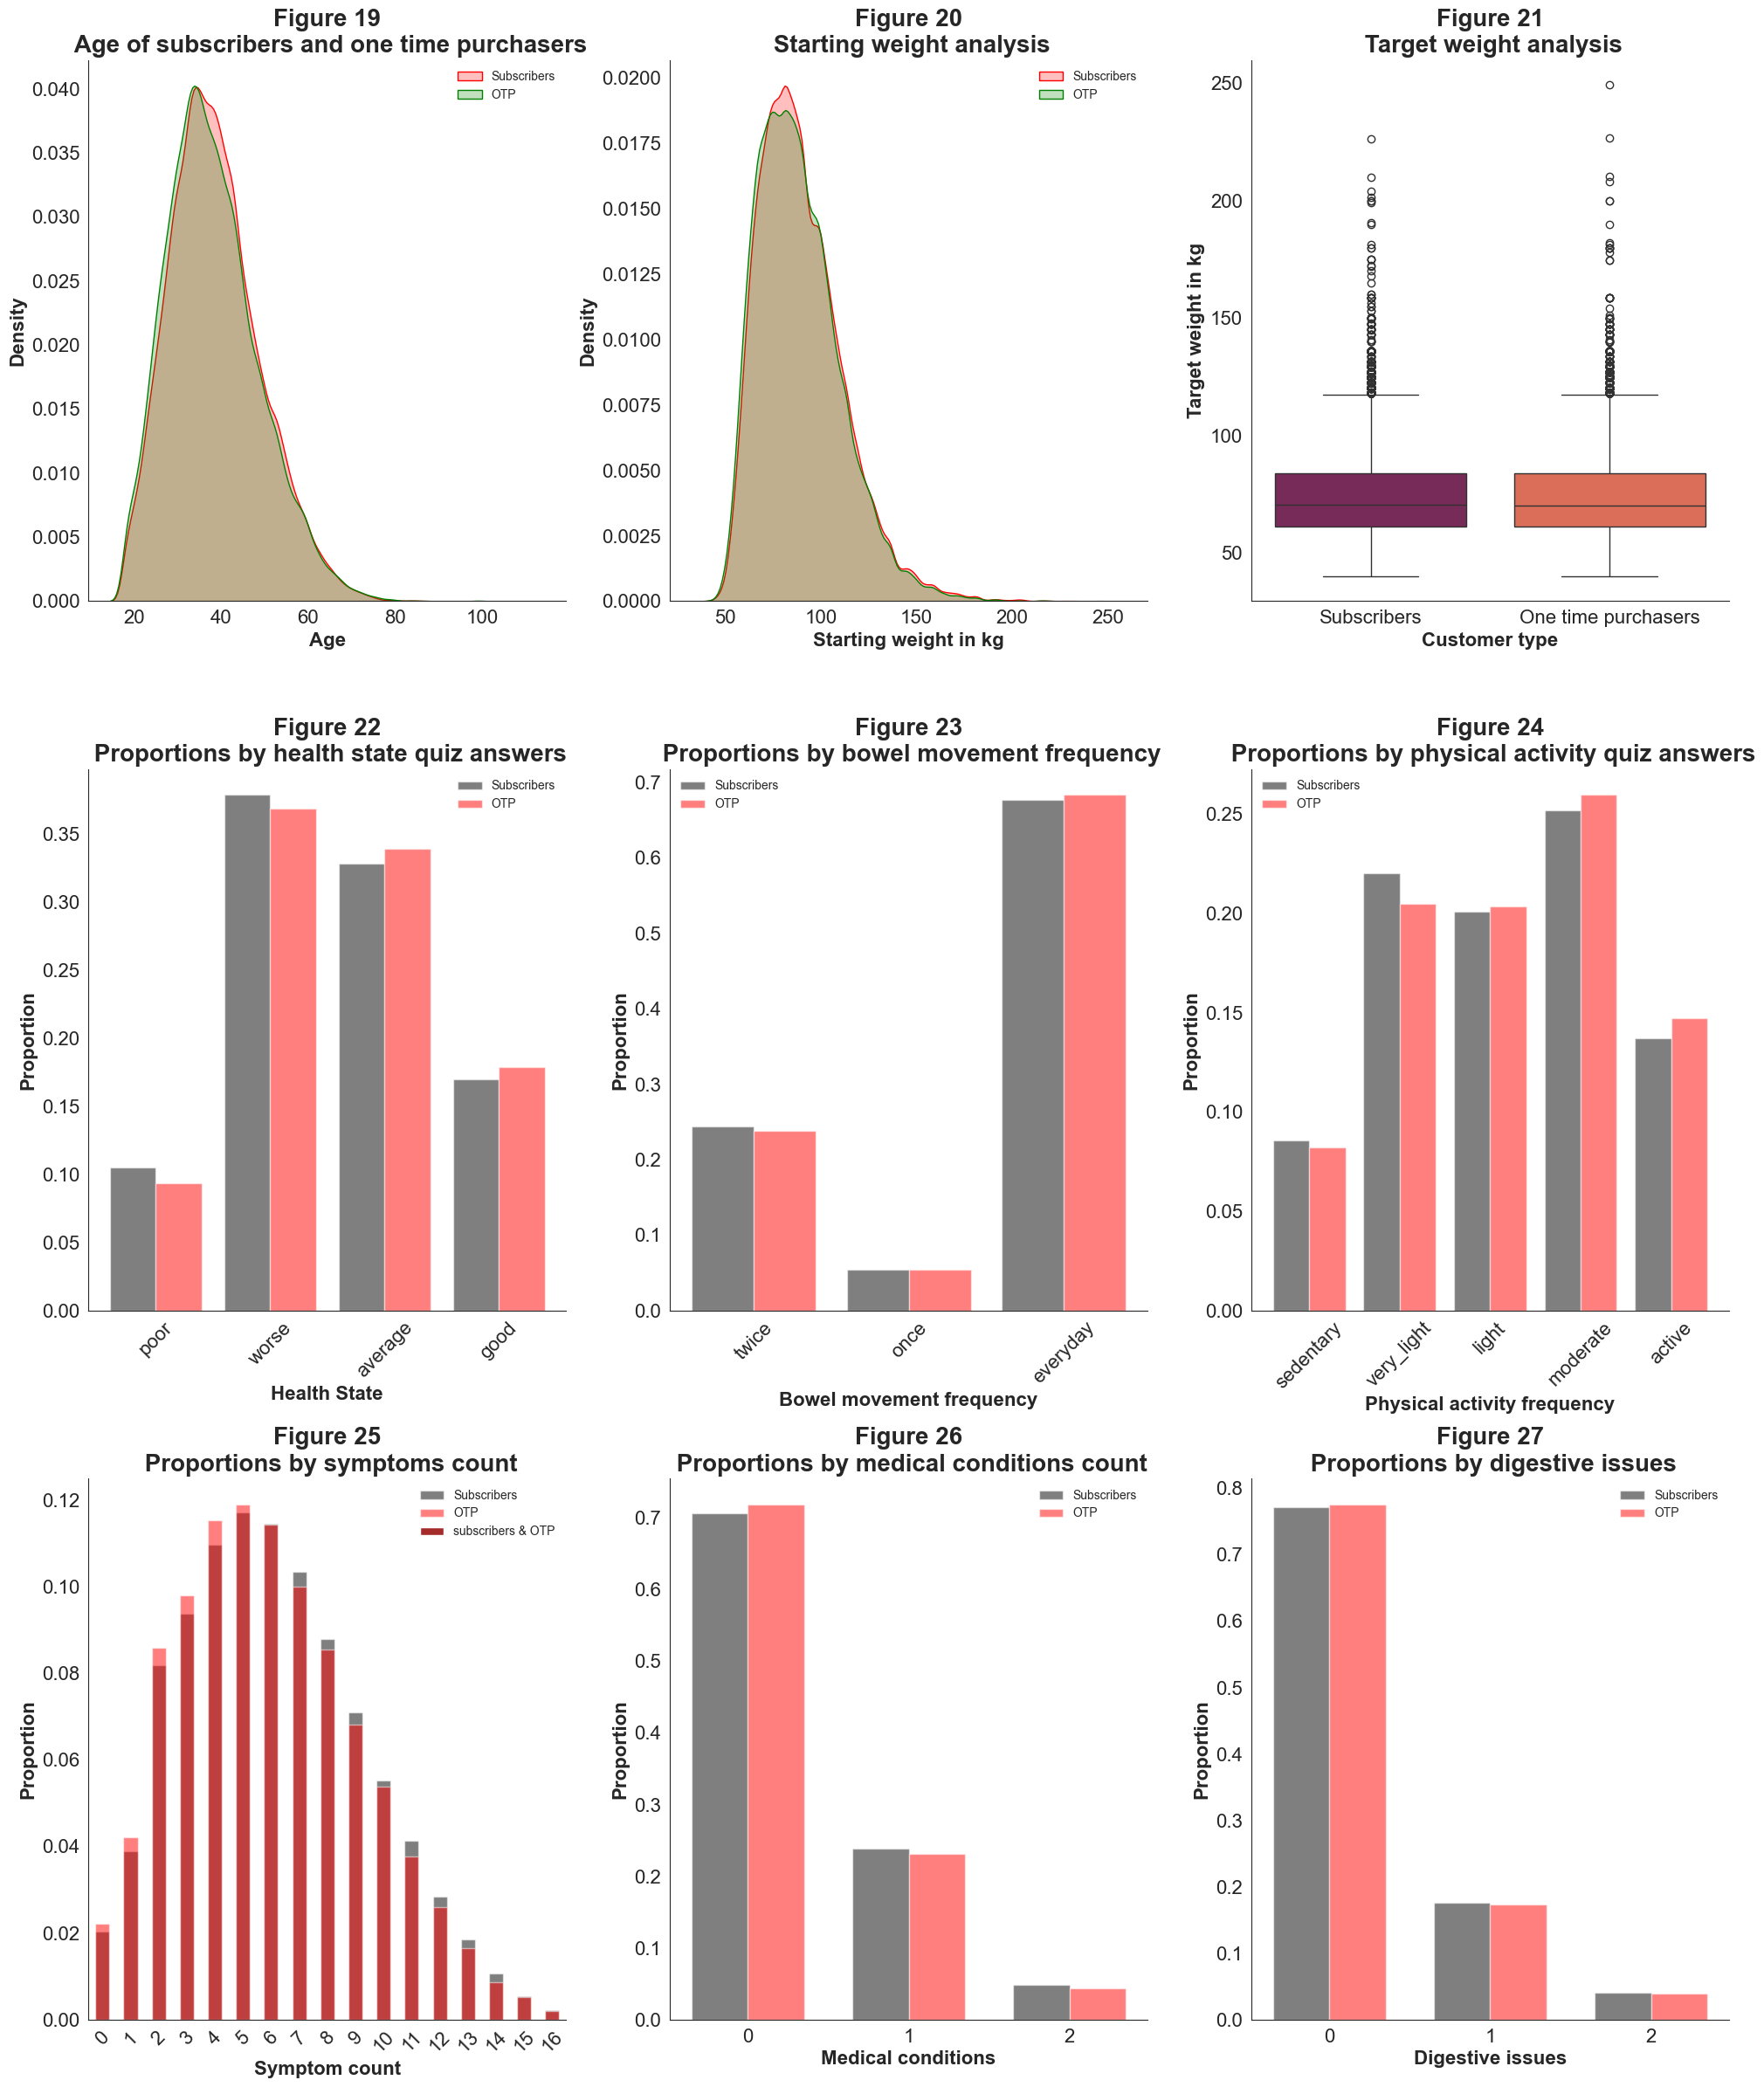

In [51]:
sns.set_style("white")

fig, axs = plt.subplots(3, 3, figsize=(20, 24))

sns.kdeplot(x= subscription['age'], fill = True, color = 'red', ax=axs[0,0], label = 'Subscribers')
sns.kdeplot(x= one_time['age'], fill = True, color = 'green', ax=axs[0,0], label = 'OTP')
axs[0,0].set_title('Figure 19\n Age of subscribers and one time purchasers', fontweight = 'bold', fontsize=20)
axs[0,0].set_xlabel('Age', fontweight = 'bold', fontsize=16)
axs[0,0].set_ylabel('Density', fontweight = 'bold', fontsize=16)
legend = axs[0,0].legend()
legend.get_frame().set_linewidth(0)

sns.kdeplot(x=subscription['starting_weight_in_kg'], fill = True, color = 'red', ax = axs[0,1], label = 'Subscribers')
sns.kdeplot(x=one_time['starting_weight_in_kg'], fill = True, color = 'green', ax = axs[0,1], label = 'OTP')
axs[0,1].set_title('Figure 20\n Starting weight analysis', fontweight = 'bold', fontsize=20)
axs[0,1].set_xlabel('Starting weight in kg', fontweight = 'bold', fontsize=16)
axs[0,1].set_ylabel('Density', fontweight = 'bold', fontsize=16)
legend = axs[0,1].legend()
legend.get_frame().set_linewidth(0)

sns.boxplot(x='subscribers', y='target_weight_in_kg', data=combined_sub, palette= 'rocket', ax=axs[0,2])
axs[0,2].set_title('Figure 21\n Target weight analysis', fontweight = 'bold', fontsize=20)
axs[0,2].set_xlabel('Customer type', fontweight = 'bold', fontsize=16)
axs[0,2].set_ylabel('Target weight in kg', fontweight = 'bold', fontsize=16)
legend = axs[0,2].legend()
legend.get_frame().set_linewidth(0)

categories_of_interest = [ "poor", "worse", "average", "good"]
health_sub = subscription['quiz_health_state'].value_counts(normalize=True)
health_otp = one_time['quiz_health_state'].value_counts(normalize=True)
health_sub_filtered = health_sub.reindex(categories_of_interest).fillna(0)
health_otp_filtered = health_otp.reindex(categories_of_interest).fillna(0)
x = range(len(categories_of_interest))
axs[1,0].bar(x, health_sub_filtered.values, width=0.4, color='black', alpha=0.5, label='Subscribers')
axs[1,0].bar([i + 0.4 for i in x], health_otp_filtered.values, width=0.4, color='red', alpha=0.5, label='OTP')
axs[1,0].set_xticks([i + 0.2 for i in x])
axs[1,0].set_xticklabels(categories_of_interest, rotation=45)
axs[1,0].set_title('Figure 22\n Proportions by health state quiz answers', fontweight='bold', fontsize=20)
axs[1,0].set_xlabel('Health State', fontweight = 'bold', fontsize=16)
axs[1,0].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[1,0].legend()
legend.get_frame().set_linewidth(0)

categories_of_interest_poop = [ "twice","once", "everyday"]
poop_sub = subscription['quiz_poop'].value_counts(normalize=True)
poop_otp = one_time['quiz_poop'].value_counts(normalize=True)
poop_sub_filtered = poop_sub.reindex(categories_of_interest_poop).fillna(0)
poop_otp_filtered = poop_otp.reindex(categories_of_interest_poop).fillna(0)
x_poop = range(len(categories_of_interest_poop))
axs[1,1].bar(x_poop, poop_sub_filtered.values, width=0.4, color='black', alpha=0.5, label='Subscribers')
axs[1,1].bar([i + 0.4 for i in x_poop], poop_otp_filtered.values, width=0.4, color='red', alpha=0.5, label='OTP')
axs[1,1].set_xticks([i + 0.2 for i in x_poop])
axs[1,1].set_xticklabels(categories_of_interest_poop, rotation=45)
axs[1,1].set_title('Figure 23\n Proportions by bowel movement frequency', fontweight='bold', fontsize=20)
axs[1,1].set_xlabel('Bowel movement frequency', fontweight = 'bold', fontsize=16)
axs[1,1].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[1,1].legend()
legend.get_frame().set_linewidth(0)

categories_of_interest_activity = ['sedentary', 'very_light', 'light', 'moderate', 'active']
active_sub = subscription['quiz_physically_active'].value_counts(normalize=True)
active_otp = one_time['quiz_physically_active'].value_counts(normalize=True)
active_sub_filtered = active_sub.reindex(categories_of_interest_activity).fillna(0)
active_otp_filtered = active_otp.reindex(categories_of_interest_activity).fillna(0)
x_activity = range(len(categories_of_interest_activity))
axs[1,2].bar(x_activity, active_sub_filtered.values, width=0.4, color='black', alpha=0.5, label='Subscribers')
axs[1,2].bar([i + 0.4 for i in x_activity], active_otp_filtered.values, width=0.4, color='red', alpha=0.5, label='OTP')
axs[1,2].set_xticks([i + 0.2 for i in x_activity])
axs[1,2].set_xticklabels(categories_of_interest_activity, rotation=45)
axs[1,2].set_title('Figure 24\n Proportions by physical activity quiz answers', fontweight='bold', fontsize=20)
axs[1,2].set_xlabel('Physical activity frequency', fontweight = 'bold', fontsize=16)
axs[1,2].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
legend = axs[1,2].legend()
legend.get_frame().set_linewidth(0)


subscription['symptom_count'] = subscription.apply(calculate_symptom_sum, axis=1)
one_time['symptom_count'] = one_time.apply(calculate_symptom_sum, axis=1)
symptoms_sub = subscription['symptom_count'].value_counts(normalize= True).sort_index()
symptoms_sub.plot(kind='bar', ax=axs[2,0], color='black', alpha = 0.5, label = 'Subscribers')
symptoms_otp = one_time['symptom_count'].value_counts(normalize= True).sort_index()
symptoms_otp.plot(kind='bar', ax=axs[2,0], color='red', alpha = 0.5, label = 'OTP')
handles, labels = axs[1,2].get_legend_handles_labels()
handles.append(plt.Rectangle((0, 0), 1, 1, fc="brown"))
labels.append('subscribers & OTP')
axs[2,0].set_title('Figure 25\n Proportions by symptoms count', fontweight = 'bold', fontsize=20)
axs[2,0].set_xlabel('Symptom count', fontweight = 'bold', fontsize=16)
axs[2,0].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[2,0].set_xticklabels(symptoms_sub.index, rotation=45)
legend = axs[2,0].legend(handles, labels)
legend.get_frame().set_linewidth(0)


subscription['medical_count'] = subscription.apply(calculate_medical_sum, axis=1)
one_time['medical_count'] = one_time.apply(calculate_medical_sum, axis=1)
medical_sub = subscription['medical_count'].value_counts(normalize= True).sort_index()
medical_otp = one_time['medical_count'].value_counts(normalize= True).sort_index()
filtered_index = [0, 1, 2]
medical_sub_filtered = medical_sub[medical_sub.index.isin(filtered_index)]
medical_otp_filtered = medical_otp[medical_otp.index.isin(filtered_index)]
bar_width = 0.35
x = range(len(filtered_index))
axs[2, 1].bar(x, medical_sub_filtered, width=bar_width, color='black', alpha=0.5, label='Subscribers')
axs[2, 1].bar([pos + bar_width for pos in x], medical_otp_filtered, width=bar_width, color='red', alpha=0.5, label='OTP')
axs[2, 1].set_title('Figure 26\n Proportions by medical conditions count', fontweight='bold', fontsize=20)
axs[2, 1].set_xlabel('Medical conditions', fontweight = 'bold', fontsize=16)
axs[2, 1].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[2, 1].set_xticks([pos + bar_width / 2 for pos in x])
axs[2, 1].set_xticklabels(filtered_index)
legend = axs[2,1].legend()
legend.get_frame().set_linewidth(0)


subscription['digestive_count'] = subscription.apply(calculate_digestive_count, axis=1)
one_time['digestive_count'] = one_time.apply(calculate_digestive_count, axis=1)
digestive_sub = subscription['digestive_count'].value_counts(normalize= True).sort_index()
digestive_otp = one_time['digestive_count'].value_counts(normalize= True).sort_index()
filtered_index = [0, 1, 2]
digestive_sub_filtered = digestive_sub[digestive_sub.index.isin(filtered_index)]
digestive_otp_filtered = digestive_otp[digestive_otp.index.isin(filtered_index)]
bar_width = 0.35
x = range(len(filtered_index))
axs[2, 2].bar(x, digestive_sub_filtered, width=bar_width, color='black', alpha=0.5, label='Subscribers')
axs[2, 2].bar([pos + bar_width for pos in x], digestive_otp_filtered, width=bar_width, color='red', alpha=0.5, label='OTP')
axs[2, 2].set_title('Figure 27\n Proportions by digestive issues', fontweight='bold', fontsize=20)
axs[2, 2].set_xlabel('Digestive issues', fontweight = 'bold', fontsize=16)
axs[2, 2].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[2, 2].set_xticks([pos + bar_width / 2 for pos in x])
axs[2, 2].set_xticklabels(filtered_index)
legend = axs[2,2].legend()
legend.get_frame().set_linewidth(0)


for row in axs:
    for ax in row:
        ax.tick_params(axis='both', which='major', labelsize=16, width=3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)


plt.tight_layout()


### Figure 19 shows that people who are older are more likely to be subscribers, while younger people tend to buy once (similarly as in Figure 1 with buyers and non-buyers). 
### Figure 20 indicates that weight distribution among subscribers and one-time purchasers are similar, but people who weight about 75-90 kilograms are more likely to become subscribers, as people of that weight is the majority of subscribers. 
### Figure 21 is the density plot for target weight of subscribers and one-time purchasers. Again, distribution is similar, but the most of subscribers have target weight of 70-80.  
### Figure 22 states that there are more subscribers than one-time purchasers who are feeling worse while there are more clients who buy once than subscribers who feel average or good. 
### Figure 23 indicates that subscribers and people who buy once do not differ in their bowel movement significantly. 
### Figure 24 shows that there are more people in proportion in OTP than in subscribers who say that their physical activity is moderate and active. Furthermore, there are more people in proportion of subscribers who state that their physical activity is very light. 
### Figure 25 shows a clear relationship between being a subscriber and having symptoms. As the count of symptoms increase, the likability of being a subscriber does to. 
### Figure 26 and Figure 27 is the proof that there is no significant differences between two groups of buyers when looking at the count of medical conditions and digestive issues, as they are distributed similarly. 

# Analysis of quantity of bottles

In [50]:
subscription_quantity = subscription[subscription['quantity'].isin([1, 3, 6])]
otp_quantity = one_time[one_time['quantity'].isin([1, 3, 6])]
subscription_1 = subscription[subscription['quantity'] == 1]
subscription_3 = subscription[subscription['quantity'] == 3]
subscription_6 = subscription[subscription['quantity'] == 6]
otp_1 = one_time[one_time['quantity'] == 1]
otp_3 = one_time[one_time['quantity'] == 3]
otp_6 = one_time[one_time['quantity'] == 6]

In [51]:
one_b = df[df['quantity'] == 1]
three_b = df[df['quantity'] == 3]
six_b = df[df['quantity'] == 6]
one_b['bottles'] = 'One'
three_b['bottles'] = 'Three'
six_b['bottles'] = 'Six' 
combined_b = pd.concat([one_b, three_b,six_b], ignore_index=True)

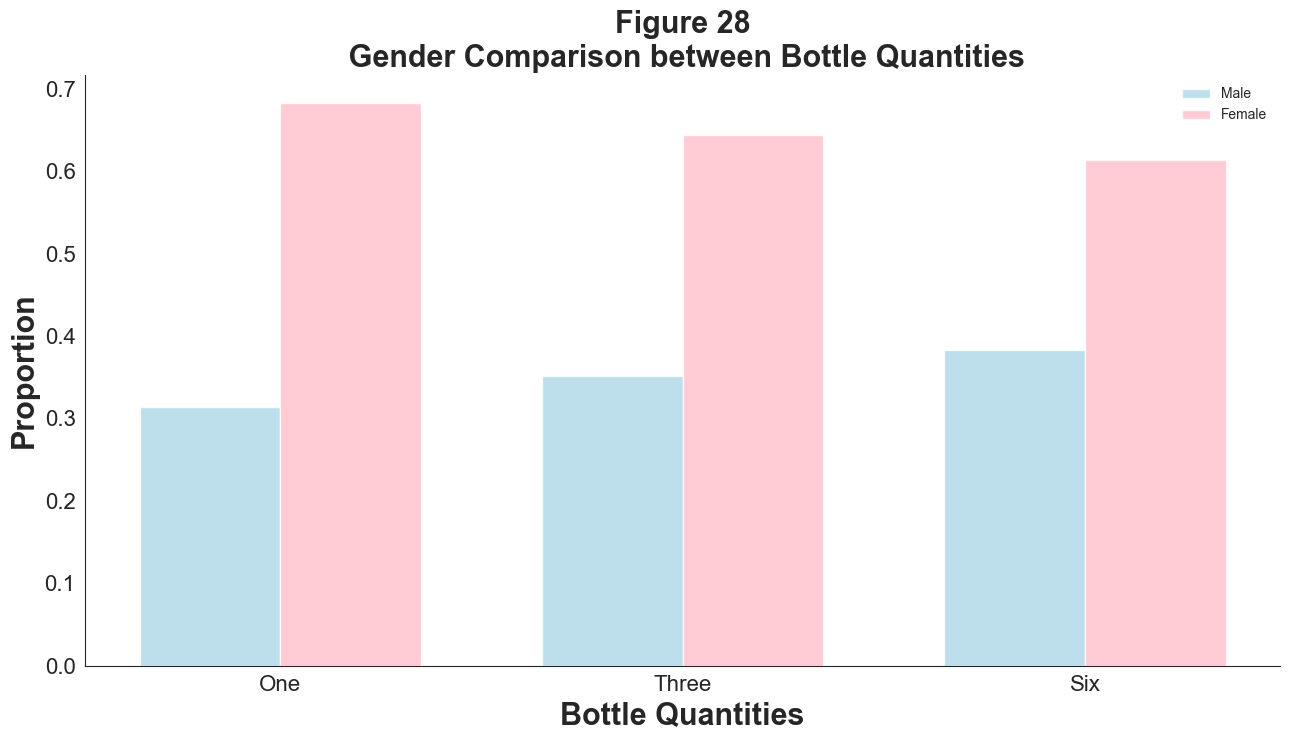

In [52]:
male_proportions = [one_b['gender'].value_counts(normalize=True)['male'],
                    three_b['gender'].value_counts(normalize=True)['male'],
                    six_b['gender'].value_counts(normalize=True)['male']]

female_proportions = [one_b['gender'].value_counts(normalize=True)['female'],
                      three_b['gender'].value_counts(normalize=True)['female'],
                      six_b['gender'].value_counts(normalize=True)['female']]

sns.set_style("white")
fig, axs = plt.subplots(1, 1, figsize=(13, 7.5))

bar_width = 0.35
index = np.arange(len(male_proportions))

rects1 = axs.bar(index, male_proportions, bar_width,
                alpha=0.8,
                color='lightblue',
                label='Male')        
rects2 = axs.bar(index + bar_width, female_proportions, bar_width,
                alpha=0.8,
                color='pink',
                label='Female')           

axs.set_xlabel('Bottle Quantities', fontweight='bold', fontsize=22)
axs.set_ylabel('Proportion', fontweight='bold', fontsize=22)
axs.set_title('Figure 28\n Gender Comparison between Bottle Quantities', fontweight='bold', fontsize=22)
axs.set_xticks(index + bar_width / 2)
axs.set_xticklabels(['One', 'Three', 'Six'])
legend = axs.legend()
legend.get_frame().set_linewidth(0)

axs.tick_params(axis='both', which='major', labelsize=16, width=3)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

plt.tight_layout()

### Once again, Figure 28 shows that there are more female buyers in each bottle quantity. There is a small effect of increasing number of males when bottle quantity increases (decreasing effect of females as well). But, by looking at the persons gender we cannot distinguish how many bottles will he buy, because differences are very small. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


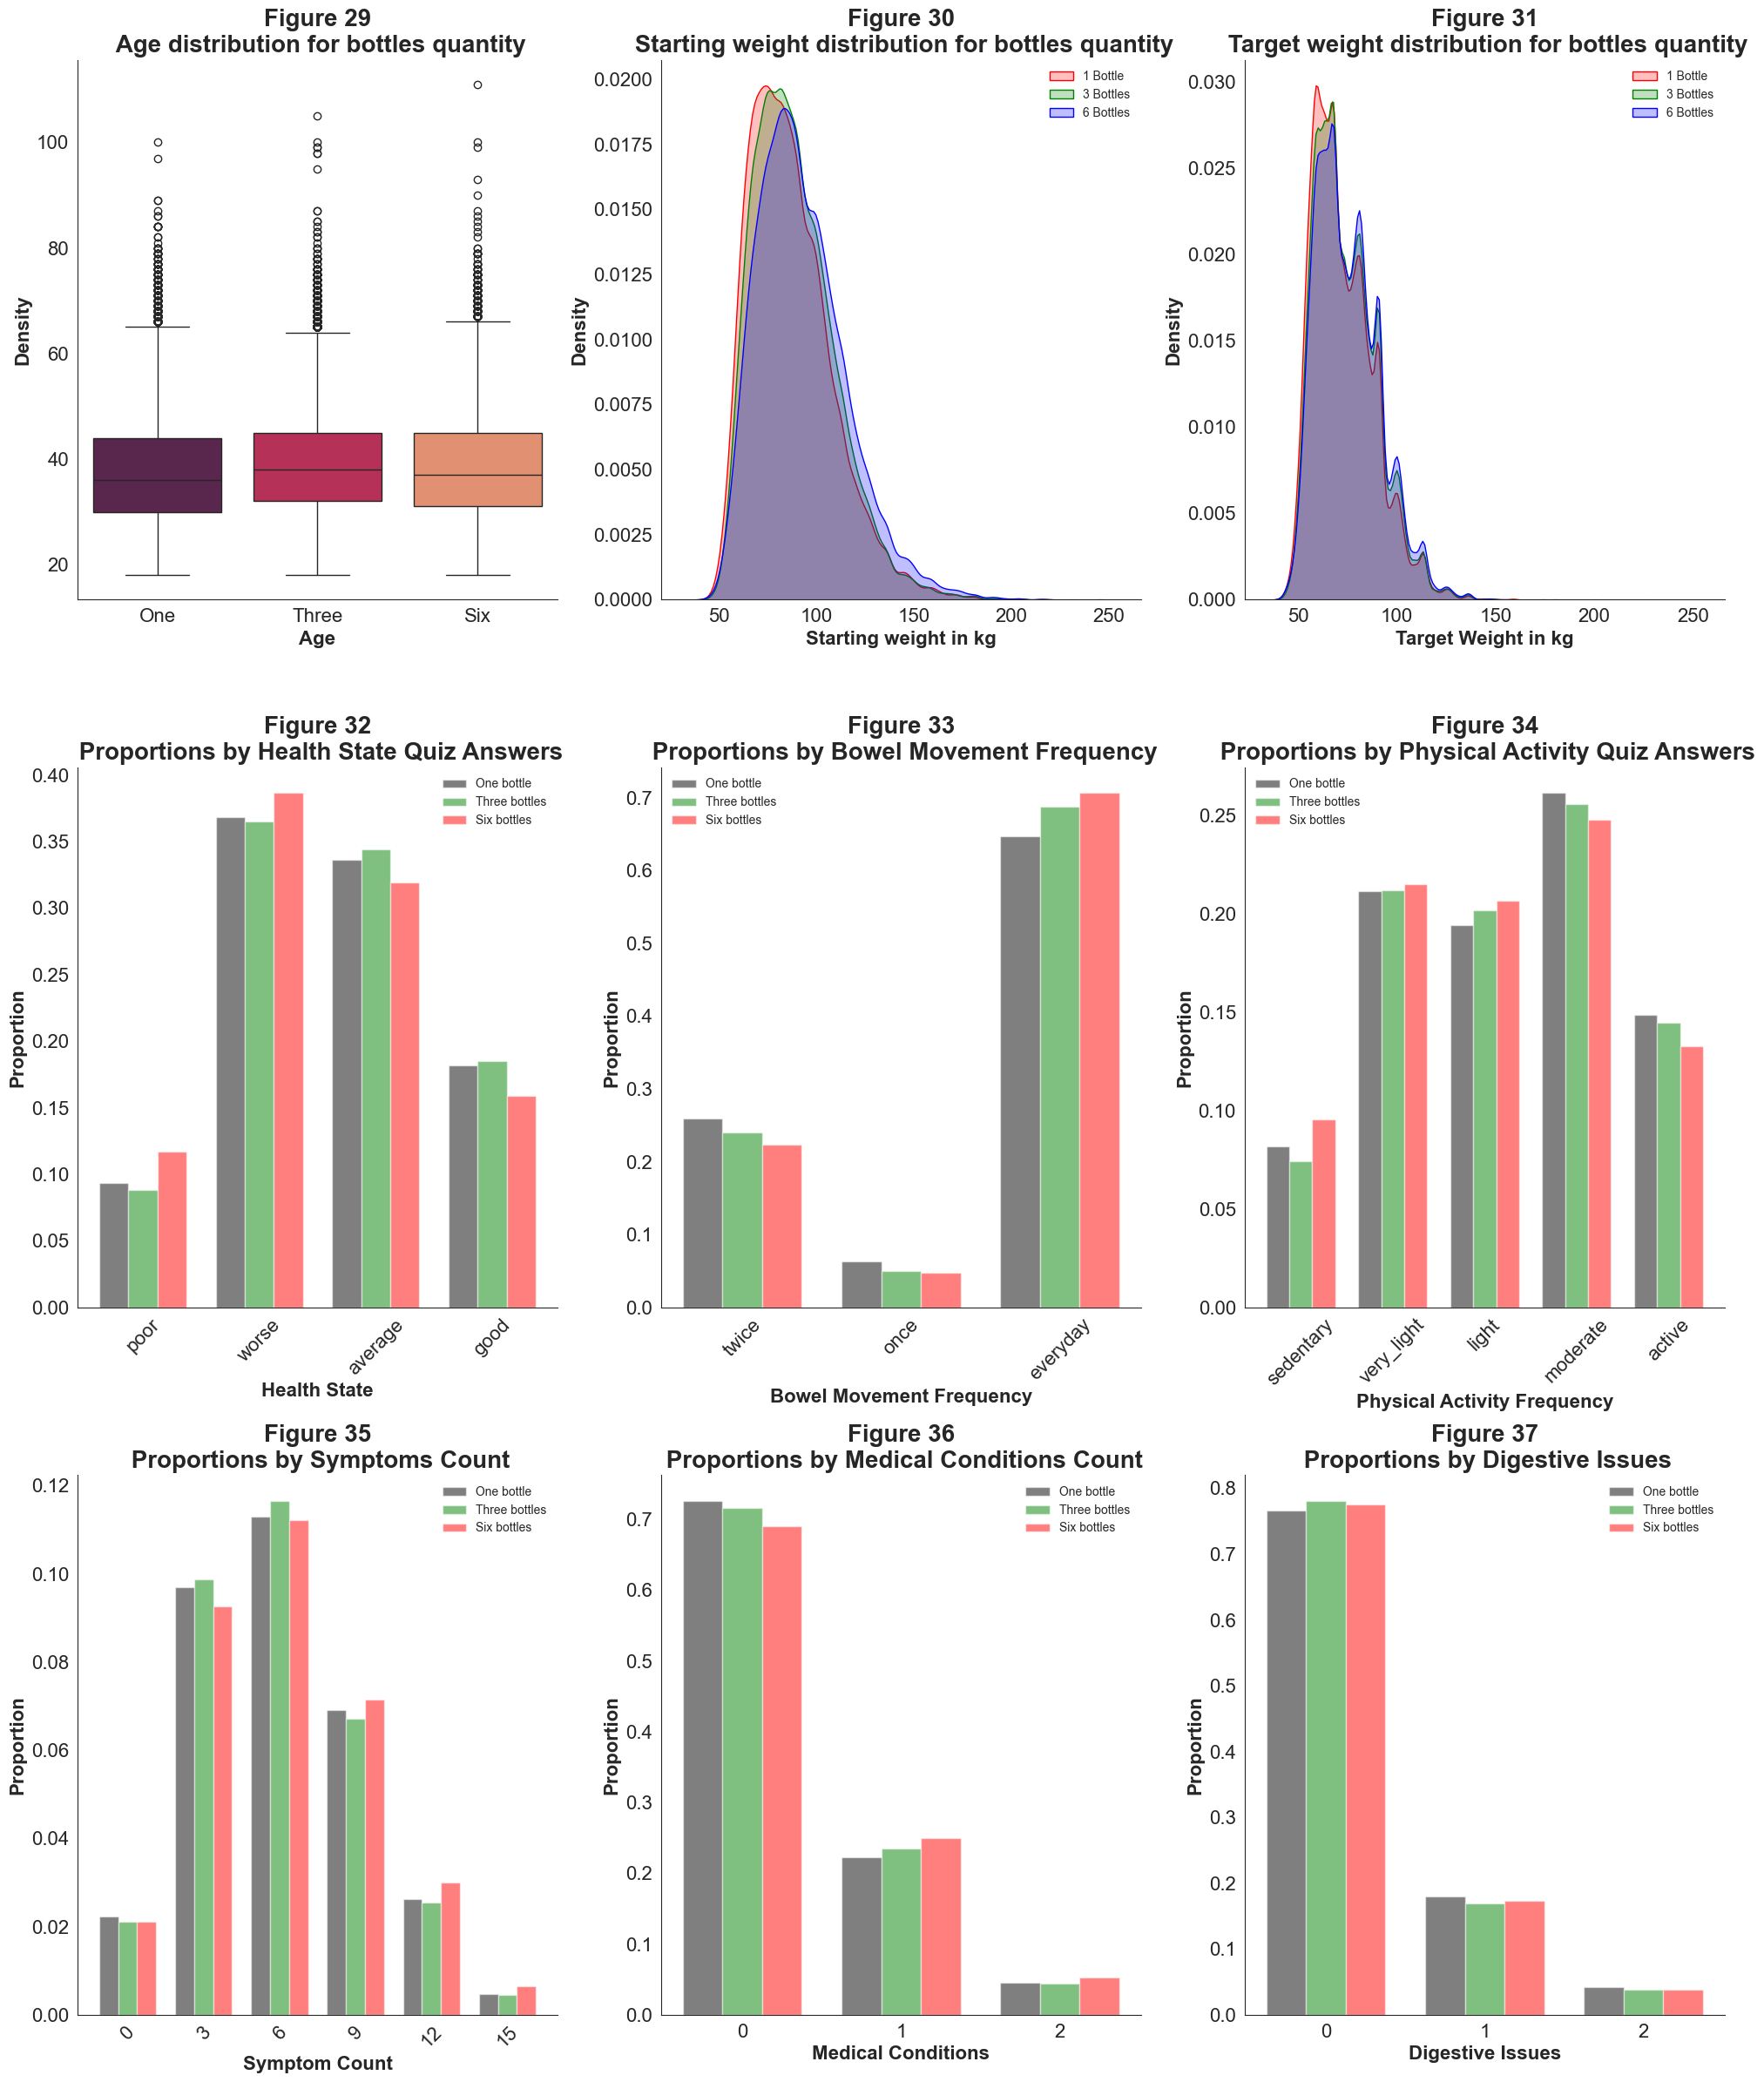

In [53]:
sns.set_style("white")

fig, axs = plt.subplots(3, 3, figsize=(20, 24))

sns.boxplot(x='bottles', y='age', data=combined_b, ax=axs[0,0], palette = 'rocket')
axs[0, 0].set_title('Figure 29\n Age distribution for bottles quantity', fontweight='bold', fontsize=20)
axs[0, 0].set_xlabel('Age', fontweight = 'bold', fontsize=16)
axs[0, 0].set_ylabel('Density', fontweight = 'bold', fontsize=16)
legend = axs[0,0].legend()
legend.get_frame().set_linewidth(0)

sns.kdeplot(x=one_b['starting_weight_in_kg'], fill=True, color='red', ax=axs[0, 1], label='1 Bottle')
sns.kdeplot(x=three_b['starting_weight_in_kg'], fill=True, color='green', ax=axs[0, 1], label='3 Bottles')
sns.kdeplot(x=six_b['starting_weight_in_kg'], fill=True, color='blue', ax=axs[0, 1], label='6 Bottles')

axs[0, 1].set_title('Figure 30\n Starting weight distribution for bottles quantity', fontweight='bold', fontsize=20)
axs[0, 1].set_xlabel('Starting weight in kg', fontweight = 'bold', fontsize=16)
axs[0, 1].set_ylabel('Density', fontweight = 'bold', fontsize=16)
legend = axs[0,1].legend()
legend.get_frame().set_linewidth(0)

sns.kdeplot(one_b['target_weight_in_kg'], fill=True, color='red', ax=axs[0, 2], label='1 Bottle')
sns.kdeplot(three_b['target_weight_in_kg'], fill=True, color='green', ax=axs[0, 2], label='3 Bottles')
sns.kdeplot(six_b['target_weight_in_kg'], fill=True, color='blue', ax=axs[0, 2], label='6 Bottles')

axs[0, 2].set_title('Figure 31\n Target weight distribution for bottles quantity', fontweight='bold', fontsize=20)
axs[0, 2].set_xlabel('Target Weight in kg', fontweight = 'bold', fontsize=16)
axs[0, 2].set_ylabel('Density', fontweight = 'bold', fontsize=16)
legend = axs[0,2].legend()
legend.get_frame().set_linewidth(0)

health_1 = one_b['quiz_health_state'].value_counts(normalize=True).sort_index()
health_3 = three_b['quiz_health_state'].value_counts(normalize=True).sort_index()
health_6 = six_b['quiz_health_state'].value_counts(normalize=True).sort_index()
categories_of_interest = ['poor', 'worse', 'average', 'good']
health_1_filtered = health_1.loc[categories_of_interest]
health_3_filtered = health_3.loc[categories_of_interest]
health_6_filtered = health_6.loc[categories_of_interest]
bar_width = 0.25  
r1 = np.arange(len(categories_of_interest)) 
r2 = [x + bar_width for x in r1] 
r3 = [x + bar_width for x in r2] 
axs[1,0].bar(r1, health_1_filtered, color='black', alpha=0.5, width=bar_width, label='One bottle')
axs[1,0].bar(r2, health_3_filtered, color='green', alpha=0.5, width=bar_width, label='Three bottles')
axs[1,0].bar(r3, health_6_filtered, color='red', alpha=0.5, width=bar_width, label='Six bottles')
axs[1,0].set_title('Figure 32\n Proportions by Health State Quiz Answers', fontweight='bold', fontsize=20)
axs[1,0].set_xlabel('Health State', fontweight = 'bold', fontsize=16)
axs[1,0].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[1,0].set_xticks(r2) 
axs[1,0].set_xticklabels(categories_of_interest, rotation=45)
legend = axs[1,0].legend()
legend.get_frame().set_linewidth(0)

poop_1 = one_b['quiz_poop'].value_counts(normalize=True).sort_index()
poop_3 = three_b['quiz_poop'].value_counts(normalize=True).sort_index()
poop_6 = six_b['quiz_poop'].value_counts(normalize=True).sort_index()
categories_of_interest = ['twice', 'once','everyday' ]
poop_1_filtered = poop_1.loc[categories_of_interest]
poop_3_filtered = poop_3.loc[categories_of_interest]
poop_6_filtered = poop_6.loc[categories_of_interest]
bar_width = 0.25
r1 = np.arange(len(categories_of_interest))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
axs[1,1].bar(r1, poop_1_filtered, color='black', alpha=0.5, width=bar_width, label='One bottle')
axs[1,1].bar(r2, poop_3_filtered, color='green', alpha=0.5, width=bar_width, label='Three bottles')
axs[1,1].bar(r3, poop_6_filtered, color='red', alpha=0.5, width=bar_width, label='Six bottles')
axs[1,1].set_title('Figure 33\n Proportions by Bowel Movement Frequency', fontweight='bold', fontsize=20)
axs[1,1].set_xlabel('Bowel Movement Frequency', fontweight = 'bold', fontsize=16)
axs[1,1].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[1,1].set_xticks(r2)
axs[1,1].set_xticklabels(categories_of_interest, rotation=45)
legend = axs[1,1].legend()
legend.get_frame().set_linewidth(0)

active_1 = one_b['quiz_physically_active'].value_counts(normalize=True).sort_index()
active_3 = three_b['quiz_physically_active'].value_counts(normalize=True).sort_index()
active_6 = six_b['quiz_physically_active'].value_counts(normalize=True).sort_index()
categories_of_interest = ['sedentary', 'very_light', 'light', 'moderate', 'active']
active_1_filtered = active_1.loc[categories_of_interest]
active_3_filtered = active_3.loc[categories_of_interest]
active_6_filtered = active_6.loc[categories_of_interest]
bar_width = 0.25
r1 = np.arange(len(categories_of_interest))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
axs[1,2].bar(r1, active_1_filtered, color='black', alpha=0.5, width=bar_width, label='One bottle')
axs[1,2].bar(r2, active_3_filtered, color='green', alpha=0.5, width=bar_width, label='Three bottles')
axs[1,2].bar(r3, active_6_filtered, color='red', alpha=0.5, width=bar_width, label='Six bottles')
axs[1,2].set_title('Figure 34\n Proportions by Physical Activity Quiz Answers', fontweight='bold', fontsize=20)
axs[1,2].set_xlabel('Physical Activity Frequency', fontweight = 'bold', fontsize=16)
axs[1,2].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[1,2].set_xticks(r2)
axs[1,2].set_xticklabels(categories_of_interest, rotation=45)
legend = axs[1,2].legend()
legend.get_frame().set_linewidth(0)

one_b['symptom_count'] = one_b.apply(calculate_symptom_sum, axis=1)
three_b['symptom_count'] = three_b.apply(calculate_symptom_sum, axis=1)
six_b['symptom_count'] = six_b.apply(calculate_symptom_sum, axis=1)
symptoms_1 = one_b['symptom_count'].value_counts(normalize=True).sort_index()
symptoms_3 = three_b['symptom_count'].value_counts(normalize=True).sort_index()
symptoms_6 = six_b['symptom_count'].value_counts(normalize=True).sort_index()
categories_of_interest = [0, 3, 6, 9, 12, 15]
symptoms_1_filtered = symptoms_1.loc[categories_of_interest]
symptoms_3_filtered = symptoms_3.loc[categories_of_interest]
symptoms_6_filtered = symptoms_6.loc[categories_of_interest]
bar_width = 0.25 
r1 = np.arange(len(categories_of_interest)) 
r2 = [x + bar_width for x in r1]  
r3 = [x + bar_width for x in r2] 
axs[2,0].bar(r1, symptoms_1_filtered, color='black', alpha=0.5, width=bar_width, label='One bottle')
axs[2,0].bar(r2, symptoms_3_filtered, color='green', alpha=0.5, width=bar_width, label='Three bottles')
axs[2,0].bar(r3, symptoms_6_filtered, color='red', alpha=0.5, width=bar_width, label='Six bottles')
axs[2,0].set_title('Figure 35\n Proportions by Symptoms Count', fontweight='bold', fontsize=20)
axs[2,0].set_xlabel('Symptom Count', fontweight = 'bold', fontsize=16)
axs[2,0].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[2,0].set_xticks(r2)
axs[2,0].set_xticklabels(categories_of_interest, rotation=45)
legend = axs[2,0].legend()
legend.get_frame().set_linewidth(0)

one_b['medical_count'] = one_b.apply(calculate_medical_sum, axis=1)
three_b['medical_count'] = three_b.apply(calculate_medical_sum, axis=1)
six_b['medical_count'] = six_b.apply(calculate_medical_sum, axis=1)
medical_1 = one_b['medical_count'].value_counts(normalize=True).sort_index()
medical_3 = three_b['medical_count'].value_counts(normalize=True).sort_index()
medical_6 = six_b['medical_count'].value_counts(normalize=True).sort_index()
categories_of_interest = [0, 1, 2]
medical_1_filtered = medical_1.loc[categories_of_interest]
medical_3_filtered = medical_3.loc[categories_of_interest]
medical_6_filtered = medical_6.loc[categories_of_interest]
bar_width = 0.25 
r1 = np.arange(len(categories_of_interest))
r2 = [x + bar_width for x in r1] 
r3 = [x + bar_width for x in r2] 
axs[2,1].bar(r1, medical_1_filtered, color='black', alpha=0.5, width=bar_width, label='One bottle')
axs[2,1].bar(r2, medical_3_filtered, color='green', alpha=0.5, width=bar_width, label='Three bottles')
axs[2,1].bar(r3, medical_6_filtered, color='red', alpha=0.5, width=bar_width, label='Six bottles')
axs[2,1].set_title('Figure 36\n Proportions by Medical Conditions Count', fontweight='bold', fontsize=20)
axs[2,1].set_xlabel('Medical Conditions', fontweight = 'bold', fontsize=16)
axs[2,1].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[2,1].set_xticks(r2)
axs[2,1].set_xticklabels(categories_of_interest, rotation=0) 
legend = axs[2,1].legend()
legend.get_frame().set_linewidth(0)

one_b['digestive_count'] = one_b.apply(calculate_digestive_count, axis=1)
three_b['digestive_count'] = three_b.apply(calculate_digestive_count, axis=1)
six_b['digestive_count'] = six_b.apply(calculate_digestive_count, axis=1)
digestive_1 = one_b['digestive_count'].value_counts(normalize=True).sort_index()
digestive_3 = three_b['digestive_count'].value_counts(normalize=True).sort_index()
digestive_6 = six_b['digestive_count'].value_counts(normalize=True).sort_index()
categories_of_interest = [0, 1, 2]
digestive_1_filtered = digestive_1.loc[categories_of_interest]
digestive_3_filtered = digestive_3.loc[categories_of_interest]
digestive_6_filtered = digestive_6.loc[categories_of_interest]
bar_width = 0.25
r1 = np.arange(len(categories_of_interest))
r2 = [x + bar_width for x in r1] 
r3 = [x + bar_width for x in r2]
axs[2,2].bar(r1, digestive_1_filtered, color='black', alpha=0.5, width=bar_width, label='One bottle')
axs[2,2].bar(r2, digestive_3_filtered, color='green', alpha=0.5, width=bar_width, label='Three bottles')
axs[2,2].bar(r3, digestive_6_filtered, color='red', alpha=0.5, width=bar_width, label='Six bottles')
axs[2,2].set_title('Figure 37\n Proportions by Digestive Issues', fontweight='bold', fontsize=20)
axs[2,2].set_xlabel('Digestive Issues', fontweight = 'bold', fontsize=16)
axs[2,2].set_ylabel('Proportion', fontweight = 'bold', fontsize=16)
axs[2,2].set_xticks(r2)
axs[2,2].set_xticklabels(categories_of_interest, rotation=0)
legend = axs[2,2].legend()
legend.get_frame().set_linewidth(0)


for row in axs:
    for ax in row:
        ax.tick_params(axis='both', which='major', labelsize=16, width=3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()


### Figure 29 shows that one bottle buyers are younger than the three or six bottle buyers, as indicated by the mean and quartiles. Three bottle buyers seem to have the highest median age of customers.  
### Figure 30 states that people who weight around 70 kilograms are the majority of one and three bottle buyers. While people who weight more are the majority of 6 bottle buyers’ group.
### Figure 31 indicates that lower target-weight people are buyers of low and medium quantities while people with higher target weight select 6 bottles. 
### Figure 32 concludes that people who feel poor and worse than average are the buyers of six bottles the most and people who feel average and good mostly buy medium number of bottles and are least likely to buy 6 bottles.  However, the differences between quantities in ‘good’ and ‘average’ do not differ that much as in ‘worse’ and ‘poor’. People with bad health state buy 6 bottles more and people who feel better order 1 or 3. 
### Figure 33 indicates that if bowel movement is not frequent, person is more likely to buy 1 or 3 bottles while higher frequencies of bowel make it more likely to buy 6. The relationship between bars in ‘twice’ and ‘everyday’ has negative correlation. 
### Figure 34 shows that people who have low physical activity are more likely to become buyers of six bottles, while active people tend to buy one or three. The differences between bought quantities are larger on the maximum and minimum physical activity when compared to medium activity. 
### Figure 35 concludes a relationship between number of symptoms and quantity of products. When the number of symptoms rise, people are more likely to buy more bottles. 
### Figure 36 shows that if the person has no medical conditions, he is most likely to buy one bottle and if the number of medical conditions rise, he is more likely to order six than lower number of bottles. But the difference in distribution of data is significantly small or close to no relationship. 
### Figure 37 indicates that there is no significant relationship between number of digestive issues and quantity of bottles. 

# What key characteristics differentiate customers who respond positively to upsell strategies from those who do not? How does the success of an upsell strategy depend on the customer’s initial purchase?

### Firstly, lets take a look at the overall data

In [54]:
print(f'{buyers.client_id.nunique()} unique buyers')
print(f'{buyers.client_id.count()} overall sales')
print(f'Out of all the sales {buyers.is_upsell.value_counts()}')
initial_purchase_ids = buyers[buyers['is_upsell'] == 'No']['client_id']
upsell_ids = buyers[(buyers['is_upsell'] == 'Yes') & (buyers['country'] == 'United States')]['client_id']
upsells_without_initial_purchase = upsell_ids[~upsell_ids.isin(initial_purchase_ids)]
if len(upsells_without_initial_purchase) == 0:
    print("All upsells have corresponding initial product purchases.")
else:
    print(f"There are {upsells_without_initial_purchase.count()} upsells recorded without initial product purchases.")

102619 unique buyers
122100 overall sales
Out of all the sales is_upsell
No     103158
Yes     18942
Name: count, dtype: int64
There are 34 upsells recorded without initial product purchases.


In [55]:
buyers[buyers['client_id'].isin(upsells_without_initial_purchase)].head(10)

,client_id,flavour,sub_project,item_category,quantity,is_subscription,is_upsell,is_supplement,order_id,item_amount_in_usd,country,gender,age,starting_bmi,starting_weight_in_kg,target_weight_in_kg,quiz_health_state,quiz_linked_to,quiz_poop,quiz_symptoms,quiz_symptoms_two,quiz_allergies,quiz_medical_conditions,quiz_digestive,quiz_physically_active,quiz_leisure,quiz_pregnant,quiz_breastfeeding,lead_id,pregnant,buyers,symptom_count,allergy_count,medical_count,digestive_count
275,233.0,none,Original,DF 3 Month Supply Box,3.0,No,Yes,Yes,2437144.0,97.97,United States,female,49.0,27.375650,65.77,61.23,great,bloating,everyday,sugar,digestion,lactose,none,none,often,30-60min,no,no,NaN,NaN,Buyers,2,1,0,0
276,233.0,none,Original,DF 3 Month Supply Box,3.0,No,Yes,Yes,2437150.0,97.97,United States,female,49.0,27.375650,65.77,61.23,great,bloating,everyday,sugar,digestion,lactose,none,none,often,30-60min,no,no,NaN,NaN,Buyers,2,1,0,0
1293,1089.0,none,Original,DF Capsules,1.0,No,Yes,Yes,2298408.0,29.99,United States,female,54.0,26.430801,63.50,56.70,average,"bloating, weight_gain",everyday,"sugar, Backache","pain, appetite",lactose,thyroid,none,sometimes,little,no,no,NaN,NaN,Buyers,4,1,1,0
1732,1476.0,none,Original,DF Capsules,1.0,No,Yes,Yes,2612872.0,77.97,United States,female,44.0,30.888479,77.11,68.04,average,"bloating, weight_gain, constipation",everyday,heartburn,"appetite, digestion",none,thyroid,none,sometimes,15-30min,no,no,NaN,NaN,Buyers,3,0,1,0
1733,1476.0,none,Original,DF 6 Month Supply Box,6.0,No,Yes,Yes,2612866.0,155.94,United States,female,44.0,30.888479,77.11,68.04,average,"bloating, weight_gain, constipation",everyday,heartburn,"appetite, digestion",none,thyroid,none,sometimes,15-30min,no,no,NaN,NaN,Buyers,3,0,1,0
3501,2973.0,none,Original,DF 6 Month Supply Box,6.0,No,Yes,Yes,2274294.0,155.94,United States,female,57.0,60.416233,145.15,90.72,poor,"bloating, weight_gain, constipation",twice,"fatigue, fluctuations, heartburn, sugar","mood, appetite, pain, bowels_movements",none,"gout, diabetes, cholesterol",IBS,sedentary,15-30min,no,no,NaN,NaN,Buyers,8,0,3,1
3502,2973.0,none,Original,Sugar Cravings,6.0,No,Yes,Yes,2274284.0,95.95,United States,female,57.0,60.416233,145.15,90.72,poor,"bloating, weight_gain, constipation",twice,"fatigue, fluctuations, heartburn, sugar","mood, appetite, pain, bowels_movements",none,"gout, diabetes, cholesterol",IBS,sedentary,15-30min,no,no,NaN,NaN,Buyers,8,0,3,1
3651,3100.0,None,Original,Fat Burners,6.0,No,Yes,Yes,2680500.0,79.98,United States,male,27.0,20.657905,83.46,77.11,average,"bloating, weight_gain",everyday,sugar,"pain, appetite",none,none,none,moderate,30-60min,undisclosed,no,NaN,no,Buyers,3,0,0,0
3672,3116.0,none,Original,DF Capsules,1.0,No,Yes,Yes,2391282.0,77.97,United States,female,51.0,23.672216,71.67,67.13,good,"constipation, weight_gain, bloating",everyday,"fatigue, skin, stomach","bowels_movements, digestion, stomach_cramping",none,none,IBS,light,30-60min,no,no,NaN,NaN,Buyers,6,0,0,1
3806,3237.0,none,Original,DF Capsules,1.0,No,Yes,Yes,2295993.0,29.99,United States,female,32.0,24.429563,68.95,56.70,average,"weight_gain, bloating",everyday,"fatigue, moodswings, sugar, hunger, skin",none,none,thyroid,gastritis,moderate,15-30min,no,no,NaN,NaN,Buyers,5,0,1,1


### It looks like there is a small number of upsale purchases without an initial non-upsale purchase. However, there doesn't seem to be any correlating features amongst these observations. Since there are only 34 of them, they are not consequential, so we decide it is best to delete clients whith data that follows such characteristics.

In [56]:
buyers = buyers[~buyers['client_id'].isin(upsells_without_initial_purchase)]

### Next to answer the question of what kind of customers react well to upsale strategies, we perform a more in-depth analysis of their features and compare upsale sales to simple sales

In [57]:
no_upsell_ids = buyers[~buyers['client_id'].isin(buyers[buyers['is_upsell'] == True]['client_id'])]['client_id']
print("Client IDs with no upsells:")
print(no_upsell_ids.head())

Client IDs with no upsells:
0    1.0
1    2.0
3    4.0
4    5.0
5    6.0
Name: client_id, dtype: float64


In [58]:
upsale_clients = buyers[buyers['client_id'].isin(upsell_ids)]
non_upsale_clients = buyers[buyers['client_id'].isin(no_upsell_ids)]
buyers['upsell_id'] = np.where(buyers['client_id'].isin(upsell_ids), 'upsale', 'non-upsale')

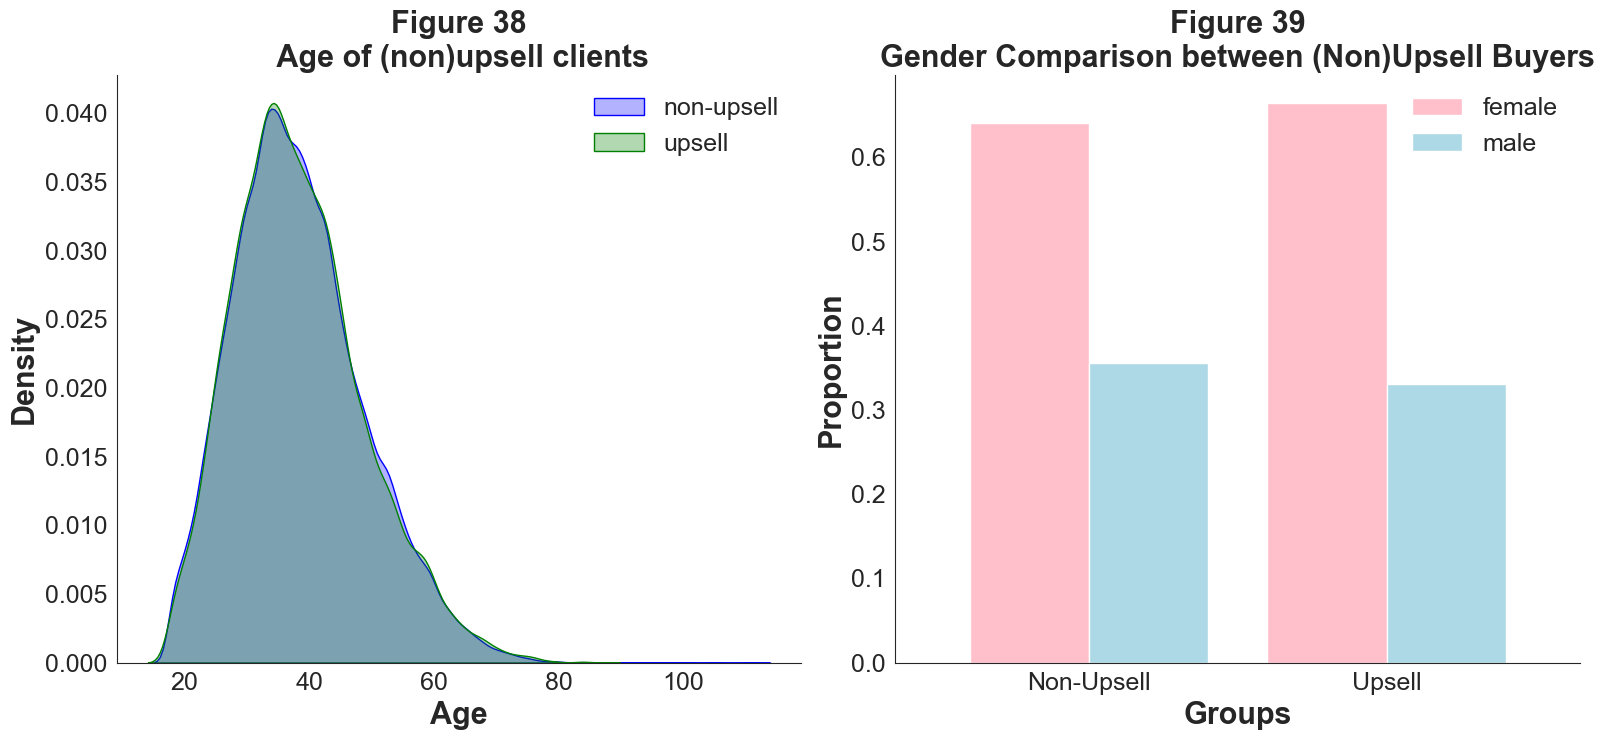

In [59]:
sns.set_style("white")
fig, axs = plt.subplots(1, 2, figsize=(16, 7.5)) 

sns.kdeplot(x=non_upsale_clients['age'], fill=True, color='blue', alpha=0.3, ax=axs[0], label='non-upsell')
sns.kdeplot(x=upsale_clients['age'], fill=True, color='green', alpha=0.3, ax=axs[0], label='upsell')
axs[0].set_title('Figure 38\n Age of (non)upsell clients', fontsize=22, fontweight='bold') 
axs[0].set_xlabel('Age', fontsize=22, fontweight='bold') 
axs[0].set_ylabel('Density', fontsize=22, fontweight='bold')
legend = axs[0].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

gender_counts = buyers.groupby('upsell_id')['gender'].value_counts(normalize=True).rename('Proportion').reset_index()
pivot_data = gender_counts.pivot(index='upsell_id', columns='gender', values='Proportion')
pivot_data = pivot_data[['female', 'male']]
pivot_data.plot(kind='bar', stacked=False, ax=axs[1], color=['pink', 'lightblue'], width=0.8)
axs[1].set_title('Figure 39\nGender Comparison between (Non)Upsell Buyers', fontsize=22, fontweight='bold')
axs[1].set_xlabel('Groups', rotation=0, fontsize=22, fontweight='bold')
axs[1].set_ylabel('Proportion', fontsize=22, fontweight='bold')
axs[1].set_xticklabels(['Non-Upsell', 'Upsell'], rotation=0)
legend = axs[1].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

for plot in range(0, 2):
    axs[plot].spines['top'].set_visible(False)
    axs[plot].spines['right'].set_visible(False)
    axs[plot].tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()

### Overall, we cannot definitively state that either age or gender can determine the likelihood of a person being susceptible to upsell strategies. The density distribution of upsells and sales from the total population is almost identical. While there seems to be a higher proportion of women in the upsell category, the difference is very minor.

### Next, we move on to check whether starting weight and/or BMI are distributed disproportionately in the upsells when compared to normal sales.

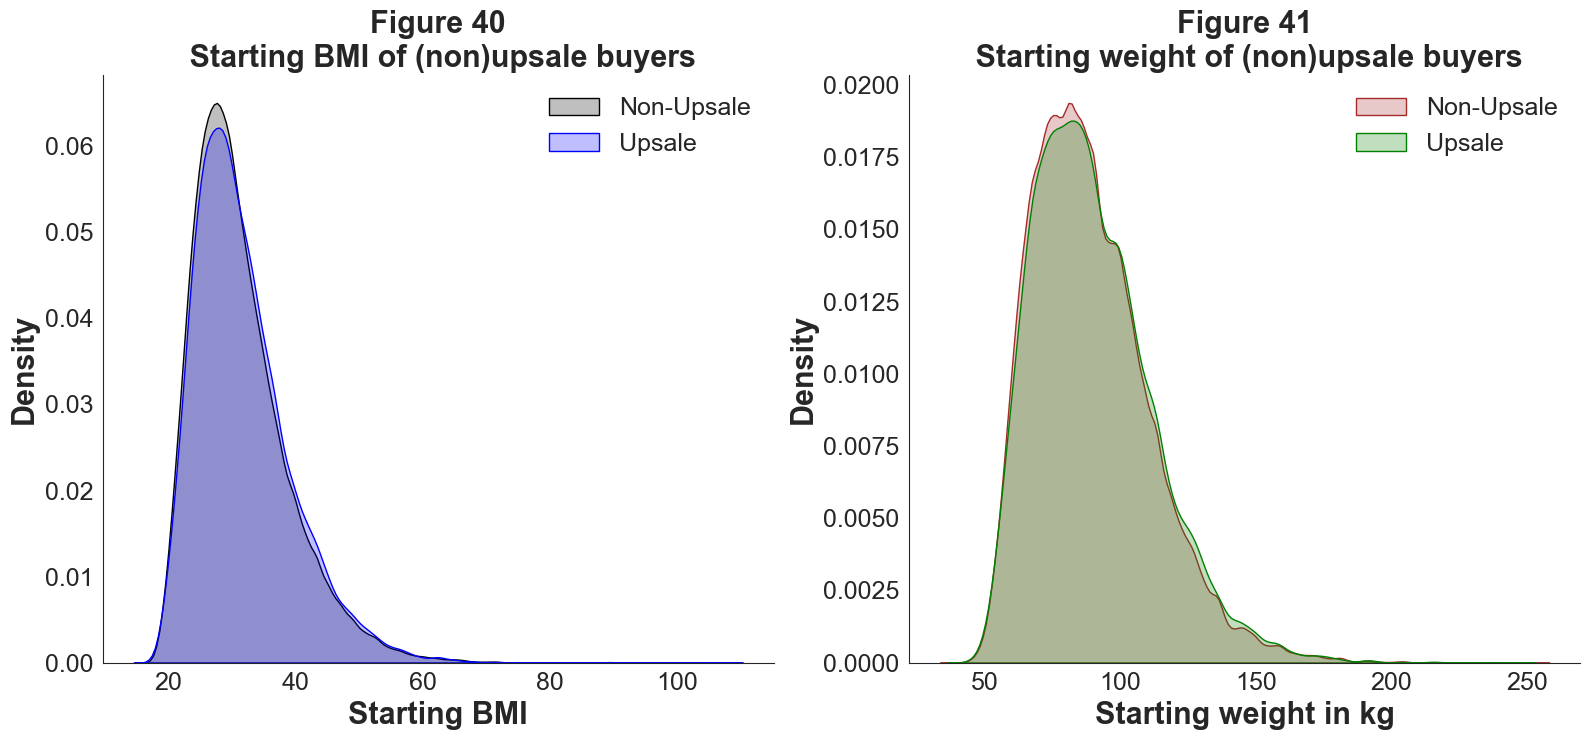

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(16, 7.5))

sns.kdeplot(x=non_upsale_clients['starting_bmi'], fill=True, color='black', ax=axs[0], label='Non-Upsale')
sns.kdeplot(x=upsale_clients['starting_bmi'], fill=True, color='blue', ax=axs[0], label='Upsale')

axs[0].set_title('Figure 40\n Starting BMI of (non)upsale buyers', fontsize=22, fontweight='bold')
axs[0].set_xlabel('Starting BMI', fontsize=22, fontweight='bold')
axs[0].set_ylabel('Density', fontsize=22, fontweight='bold')
legend = axs[0].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

sns.kdeplot(x=non_upsale_clients['starting_weight_in_kg'], fill=True, color='brown', ax=axs[1], label='Non-Upsale')
sns.kdeplot(x=upsale_clients['starting_weight_in_kg'], fill=True, color='green', ax=axs[1], label='Upsale')
axs[1].set_title('Figure 41\n Starting weight of (non)upsale buyers', fontsize=22, fontweight='bold')
axs[1].set_xlabel('Starting weight in kg', fontsize=22, fontweight='bold')
axs[1].set_ylabel('Density', fontsize=22, fontweight='bold')
legend = axs[1].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

for plot in range(0, 2):
    axs[plot].spines['top'].set_visible(False)
    axs[plot].spines['right'].set_visible(False)
    axs[plot].tick_params(axis='both', which='major', labelsize=18)

plt.tight_layout()
plt.show()

### The plots indicate some differences. It looks like there are proportionally fewer people with a healthier weight or, more accurately, a BMI between approximately 25 and 30, and more people on the obese side in the upsells category. This finding also follows logic. Problematically obese people feel more pressure from society as well as their overall health, and hence are more desperate and more susceptible to weight loss supplement upsell strategies.

### Next, we evaluate whether the end-goal weight has any effect.

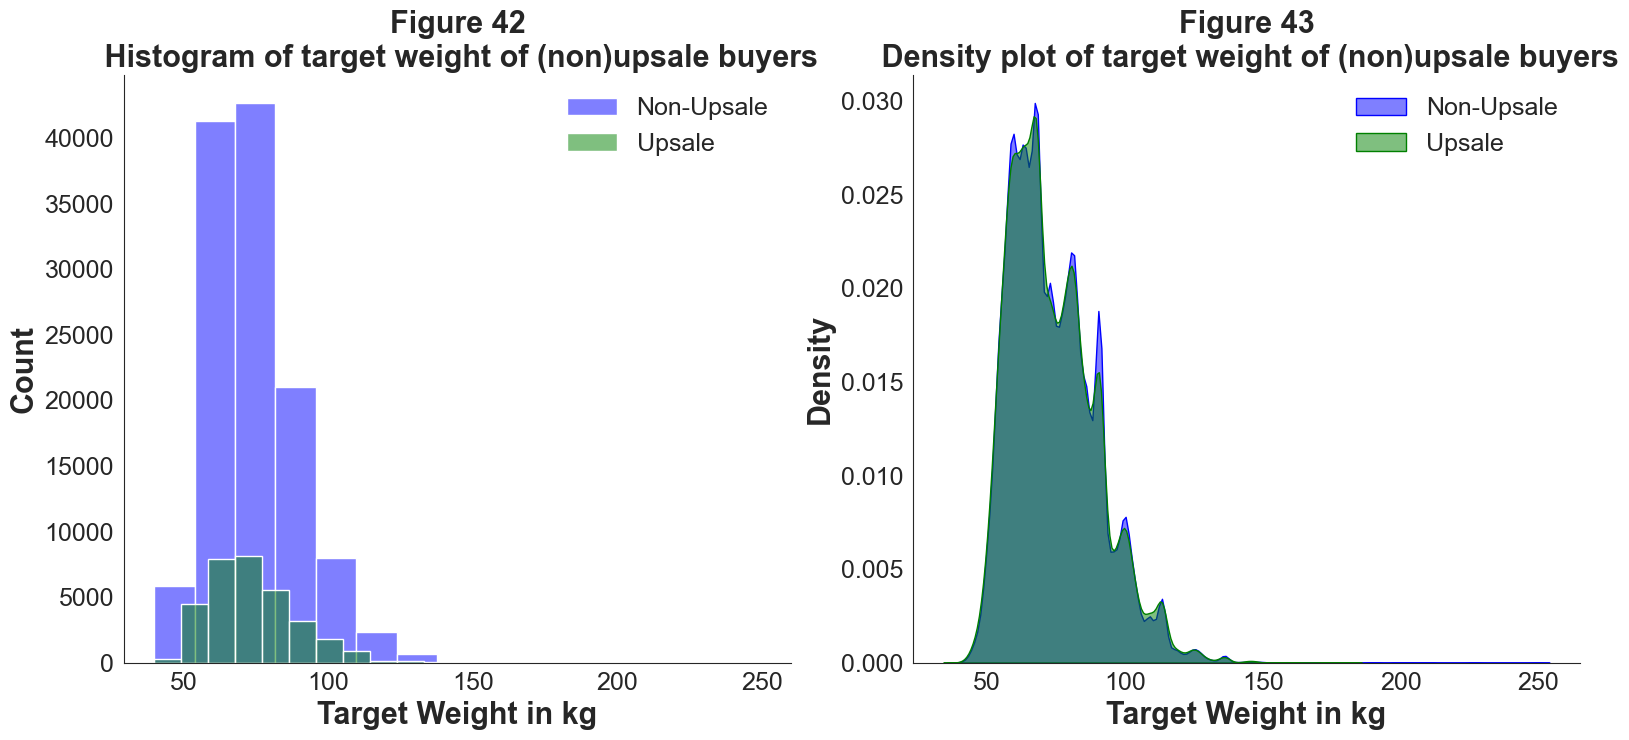

In [61]:
sns.set_style("white")
fig, axs = plt.subplots(1, 2, figsize=(16, 7.5))

sns.histplot(non_upsale_clients['target_weight_in_kg'], bins=15, color='blue', alpha=0.5, ax=axs[0], label='Non-Upsale')
sns.histplot(upsale_clients['target_weight_in_kg'], bins=15, color='green', alpha=0.5, ax=axs[0], label='Upsale')
axs[0].set_title('Figure 42\n Histogram of target weight of (non)upsale buyers', fontsize=22, fontweight='bold')
axs[0].set_xlabel('Target Weight in kg', fontsize=22, fontweight='bold')
axs[0].set_ylabel('Count', fontsize=22, fontweight='bold')
legend = axs[0].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

sns.kdeplot(non_upsale_clients['target_weight_in_kg'], color='blue', alpha=0.5, fill=True, ax=axs[1], label='Non-Upsale')
sns.kdeplot(upsale_clients['target_weight_in_kg'], color='green', alpha=0.5, fill=True, ax=axs[1], label='Upsale')
axs[1].set_title('Figure 43\n Density plot of target weight of (non)upsale buyers', fontsize=22, fontweight='bold')
axs[1].set_xlabel('Target Weight in kg', fontsize=22, fontweight='bold')
axs[1].set_ylabel('Density', fontsize=22, fontweight='bold')
legend = axs[1].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

for plot in range(0, 2):
    axs[plot].tick_params(axis='both', which='major', labelsize=18)
    axs[plot].spines['top'].set_visible(False)
    axs[plot].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### The plots do not seem to indicate any concrete differences in regards to the distribution of target weight for the entire population and upsell clients. There are, however, peaks that do not allow for a normal distribution. What this probably means is that people, regardless of their weight, might have some uniform and irrational image of ideal weight, forming peaks in the distribution. Some peaks, though, seem to be smaller in the upsell category, which seems strange. Perhaps more upsell-susceptible people are less stubborn and more in tune with reality.

### Moving on, we construct graphs showing the distributions of quiz variables for total sales as well as upsells. For categorical variables, the plots show the distributions of different groups, and for more qualitative variables, such as showing what symptoms a buyer has, we simply display the distribution of the number of symptoms for a broad look.

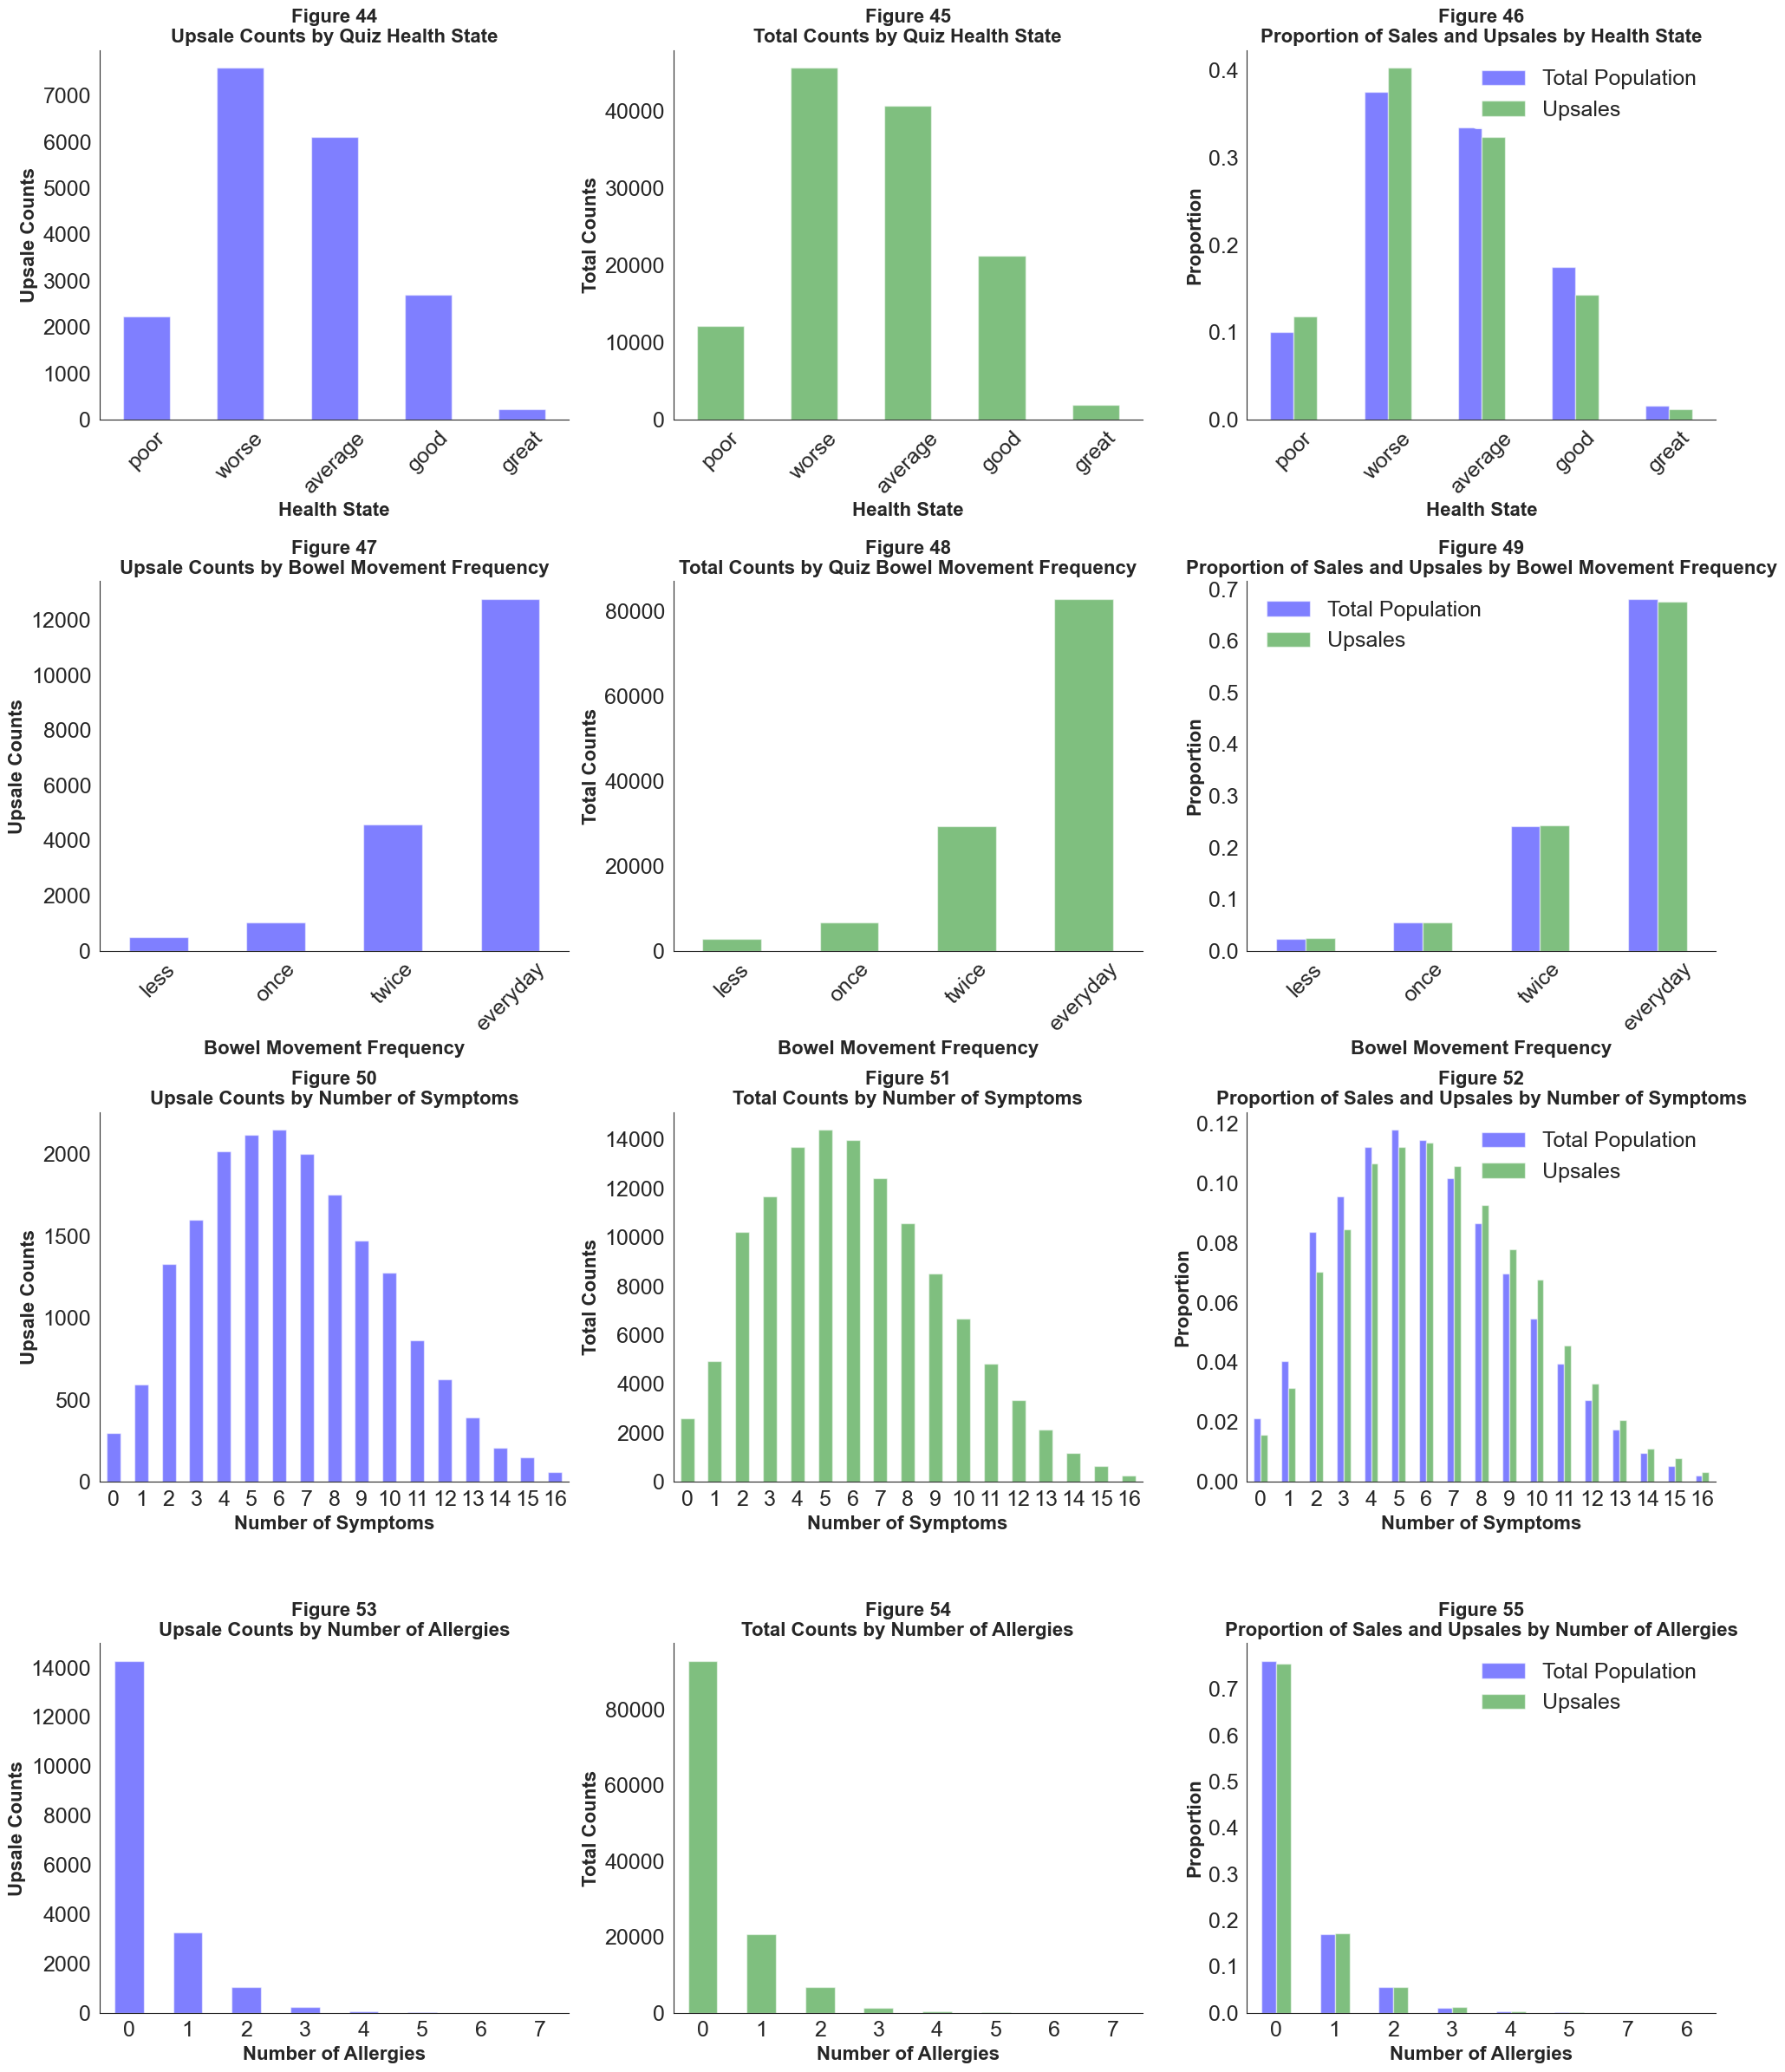

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style("white")

fig, axs = plt.subplots(4, 3, figsize=(20, 24))
axs = axs.flatten()
quiz_health_categories = ['poor', 'worse', 'average', 'good', 'great']
buyers['quiz_health_state'] = pd.Categorical(buyers['quiz_health_state'], categories=quiz_health_categories, ordered=True)
upsale_counts = buyers[buyers['is_upsell'] == 'Yes'].groupby('quiz_health_state').size()
upsale_counts.plot(kind='bar', ax=axs[0], color='blue', alpha=0.5)

axs[0].set_title('Figure 44\nUpsale Counts by Quiz Health State', fontsize=16, fontweight='bold')
axs[0].set_xlabel('Health State', fontsize=16, fontweight='bold')
axs[0].set_ylabel('Upsale Counts', fontsize=16, fontweight='bold')
axs[0].set_xticklabels(upsale_counts.index, rotation=45, fontsize=12)

total_counts = buyers.groupby('quiz_health_state').size()
total_counts.plot(kind='bar', ax=axs[1], color='green', alpha=0.5)
axs[1].set_title('Figure 45\nTotal Counts by Quiz Health State', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Health State', fontsize=16, fontweight='bold')
axs[1].set_ylabel('Total Counts', fontsize=16, fontweight='bold')
axs[1].set_xticklabels(total_counts.index, rotation=45)

total_population_counts = buyers['quiz_health_state'].value_counts(normalize=True).reindex(quiz_health_categories)
upsale_population_counts = buyers[buyers['is_upsell'] == 'Yes']['quiz_health_state'].value_counts(normalize=True).reindex(quiz_health_categories)
com_df = pd.DataFrame({'Total Population': total_population_counts, 'Upsales': upsale_population_counts})
com_df.plot(kind='bar', ax=axs[2], color=['blue', 'green'], alpha=0.5)
axs[2].set_title('Figure 46\nProportion of Sales and Upsales by Health State', fontsize=16, fontweight='bold')
axs[2].set_xlabel('Health State', fontsize=16, fontweight='bold')
axs[2].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[2].set_xticklabels(com_df.index, rotation=45)
legend = axs[2].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

bowel_movement_categories = ['less', 'once', 'twice', 'everyday']

buyers['quiz_poop'] = pd.Categorical(buyers['quiz_poop'], categories=bowel_movement_categories, ordered=True)

upsale_counts = buyers[buyers['is_upsell'] == 'Yes'].groupby('quiz_poop').size()
upsale_counts.plot(kind='bar', ax=axs[3], color='blue', alpha=0.5)
axs[3].set_title('Figure 47\nUpsale Counts by Bowel Movement Frequency', fontsize=16, fontweight='bold')
axs[3].set_xlabel('Bowel Movement Frequency', fontsize=16, fontweight='bold')
axs[3].set_ylabel('Upsale Counts', fontsize=16, fontweight='bold')
axs[3].set_xticklabels(upsale_counts.index, rotation=45)

total_counts = buyers.groupby('quiz_poop').size()
total_counts.plot(kind='bar', ax=axs[4], color='green', alpha=0.5)
axs[4].set_title('Figure 48\nTotal Counts by Quiz Bowel Movement Frequency', fontsize=16, fontweight='bold')
axs[4].set_xlabel('Bowel Movement Frequency', fontsize=16, fontweight='bold')
axs[4].set_ylabel('Total Counts', fontsize=16, fontweight='bold')
axs[4].set_xticklabels(total_counts.index, rotation=45)

total_population_counts = buyers['quiz_poop'].value_counts(normalize=True).reindex(bowel_movement_categories)
upsale_population_counts = buyers[buyers['is_upsell'] == 'Yes']['quiz_poop'].value_counts(normalize=True).reindex(bowel_movement_categories)
com_df = pd.DataFrame({'Total Population': total_population_counts, 'Upsales': upsale_population_counts})
com_df.plot(kind='bar', ax=axs[5], color=['blue', 'green'], alpha=0.5)
axs[5].set_title('Figure 49\nProportion of Sales and Upsales by Bowel Movement Frequency', fontsize=16, fontweight='bold')
axs[5].set_xlabel('Bowel Movement Frequency', fontsize=16, fontweight='bold')
axs[5].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[5].set_xticklabels(com_df.index, rotation=45)
legend = axs[5].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

def calculate_symptom_sum(row):
    symptoms = row['quiz_symptoms'].split(',') + row['quiz_symptoms_two'].split(',')
    symptom_count = sum(1 for symptom in symptoms if symptom not in ['none', ''])
    return symptom_count

buyers['symptom_count'] = buyers.apply(calculate_symptom_sum, axis=1)

upsale_counts = buyers[buyers['is_upsell'] == 'Yes'].groupby('symptom_count').size()
total_counts = buyers.groupby('symptom_count').size()

upsale_counts.plot(kind='bar', ax=axs[6], color='blue', alpha=0.5)
axs[6].set_title('Figure 50\nUpsale Counts by Number of Symptoms', fontsize=16, fontweight='bold')
axs[6].set_xlabel('Number of Symptoms', fontsize=16, fontweight='bold')
axs[6].set_ylabel('Upsale Counts', fontsize=16, fontweight='bold')
axs[6].set_xticks(range(len(upsale_counts)))
axs[6].set_xticklabels(upsale_counts.index, rotation=45)

total_counts.plot(kind='bar', ax=axs[7], color='green', alpha=0.5)
axs[7].set_title('Figure 51\nTotal Counts by Number of Symptoms', fontsize=16, fontweight='bold')
axs[7].set_xlabel('Number of Symptoms', fontsize=16, fontweight='bold')
axs[7].set_ylabel('Total Counts', fontsize=16, fontweight='bold')
axs[7].set_xticks(range(len(total_counts)))
axs[7].set_xticklabels(total_counts.index, rotation=45)


total_population_proportions = buyers['symptom_count'].value_counts(normalize=True)
upsale_population_proportions = buyers[buyers['is_upsell'] == 'Yes']['symptom_count'].value_counts(normalize=True)

comparison_df = pd.DataFrame({'Total Population': total_population_proportions, 'Upsales': upsale_population_proportions})

comparison_df.plot(kind='bar', ax=axs[8], color=['blue', 'green'], alpha=0.5)
axs[8].set_title('Figure 52\nProportion of Sales and Upsales by Number of Symptoms', fontsize=16, fontweight='bold')
axs[8].set_xlabel('Number of Symptoms', fontsize=16, fontweight='bold')
axs[8].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[8].set_xticklabels(comparison_df.index, rotation=45)
legend = axs[8].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

def calculate_allergy_count(row):
    allergies = row['quiz_allergies'].split(',')
    allergy_count = sum(1 for allergy in allergies if allergy not in ['none', '']) 
    return allergy_count

buyers['allergy_count'] = buyers.apply(calculate_allergy_count, axis=1)

upsale_counts = buyers[buyers['is_upsell'] == 'Yes'].groupby('allergy_count').size()
total_counts = buyers.groupby('allergy_count').size()

upsale_counts.plot(kind='bar', ax=axs[9], color='blue', alpha=0.5)
axs[9].set_title('Figure 53\nUpsale Counts by Number of Allergies', fontsize=16, fontweight='bold')
axs[9].set_xlabel('Number of Allergies', fontsize=16, fontweight='bold')
axs[9].set_ylabel('Upsale Counts', fontsize=16, fontweight='bold')
axs[9].set_xticks(range(len(upsale_counts)))
axs[9].set_xticklabels(upsale_counts.index, rotation=45)

total_counts.plot(kind='bar', ax=axs[10], color='green', alpha=0.5)
axs[10].set_title('Figure 54\nTotal Counts by Number of Allergies', fontsize=16, fontweight='bold')
axs[10].set_xlabel('Number of Allergies', fontsize=16, fontweight='bold')
axs[10].set_ylabel('Total Counts', fontsize=16, fontweight='bold')
axs[10].set_xticks(range(len(total_counts)))
axs[10].set_xticklabels(total_counts.index, rotation=45)

total_population_proportions = buyers['allergy_count'].value_counts(normalize=True)
upsale_population_proportions = buyers[buyers['is_upsell'] == 'Yes']['allergy_count'].value_counts(normalize=True)
comparison_df = pd.DataFrame({'Total Population': total_population_proportions, 'Upsales': upsale_population_proportions})
comparison_df.plot(kind='bar', ax=axs[11], color=['blue', 'green'], alpha=0.5)
axs[11].set_title('Figure 55\nProportion of Sales and Upsales by Number of Allergies', fontsize=16, fontweight='bold')
axs[11].set_xlabel('Number of Allergies', fontsize=16, fontweight='bold')
axs[11].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[11].set_xticklabels(comparison_df.index, rotation=45)
legend = axs[11].legend(fontsize=18)
legend.get_frame().set_linewidth(0)

for plot in range(0, 12):
    axs[plot].tick_params(axis='both', which='major', labelsize=18, rotation=0)
    axs[plot].spines['top'].set_visible(False)
    axs[plot].spines['right'].set_visible(False)

for plot in range(0, 6):
    axs[plot].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Firstly, looking at the first row of graphs, we compare the distributions between total sales population and upsells of people with various categories of health state. Even though the distributions are similar, we see a higher proportion of people with worse and poor health states and a lower proportion of average, good, and great health states in the upsells population. It is clear that people suffering from health issues represent a higher portion of upsell sales when compared to all converted orders.

### Secondly, we compare the distributions of bowel movement frequency. Overall, no specific differences could be pinpointed.

### Thirdly, we compare the distributions of the number of symptoms a person has. We can see that, as the number of symptoms increases, their respective proportions in the upsells distribution also increases when compared to the overall sales population. It seems clear and consistent with the results we saw in the health states distribution comparisons; people with more symptoms tend to be more susceptible to upsell techniques.

### Lastly, we also look at allergies. No specific differences are found.

### Next, we analyze the distributions of the remaining quiz variables.

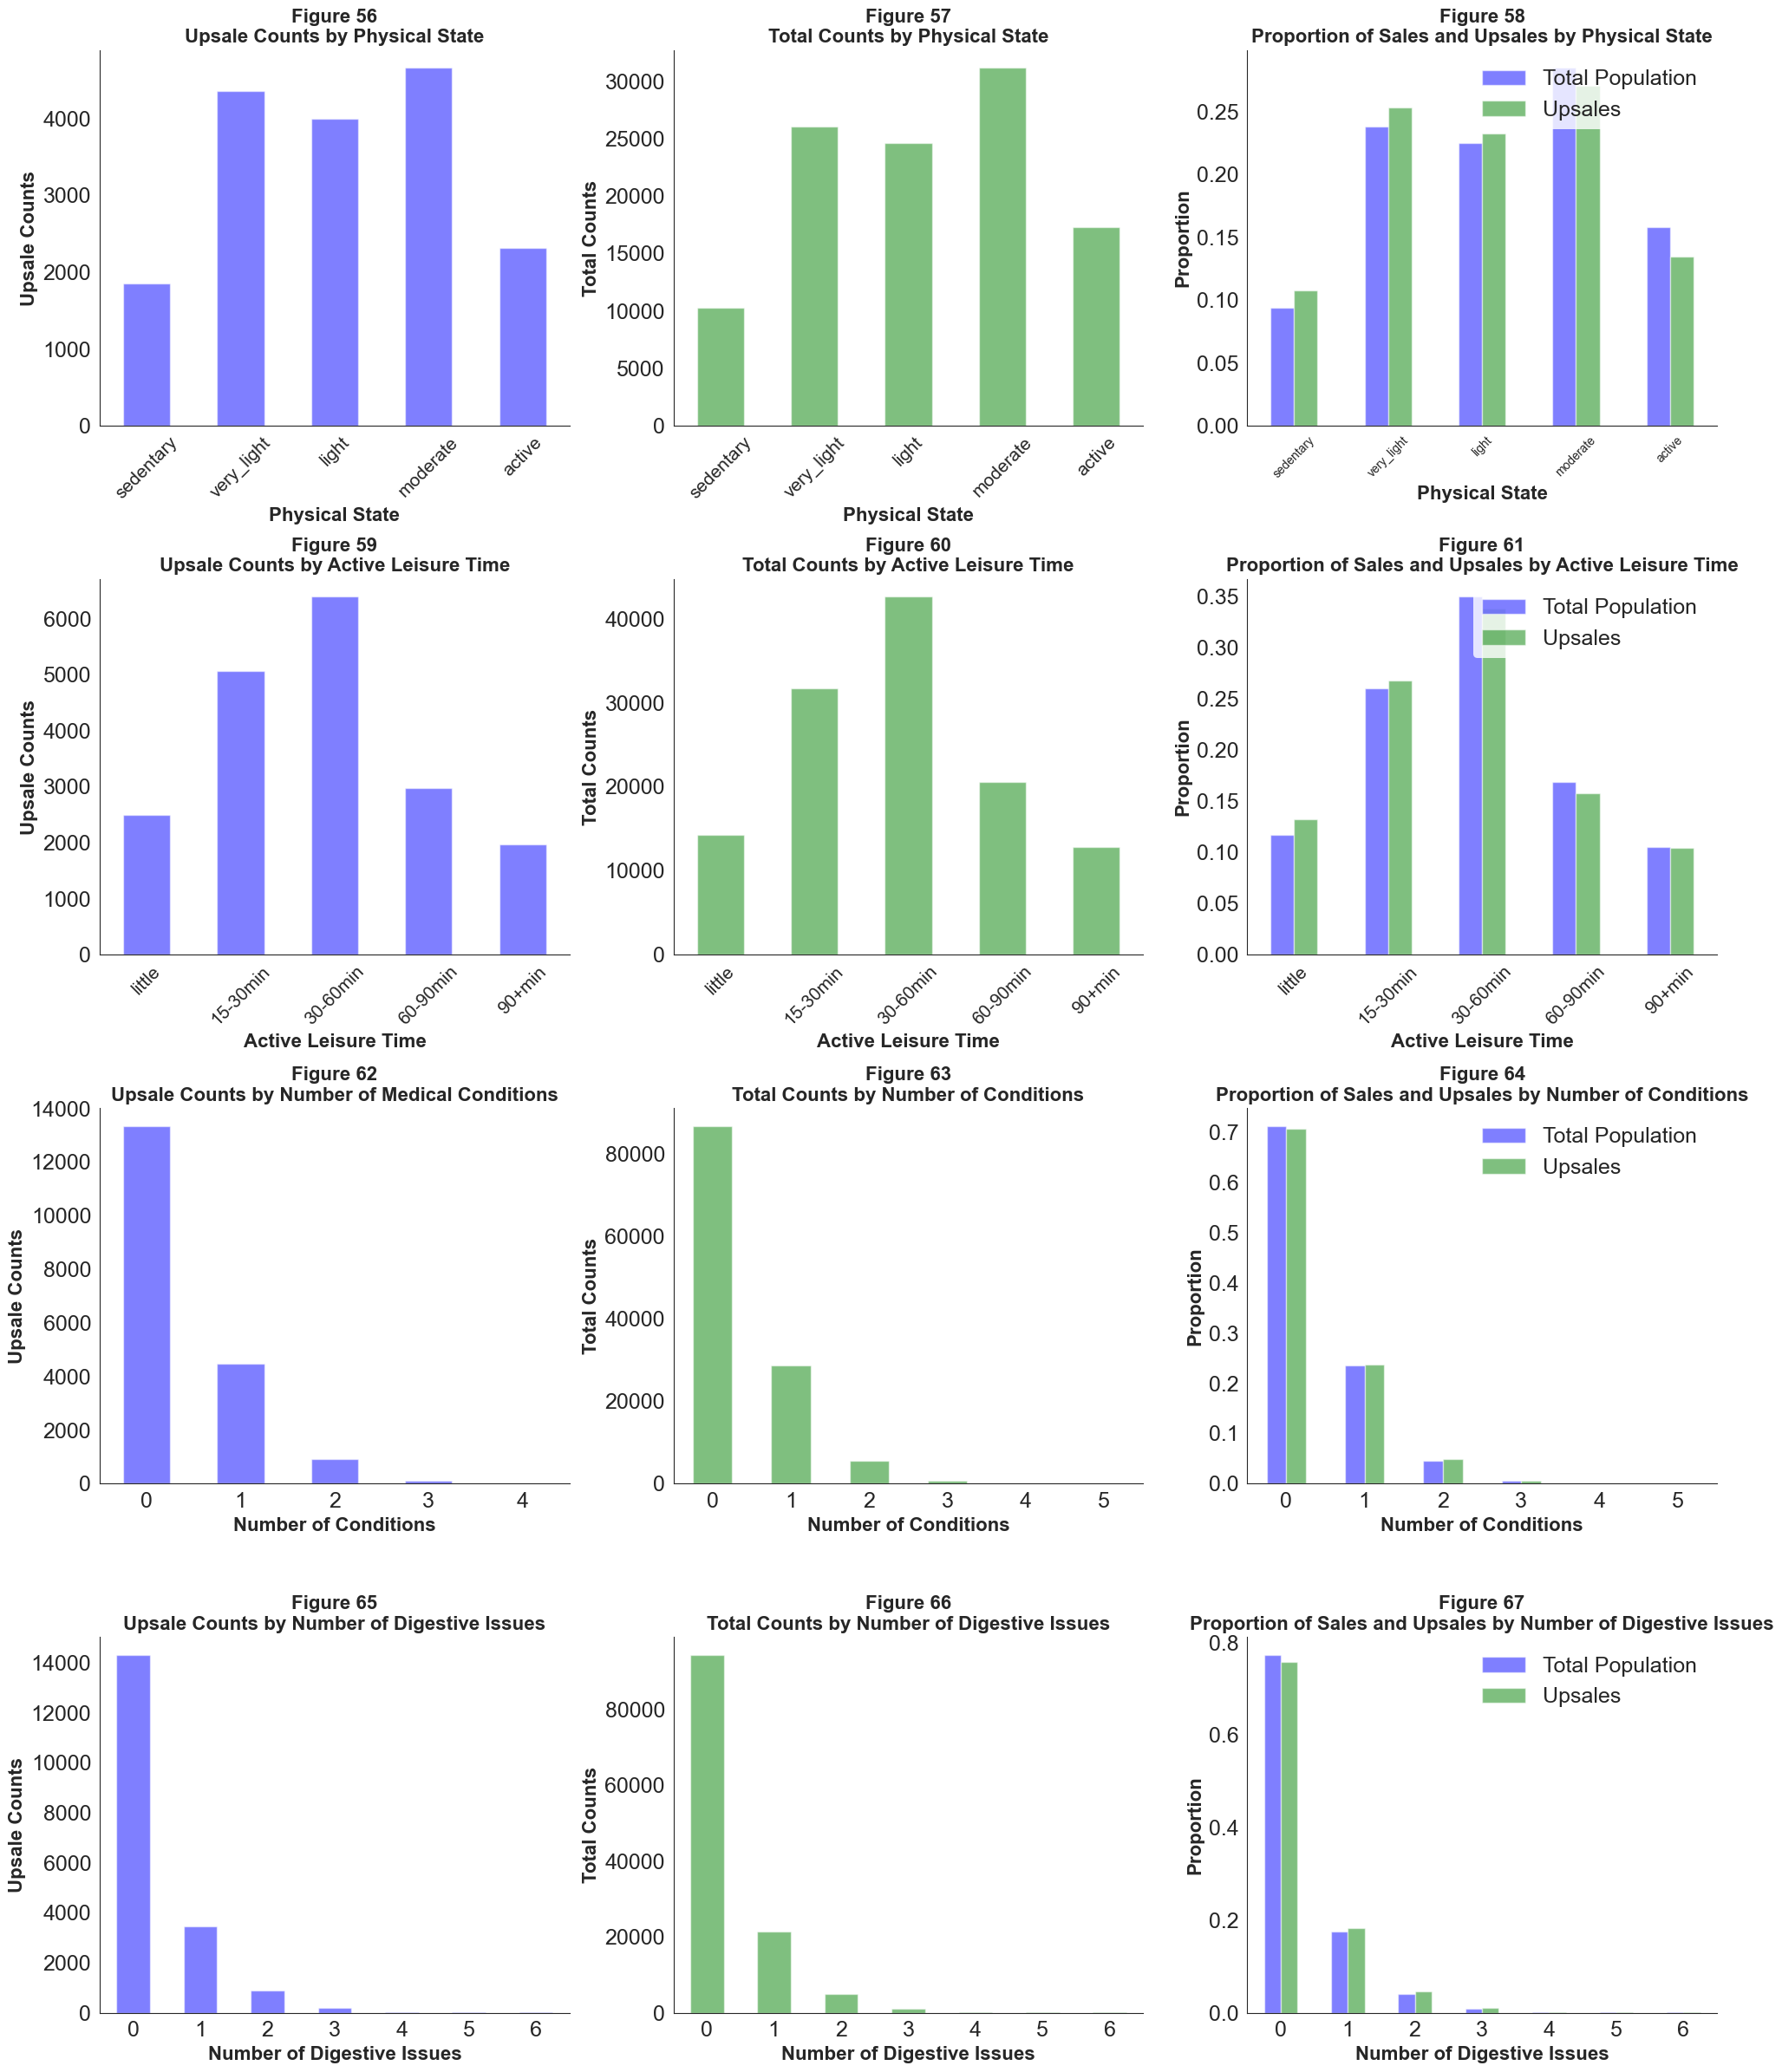

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("white")

fig, axs = plt.subplots(4, 3, figsize=(20, 24))
axs = axs.flatten()


categories_of_interest = ['sedentary', 'very_light', 'light', 'moderate', 'active']
buyers['quiz_physically_active'] = pd.Categorical(buyers['quiz_physically_active'], categories=categories_of_interest, ordered=True)

upsale_counts = buyers[buyers['is_upsell'] == 'Yes'].groupby('quiz_physically_active').size().reindex(categories_of_interest)
upsale_counts.plot(kind='bar', ax=axs[0], color='blue', alpha=0.5)
axs[0].set_title('Figure 56\nUpsale Counts by Physical State', fontweight='bold', fontsize=16)
axs[0].set_xlabel('Physical State', fontsize=16, fontweight='bold')
axs[0].set_ylabel('Upsale Counts', fontsize=16, fontweight='bold')
axs[0].set_xticklabels(upsale_counts.index, rotation=45)

total_counts = buyers.groupby('quiz_physically_active').size().reindex(categories_of_interest)
total_counts.plot(kind='bar', ax=axs[1], color='green', alpha=0.5)
axs[1].set_title('Figure 57\nTotal Counts by Physical State', fontweight='bold', fontsize=16)
axs[1].set_xlabel('Physical State', fontsize=16, fontweight='bold')
axs[1].set_ylabel('Total Counts', fontsize=16, fontweight='bold')
axs[1].set_xticklabels(total_counts.index, rotation=45)

total_population_counts = buyers['quiz_physically_active'].value_counts(normalize=True).reindex(categories_of_interest)
upsale_population_counts = buyers[buyers['is_upsell'] == 'Yes']['quiz_physically_active'].value_counts(normalize=True).reindex(categories_of_interest)
com_df = pd.DataFrame({'Total Population': total_population_counts, 'Upsales': upsale_population_counts})
com_df.plot(kind='bar', ax=axs[2], color=['blue', 'green'], alpha=0.5)
axs[2].set_title('Figure 58\nProportion of Sales and Upsales by Physical State', fontweight='bold', fontsize=16)
axs[2].set_xlabel('Physical State', fontsize=16, fontweight='bold')
axs[2].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[2].set_xticklabels(com_df.index, rotation=45)


categories_of_interest = ['little', '15-30min', '30-60min', '60-90min', '90+min']
buyers['quiz_leisure'] = pd.Categorical(buyers['quiz_leisure'], categories=categories_of_interest, ordered=True)

upsale_counts = buyers[buyers['is_upsell'] == 'Yes'].groupby('quiz_leisure').size()
upsale_counts.plot(kind='bar', ax=axs[3], color='blue', alpha=0.5)
axs[3].set_title('Figure 59\nUpsale Counts by Active Leisure Time', fontweight='bold', fontsize=16)
axs[3].set_xlabel('Active Leisure Time', fontsize=16, fontweight='bold')
axs[3].set_ylabel('Upsale Counts', fontsize=16, fontweight='bold')
axs[3].set_xticklabels(categories_of_interest, rotation=45)

total_counts = buyers.groupby('quiz_leisure').size()
total_counts.plot(kind='bar', ax=axs[4], color='green', alpha=0.5)
axs[4].set_title('Figure 60\nTotal Counts by Active Leisure Time', fontweight='bold', fontsize=16)
axs[4].set_xlabel('Active Leisure Time', fontsize=16, fontweight='bold')
axs[4].set_ylabel('Total Counts', fontsize=16, fontweight='bold')
axs[4].set_xticklabels(categories_of_interest, rotation=45)

total_population_counts = buyers['quiz_leisure'].value_counts(normalize=True).reindex(categories_of_interest)
upsale_population_counts = buyers[buyers['is_upsell'] == 'Yes']['quiz_leisure'].value_counts(normalize=True).reindex(categories_of_interest)
com_df = pd.DataFrame({'Total Population': total_population_counts, 'Upsales': upsale_population_counts})
com_df.plot(kind='bar', ax=axs[5], color=['blue', 'green'], alpha=0.5)
axs[5].set_title('Figure 61\nProportion of Sales and Upsales by Active Leisure Time', fontweight='bold', fontsize=16)
axs[5].set_xlabel('Active Leisure Time', fontsize=16, fontweight='bold')
axs[5].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[5].set_xticklabels(categories_of_interest, rotation=45)
def calculate_medical_sum(row):
    medical = row['quiz_medical_conditions'].split(',')
    medical_count = sum(1 for condition in medical if condition not in ['none', ''])
    return medical_count

buyers['medical_count'] = buyers.apply(calculate_medical_sum, axis=1)

upsale_counts = buyers[buyers['is_upsell'] == 'Yes'].groupby('medical_count').size()
total_counts = buyers.groupby('medical_count').size()

upsale_counts.plot(kind='bar', ax=axs[6], color='blue', alpha=0.5)
axs[6].set_title('Figure 62\nUpsale Counts by Number of Medical Conditions', fontweight='bold', fontsize=16)
axs[6].set_xlabel('Number of Conditions', fontsize=16, fontweight='bold')
axs[6].set_ylabel('Upsale Counts', fontsize=16, fontweight='bold')
axs[6].set_xticks(range(len(upsale_counts)))
axs[6].set_xticklabels(upsale_counts.index, rotation=45)

total_counts.plot(kind='bar', ax=axs[7], color='green', alpha=0.5)
axs[7].set_title('Figure 63\nTotal Counts by Number of Conditions', fontweight='bold', fontsize=16)
axs[7].set_xlabel('Number of Conditions', fontsize=16, fontweight='bold')
axs[7].set_ylabel('Total Counts', fontsize=16, fontweight='bold')
axs[7].set_xticks(range(len(total_counts)))
axs[7].set_xticklabels(total_counts.index, rotation=45)

total_population_proportions = buyers['medical_count'].value_counts(normalize=True)
upsale_population_proportions = buyers[buyers['is_upsell'] == 'Yes']['medical_count'].value_counts(normalize=True)

comparison_df = pd.DataFrame({'Total Population': total_population_proportions, 'Upsales': upsale_population_proportions})

comparison_df.plot(kind='bar', ax=axs[8], color=['blue', 'green'], alpha=0.5)
axs[8].set_title('Figure 64\nProportion of Sales and Upsales by Number of Conditions', fontweight='bold', fontsize=16)
axs[8].set_xlabel('Number of Conditions', fontsize=16, fontweight='bold')
axs[8].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[8].set_xticklabels(comparison_df.index, rotation=45)

def calculate_digestive_count(row):
    digestive = row['quiz_digestive'].split(',')
    digestive_count = sum(1 for issue in digestive if issue not in ['none', '']) 
    return digestive_count

buyers['digestive_count'] = buyers.apply(calculate_digestive_count, axis=1)

upsale_counts = buyers[buyers['is_upsell'] == 'Yes'].groupby('digestive_count').size()
total_counts = buyers.groupby('digestive_count').size()

upsale_counts.plot(kind='bar', ax=axs[9], color='blue', alpha=0.5)
axs[9].set_title('Figure 65\nUpsale Counts by Number of Digestive Issues', fontweight='bold', fontsize=16)
axs[9].set_xlabel('Number of Digestive Issues', fontsize=16, fontweight='bold')
axs[9].set_ylabel('Upsale Counts', fontsize=16, fontweight='bold')
axs[9].set_xticks(range(len(upsale_counts)))
axs[9].set_xticklabels(upsale_counts.index, rotation=45)

total_counts.plot(kind='bar', ax=axs[10], color='green', alpha=0.5)
axs[10].set_title('Figure 66\nTotal Counts by Number of Digestive Issues', fontweight='bold', fontsize=16)
axs[10].set_xlabel('Number of Digestive Issues', fontsize=16, fontweight='bold')
axs[10].set_ylabel('Total Counts', fontsize=16, fontweight='bold')
axs[10].set_xticks(range(len(total_counts)))
axs[10].set_xticklabels(total_counts.index, rotation=45)

total_population_proportions = buyers['digestive_count'].value_counts(normalize=True)
upsale_population_proportions = buyers[buyers['is_upsell'] == 'Yes']['digestive_count'].value_counts(normalize=True)
comparison_df = pd.DataFrame({'Total Population': total_population_proportions, 'Upsales': upsale_population_proportions})
comparison_df.plot(kind='bar', ax=axs[11], color=['blue', 'green'], alpha=0.5)
axs[11].set_title('Figure 67\nProportion of Sales and Upsales by Number of Digestive Issues', fontweight='bold', fontsize=16)
axs[11].set_xlabel('Number of Digestive Issues', fontsize=16, fontweight='bold')
axs[11].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[11].set_xticklabels(comparison_df.index, rotation=45)

legend = axs[2].legend(fontsize=18)
legend.get_frame().set_linewidth(0)
legend = axs[5].legend(fontsize=18)
legend.get_frame().set_linewidth(0)
legend = axs[8].legend(fontsize=18)
legend.get_frame().set_linewidth(0)
legend = axs[11].legend(fontsize=18)
legend.get_frame().set_linewidth(0)


for ax in axs:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

for plot in range(0, 12):
    axs[plot].tick_params(axis='both', which='major', labelsize=18, rotation=0)
    axs[plot].spines['top'].set_visible(False)
    axs[plot].spines['right'].set_visible(False)

for plot in range(0, 6):
    axs[plot].tick_params(axis='x', rotation=45, labelsize=15)

axs[2].tick_params(axis='x', rotation=45, labelsize=10)

plt.tight_layout()
plt.show()


### In the first row, we observe that people who only exercise lightly, very lightly, lead a sedentary lifestyle, or are generally inactive are overrepresented in the upsells population, and those with more active lifestyles are underrepresented when compared with the broader population.

### Next, we see that people who spend little or between 15-30 minutes of active leisure time are represented at a higher proportion, and those with more time spent actively resting are at a lower proportion when compared to the overall population.

### Interestingly, there is almost no difference between the distributions of the number of medical conditions. Perhaps upsells are only accounted for by severity rather than count.

### We also observe that people with more digestive issues are slightly overrepresented in the upsells population. It could be that digestive issues overall negatively affect people on average more than medical conditions. However, the differences in distribution are slight.

### To sum up, it is clear that people with bad health states, a higher number of symptoms, who do not work out enough, and generally enjoy a more sedentary lifestyle could be more susceptible to upsell strategies since they are overrepresented when comparing the distributions of upsell orders and the overall sales population.

### Seeing that people with a larger number of symptoms are overrepresented in the upsells category, it might be interesting to take a closer look. We construct a plot that shows which symptoms and by how much (percentage-wise) are overrepresented in the upsells distribution when compared to the general buyer population.

In [66]:
all_symptoms = buyers['quiz_symptoms'].str.split(', ') + buyers['quiz_symptoms_two'].str.split(', ')

all_symptoms_flat = [symptom for sublist in all_symptoms for symptom in sublist]

general_occurrence = Counter(all_symptoms_flat)

upsell_symptoms = buyers[buyers['is_upsell'] == 'Yes']
upsell_all_symptoms = upsell_symptoms['quiz_symptoms'].str.split(', ') + upsell_symptoms['quiz_symptoms_two'].str.split(', ')
upsell_all_symptoms_flat = [symptom for sublist in upsell_all_symptoms for symptom in sublist]

upsale_occurrence = Counter(upsell_all_symptoms_flat)

stats_list = []

for symptom, count in upsale_occurrence.items():
    difference = (count/len(upsell_all_symptoms_flat) - general_occurrence[symptom]/len(all_symptoms_flat))/(general_occurrence[symptom]/len(all_symptoms_flat))
    stats_list.append({'name': symptom, 'difference': round(difference, 3)})
stats_df = pd.DataFrame(stats_list)

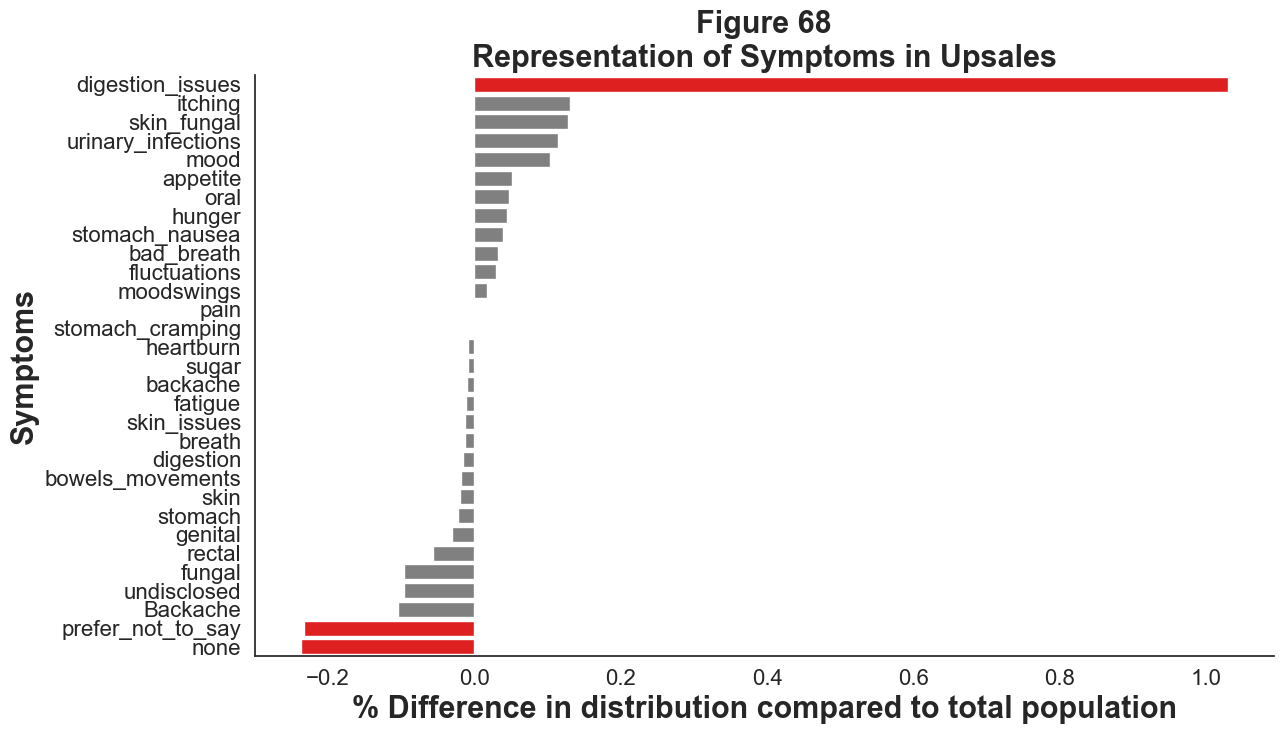

In [67]:


stats_df = stats_df.sort_values(by='difference', ascending=False)
colors = ['red' if x > 0.2 or x < -0.2 else 'grey' for x in stats_df['difference']]


plt.figure(figsize=(13, 7.5))
sns.set_theme(style="white")

sns.barplot(x='difference', y='name', data=stats_df, palette=colors)

plt.title('Figure 68\nRepresentation of Symptoms in Upsales', fontweight='bold', fontsize=22)
plt.xlabel('% Difference in distribution compared to total population', fontweight='bold', fontsize=22)
plt.ylabel('Symptoms', fontweight='bold', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=16)
sns.despine(right=True, top=True)
plt.tight_layout()
plt.show()


### The plot reveals some interesting results. While the differences are minor (up to slightly over one percent difference in proportion), we can see that compared to other symptoms, issues with digestion are the most overrepresented (approximately 1% higher) in the upsells distribution, and preference to not disclose the symptoms or having none of them are the most underrepresented (0.2% lower proportion compared to all buyer populations).

### While we cannot pinpoint any more specific symptoms since their distributions seem to be somewhat random, it might be the case that those with digestive issues are more likely to succumb to upsell strategies and those who do not state their symptoms or have none are less likely. Once again, it seems like more disadvantaged people are more likely to buy items that were recommended as an upsell.

### Moving on, to check how upsell strategy depends on the initial order, we compare relevant statistics between the initial orders of people who also purchased an item on upsell as well as orders of those who did not.

In [68]:
upsale_initial = buyers[(buyers['upsell_id'] == 'upsale') & (buyers['is_upsell'] == 'No')]
upsale_initial.head()

,client_id,flavour,sub_project,item_category,quantity,is_subscription,is_upsell,is_supplement,order_id,item_amount_in_usd,country,gender,age,starting_bmi,starting_weight_in_kg,target_weight_in_kg,quiz_health_state,quiz_linked_to,quiz_poop,quiz_symptoms,quiz_symptoms_two,quiz_allergies,quiz_medical_conditions,quiz_digestive,quiz_physically_active,quiz_leisure,quiz_pregnant,quiz_breastfeeding,lead_id,pregnant,buyers,symptom_count,allergy_count,medical_count,digestive_count,upsell_id
10,11.0,Strawberry,Original,Colonbroom 6 Month Subscription,6.0,Yes,No,Yes,2749441.0,143.93,United States,male,53.0,35.400046,122.47,106.59,worse,"bloating, weight_gain",everyday,"moodswings, sugar, skin",pain,gluten,none,none,NaN,30-60min,undisclosed,no,NaN,no,Buyers,4,1,0,0,upsale
12,12.0,Tropical,Original,Colonbroom 1 Month OTP,1.0,No,No,Yes,2416526.0,69.99,United States,male,28.0,49.391847,120.20,95.25,good,"bloating, weight_gain",everyday,"Backache, sugar, skin",none,none,none,none,NaN,30-60min,undisclosed,no,NaN,no,Buyers,3,0,0,0,upsale
16,15.0,Tropical,Original,Colonbroom 3 Month Subscription,3.0,Yes,No,Yes,2624600.0,131.96,United States,male,46.0,36.062435,86.64,80.29,good,"diarrhea, weight_gain",everyday,"breath, skin, sugar, rectal","digestion, skin",none,none,none,NaN,30-60min,undisclosed,no,NaN,no,Buyers,6,0,0,0,upsale
29,26.0,Tropical,Original,Colonbroom 3 Month OTP,3.0,No,No,Yes,2404110.0,137.97,United States,male,47.0,40.179012,130.18,99.79,average,"bloating, weight_gain",everyday,"sugar, Backache, rectal","appetite, pain",seafood,"cholesterol, thyroid",none,NaN,60-90min,undisclosed,no,NaN,no,Buyers,5,1,2,0,upsale
42,36.0,Premium,Premium,Colonbroom 1 Month OTP,1.0,No,No,Yes,2486068.0,84.99,United States,female,38.0,27.146814,79.38,72.57,good,"constipation, weight_gain",less,"moodswings, sugar, skin, Backache, stomach","genital, digestion, skin, appetite, mood",none,none,IBS,NaN,30-60min,no,no,NaN,NaN,Buyers,10,0,0,1,upsale


In [69]:
non_upsale_clients.head()

,client_id,flavour,sub_project,item_category,quantity,is_subscription,is_upsell,is_supplement,order_id,item_amount_in_usd,country,gender,age,starting_bmi,starting_weight_in_kg,target_weight_in_kg,quiz_health_state,quiz_linked_to,quiz_poop,quiz_symptoms,quiz_symptoms_two,quiz_allergies,quiz_medical_conditions,quiz_digestive,quiz_physically_active,quiz_leisure,quiz_pregnant,quiz_breastfeeding,lead_id,pregnant,buyers,symptom_count,allergy_count,medical_count,digestive_count
0,1.0,Strawberry,Original,Colonbroom 3 Month OTP,3.0,No,No,Yes,2551370.0,137.97,United States,male,33.0,25.055989,83.91,77.11,undisclosed,undisclosed,everyday,"mood, sugar, digestion, pain",undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,no,NaN,no,Buyers,5,1,1,1
1,2.0,Strawberry,Original,Colonbroom 6 Month Subscription,6.0,Yes,No,Yes,2447652.0,167.96,United States,female,37.0,22.821003,64.41,58.97,great,bloating,everyday,"stomach, sugar, rectal","digestion, sugar, rectal",lactose,none,none,often,30-60min,no,no,NaN,NaN,Buyers,6,1,0,0
3,4.0,Strawberry,Original,Colonbroom 1 Month OTP,1.0,No,No,Yes,2457912.0,69.99,United States,male,38.0,29.681764,92.99,83.91,undisclosed,undisclosed,everyday,"fungal, sugar",undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,no,NaN,no,Buyers,3,1,1,1
4,5.0,Strawberry,Original,Colonbroom 3 Month Subscription,3.0,Yes,No,Yes,2585188.0,131.97,United States,male,57.0,26.878830,92.99,83.91,good,bloating,twice,none,none,none,none,none,sometimes,30-60min,undisclosed,no,NaN,no,Buyers,0,0,0,0
5,6.0,Strawberry,Original,Colonbroom 1 Month OTP,1.0,No,No,Yes,2647956.0,69.99,United States,female,57.0,31.253004,78.02,63.50,poor,"constipation, weight_gain, bloating",twice,"sugar, heartburn, skin","digestion, pain, skin",citrus,cholesterol,"GERD, IBS",never,30-60min,no,no,NaN,NaN,Buyers,6,1,1,2


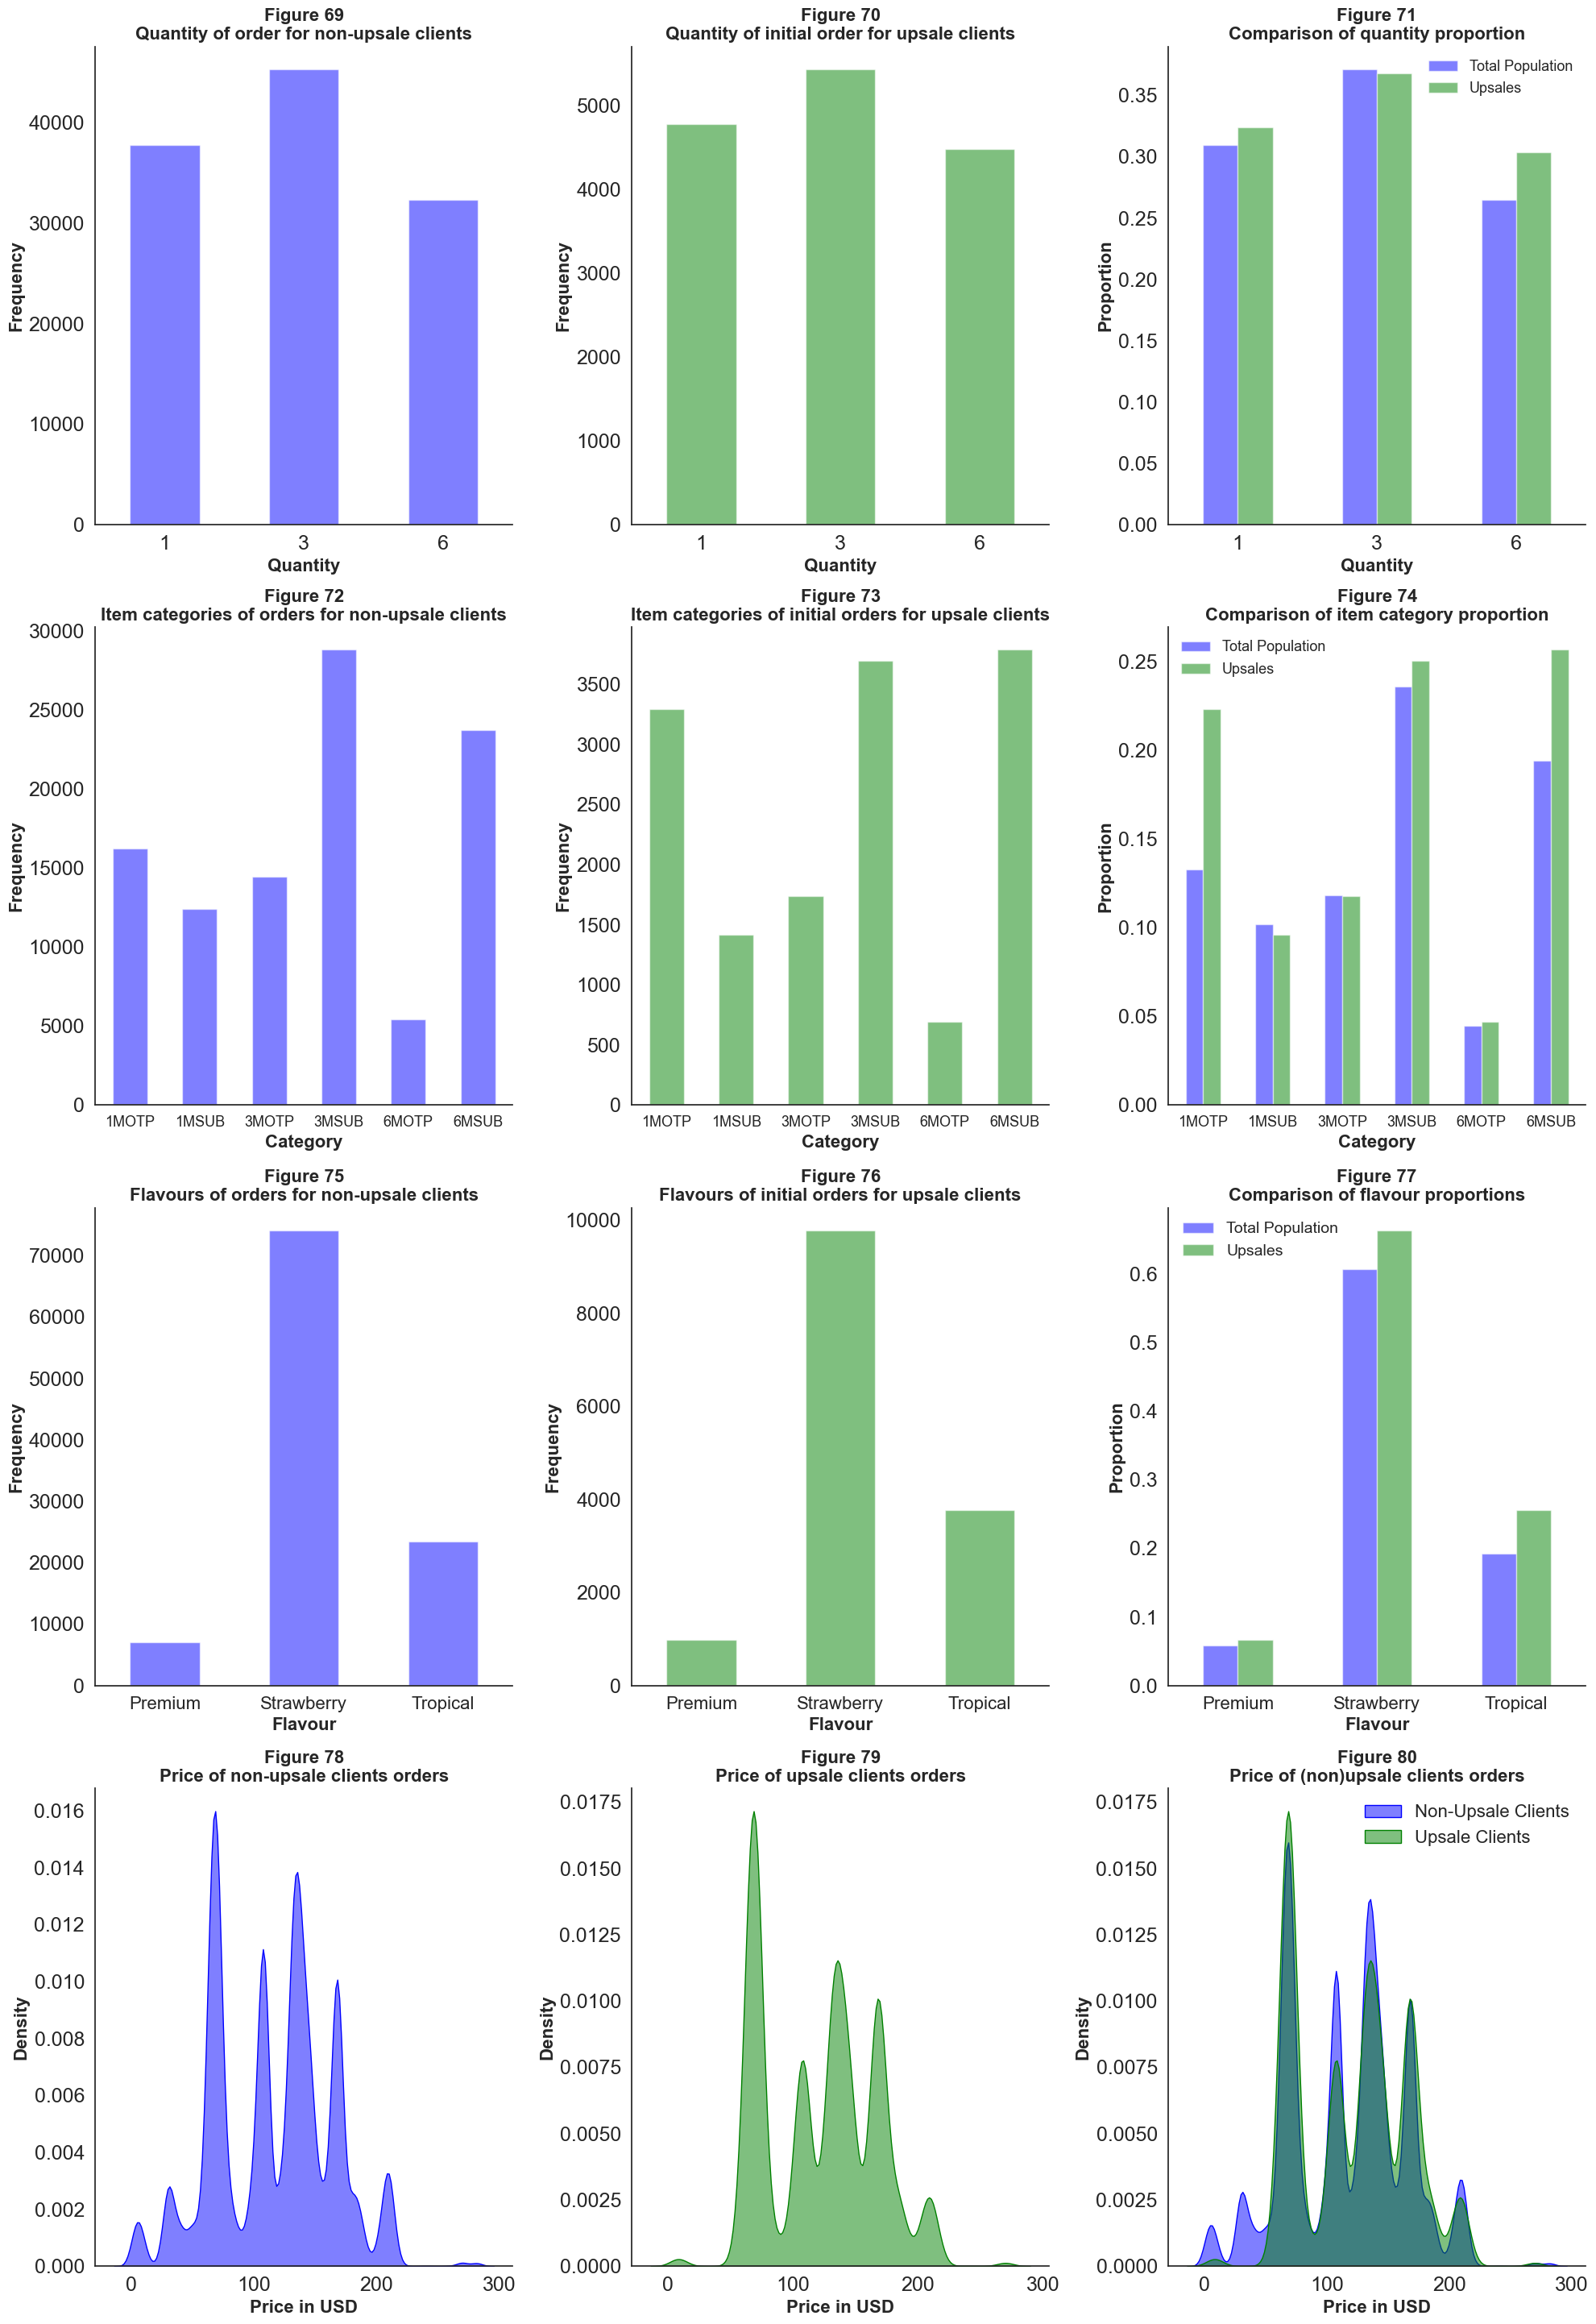

In [70]:

sns.set_style("white")

fig, axs = plt.subplots(4, 3, figsize=(20, 29))
axs = axs.flatten()

quantities_of_interest = [1, 3, 6]

non_ups_quantity = non_upsale_clients.groupby('quantity').size().reindex(quantities_of_interest)
non_ups_quantity.plot(kind='bar', ax=axs[0], color='blue', alpha=0.5)
axs[0].set_title('Figure 69\nQuantity of order for non-upsale clients', fontweight='bold', fontsize=16)
axs[0].set_xlabel('Quantity', fontsize=16, fontweight='bold')
axs[0].set_ylabel('Frequency', fontsize=16, fontweight='bold')
axs[0].set_xticklabels(quantities_of_interest, rotation=45)

ups_quantity = upsale_initial.groupby('quantity').size().reindex(quantities_of_interest)
ups_quantity.plot(kind='bar', ax=axs[1], color='green', alpha=0.5)
axs[1].set_title('Figure 70\nQuantity of initial order for upsale clients', fontweight='bold', fontsize=16)
axs[1].set_xlabel('Quantity', fontsize=16, fontweight='bold')
axs[1].set_ylabel('Frequency', fontsize=16, fontweight='bold')
axs[1].set_xticklabels(quantities_of_interest, rotation=45)

total_population_counts = non_upsale_clients['quantity'].value_counts(normalize=True).reindex(quantities_of_interest)
upsale_population_counts = upsale_initial['quantity'].value_counts(normalize=True).reindex(quantities_of_interest)
com_df = pd.DataFrame({'Total Population': total_population_counts, 'Upsales': upsale_population_counts})

com_df.plot(kind='bar', ax=axs[2], color=['blue', 'green'], alpha=0.5)
axs[2].set_title('Figure 71\nComparison of quantity proportion', fontweight='bold', fontsize=16)
axs[2].set_xlabel('Quantity', fontsize=16, fontweight='bold')
axs[2].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[2].set_xticklabels(quantities_of_interest, rotation=45)
legend = axs[2].legend(fontsize=13)
legend.get_frame().set_linewidth(0)

categories_of_interest = ['Colonbroom 1 Month OTP', 'Colonbroom 1 Month Subscription', 'Colonbroom 3 Month OTP', 'Colonbroom 3 Month Subscription', 'Colonbroom 6 Month OTP', 'Colonbroom 6 Month Subscription']

non_ups_category = non_upsale_clients.groupby('item_category').size().reindex(categories_of_interest)
non_ups_category.plot(kind='bar', ax=axs[3], color='blue', alpha=0.5)
axs[3].set_title('Figure 72\nItem categories of orders for non-upsale clients', fontweight='bold', fontsize=16)
axs[3].set_xlabel('Category', fontsize=16, fontweight='bold')
axs[3].set_ylabel('Frequency', fontsize=16, fontweight='bold')
axs[3].set_xticklabels(['1MOTP', '1MSUB', '3MOTP', '3MSUB', '6MOTP', '6MSUB'], rotation=0)

ups_category = upsale_initial.groupby('item_category').size().reindex(categories_of_interest)
ups_category.plot(kind='bar', ax=axs[4], color='green', alpha=0.5)
axs[4].set_title('Figure 73\nItem categories of initial orders for upsale clients', fontweight='bold', fontsize=16)
axs[4].set_xlabel('Category', fontsize=16, fontweight='bold')
axs[4].set_ylabel('Frequency', fontsize=16, fontweight='bold')
axs[4].set_xticklabels(['1MOTP', '1MSUB', '3MOTP', '3MSUB', '6MOTP', '6MSUB'], rotation=0)

total_population_counts = non_upsale_clients['item_category'].value_counts(normalize=True).reindex(categories_of_interest)
upsale_population_counts = upsale_initial['item_category'].value_counts(normalize=True).reindex(categories_of_interest)
com_df = pd.DataFrame({'Total Population': total_population_counts, 'Upsales': upsale_population_counts})


com_df.plot(kind='bar', ax=axs[5], color=['blue', 'green'], alpha=0.5)
axs[5].set_title('Figure 74\nComparison of item category proportion', fontweight='bold', fontsize=16)
axs[5].set_xlabel('Category', fontsize=16, fontweight='bold')
axs[5].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[5].set_xticklabels(['1MOTP', '1MSUB', '3MOTP', '3MSUB', '6MOTP', '6MSUB'], rotation=0)
legend = axs[5].legend(fontsize=13)
legend.get_frame().set_linewidth(0)

categories_of_interest = ['Premium', 'Strawberry', 'Tropical']

non_ups_flav = non_upsale_clients.groupby('flavour').size().reindex(categories_of_interest)
non_ups_flav.plot(kind='bar', ax=axs[6], color='blue', alpha=0.5)
axs[6].set_title('Figure 75\nFlavours of orders for non-upsale clients', fontweight='bold', fontsize=16)
axs[6].set_xlabel('Flavour', fontsize=16, fontweight='bold')
axs[6].set_ylabel('Frequency', fontsize=16, fontweight='bold')
axs[6].set_xticklabels(non_ups_flav.index, rotation=45)

ups_flav = upsale_initial.groupby('flavour').size().reindex(categories_of_interest)
ups_flav.plot(kind='bar', ax=axs[7], color='green', alpha=0.5)
axs[7].set_title('Figure 76\nFlavours of initial orders for upsale clients', fontweight='bold', fontsize=16)
axs[7].set_xlabel('Flavour', fontsize=16, fontweight='bold')
axs[7].set_ylabel('Frequency', fontsize=16, fontweight='bold')
axs[7].set_xticklabels(ups_flav.index, rotation=45)

total_population_counts = non_upsale_clients['flavour'].value_counts(normalize=True).reindex(categories_of_interest)
upsale_population_counts = upsale_initial['flavour'].value_counts(normalize=True).reindex(categories_of_interest)
com_df = pd.DataFrame({'Total Population': total_population_counts, 'Upsales': upsale_population_counts})
com_df.plot(kind='bar', ax=axs[8], color=['blue', 'green'], alpha=0.5)
axs[8].set_title('Figure 77\nComparison of flavour proportions', fontweight='bold', fontsize=16)
axs[8].set_xlabel('Flavour', fontsize=16, fontweight='bold')
axs[8].set_ylabel('Proportion', fontsize=16, fontweight='bold')
axs[8].set_xticklabels(com_df.index, rotation=45)
legend = axs[8].legend(fontsize=14)
legend.get_frame().set_linewidth(0)

sns.kdeplot(x=non_upsale_clients['item_amount_in_usd'], fill=True, color='blue', alpha=0.5, ax=axs[9], label='Non-Upsale Clients')
axs[9].set_title('Figure 78\nPrice of non-upsale clients orders', fontweight='bold', fontsize=16)
axs[9].set_xlabel('Price in USD', fontsize=16, fontweight='bold')
axs[9].set_ylabel('Density', fontsize=16, fontweight='bold')

sns.kdeplot(x=upsale_initial['item_amount_in_usd'], fill=True, color='green', alpha=0.5, ax=axs[10], label='Upsale Clients')
axs[10].set_title('Figure 79\nPrice of upsale clients orders', fontweight='bold', fontsize=16)
axs[10].set_xlabel('Price in USD', fontsize=16, fontweight='bold')
axs[10].set_ylabel('Density', fontsize=16, fontweight='bold')

sns.kdeplot(x=non_upsale_clients['item_amount_in_usd'], fill=True, color='blue', alpha=0.5, ax=axs[11], label='Non-Upsale Clients')
sns.kdeplot(x=upsale_initial['item_amount_in_usd'], fill=True, color='green', alpha=0.5, ax=axs[11], label='Upsale Clients')
axs[11].set_title('Figure 80\nPrice of (non)upsale clients orders', fontweight='bold', fontsize=16)
axs[11].set_xlabel('Price in USD', fontsize=16, fontweight='bold')
axs[11].set_ylabel('Density', fontsize=16, fontweight='bold')
legend = axs[11].legend(fontsize=16)
legend.get_frame().set_linewidth(0)

for ax in axs:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

for plot in range(0, 12):
    axs[plot].tick_params(axis='both', which='major', labelsize=18, rotation=0)
    axs[plot].spines['top'].set_visible(False)
    axs[plot].spines['right'].set_visible(False)

for plot in range(3, 6):
    axs[plot].tick_params(axis='x', rotation=0, labelsize=13)
for plot in range(6, 9):
    axs[plot].tick_params(axis='x', rotation=0, labelsize=16)

plt.tight_layout()
plt.show()

### In the first row, we can see that a person is possibly more likely, when compared to the overall buyer population, to purchase an item as an upsell if 1 or 6 bottles are bought in the initial order.

### In the second row, we observe that a person is possibly more likely to succumb to an upsell strategy if they buy an item(s) as a 1-month and 2-month one-time purchase and a 6-month subscription.

### Next, we observe a higher likelihood of a person buying something as an upsell product if the initial order item(s) were flavored (general tendency for all flavors).

### When comparing price distributions, we see only one particular instance of a person being more likely to buy an upsell item: when the price paid is close to about 70 USD. We also see more filled-in gaps (parts between the peaks) for the upsells' initial purchases population. This could perhaps be due to some discounts offered.

## Finally, we can answer the question of what key characteristics differentiate customers who respond positively to upsell strategies from those who do not, and how does the success of an upsell strategy depend on the customer’s initial purchase?

### Key differing characteristics in people who respond positively to upsell strategies, within the scope of this research, are: BMI and weight, health state, number of symptoms and possibly their severity, as well as how active a person is. Additionally, customers might respond more positively to upsell strategies if they initially order 1, 3, or 6 items, if they order it as a 1-month, 2-month one-time purchase, or 6-month subscription, if their items are flavored, as well as if their offer was not too expensive and possibly whether any discounts were given.

# Design a predictive model which identifies the most promising upsell oportunity of each customer based on their unique characteristics. Authors of this research will build two models, one trying to predict whether a customer will buy the product or not and the second model seeks to predict whether there will be upsales

## This is the first subchapter where the predictive model is seeking to determine what characteristics result in consumer buying the product

We start of by creating a categorical variable containing whether the product has been bought or not, there is still some class imbalance but not major one

In [70]:
df['lead_id'].count()

98781

In [71]:
df['client_id'].count()

122100

Dropping duplicated client id observations

In [72]:
df['client_id'].nunique()

102619

In [73]:
df['Bought'] = np.where(df['client_id'].notna() & df['lead_id'].isna(), 'Yes', 'No')
df['Bought'].value_counts()

Bought
Yes    122100
No      98781
Name: count, dtype: int64

In [74]:
df_nan_client_ids = df[df['client_id'].isna()]
df_non_nan_deduplicated = df.dropna(subset=['client_id']).drop_duplicates(subset='client_id', keep='first')
df_final = pd.concat([df_non_nan_deduplicated, df_nan_client_ids])
df_final['Bought'].value_counts()

Bought
Yes    102619
No      98781
Name: count, dtype: int64

Choosing the variables from both datasets that match and are relevant

In [75]:
df_bought_columns = df2.columns.drop('lead_id')
df_bought_columns

Index(['country', 'gender', 'age', 'starting_bmi', 'starting_weight_in_kg',
       'target_weight_in_kg', 'quiz_health_state', 'quiz_linked_to',
       'quiz_poop', 'quiz_symptoms', 'quiz_symptoms_two', 'quiz_allergies',
       'quiz_medical_conditions', 'quiz_digestive', 'quiz_physically_active',
       'quiz_pregnant', 'quiz_breastfeeding', 'quiz_leisure'],
      dtype='object')

In [76]:
df_bought = df_final[list(df_bought_columns) + ['Bought']]

Checking for missing values

In [77]:
df_bought.isnull().any()

country                    False
gender                     False
age                        False
starting_bmi               False
starting_weight_in_kg      False
target_weight_in_kg        False
quiz_health_state          False
quiz_linked_to             False
quiz_poop                  False
quiz_symptoms              False
quiz_symptoms_two          False
quiz_allergies             False
quiz_medical_conditions    False
quiz_digestive             False
quiz_physically_active     False
quiz_pregnant              False
quiz_breastfeeding         False
quiz_leisure               False
Bought                     False
dtype: bool

Moving on to age column and trying to fix non-normality of the variable using log transformation

18.0 111.0


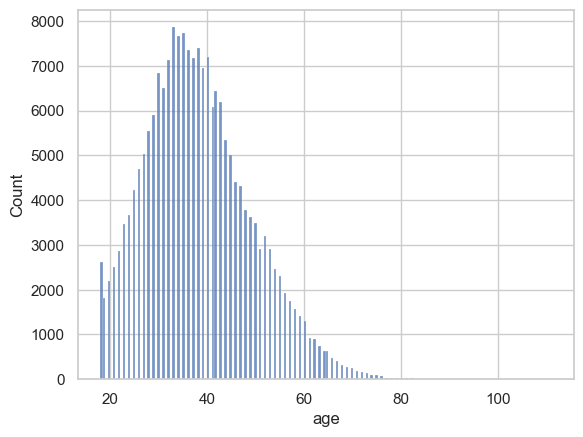

In [78]:
sns.histplot(df_bought['age'])
print(df_bought['age'].min(), df_bought['age'].max())

In [79]:
df_bought.loc[:, 'log_age'] = df_bought['age'].apply(np.log)

C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\587164376.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bought.loc[:, 'log_age'] = df_bought['age'].apply(np.log)


<Axes: xlabel='log_age', ylabel='Count'>

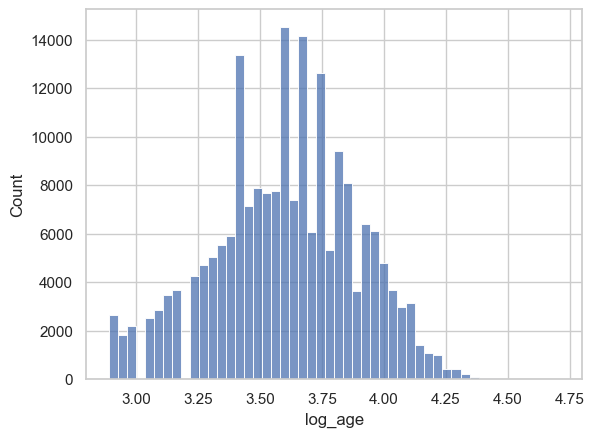

In [80]:
sns.histplot(df_bought['log_age'], bins = 50)

Next step is working with weight and bmi numeric variables

Creating a variable containing difference between current and target weight

In [81]:
df_bought.loc[:,'weight_diff'] = df_bought['starting_weight_in_kg'] - df_bought['target_weight_in_kg']

C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\2108964080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bought.loc[:,'weight_diff'] = df_bought['starting_weight_in_kg'] - df_bought['target_weight_in_kg']


<Axes: xlabel='weight_diff', ylabel='Count'>

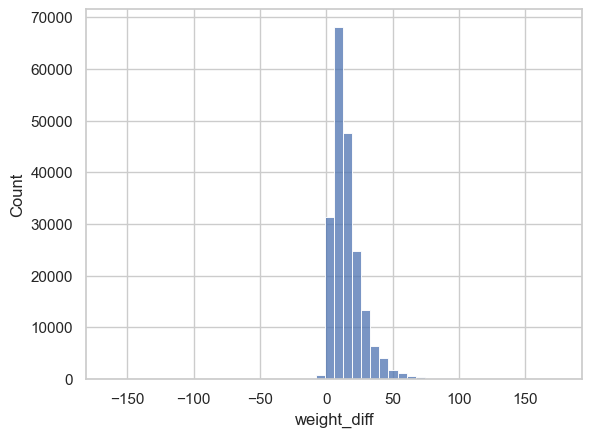

In [82]:
sns.histplot(df_bought['weight_diff'], bins = 50)

Taking a log of starting weight

In [83]:
df_bought.loc[:, 'log_start_weight'] = np.log(df_bought['starting_weight_in_kg'])

C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\3230736383.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bought.loc[:, 'log_start_weight'] = np.log(df_bought['starting_weight_in_kg'])


Next step is scaling the numeric variables that we have just created

In [84]:
scaler = StandardScaler()
df_bought['scaled_weight_diff'] = scaler.fit_transform(df_bought[['weight_diff']])
df_bought['scaled_log_age'] = scaler.fit_transform(df_bought[['log_age']])
df_bought['scaled_start_weight'] = scaler.fit_transform(df_bought[['log_start_weight']])

C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\2319802536.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bought['scaled_weight_diff'] = scaler.fit_transform(df_bought[['weight_diff']])
C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\2319802536.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bought['scaled_log_age'] = scaler.fit_transform(df_bought[['log_age']])
C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\2319802536.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy o

We continue our process with categorical variables, 'Bought', 'country' and 'gender' and dummify them

In [85]:
df_bought = pd.get_dummies(df_bought, columns=['Bought'], drop_first=True)
df_bought['Is_United_States'] = df_bought['country'].apply(lambda x: 1 if x == 'United States' else 0)
df_bought['Is_Male'] = df_bought['gender'].apply(lambda x: 1 if x == 'male' else 0)

To deal with quiz answers we decide to employ TF-IDF vectorizer for the answers of each customer

In [86]:
df_bought['Combined_Quiz'] = df_bought.apply(lambda row: ' '.join([row['quiz_linked_to'], row['quiz_poop'], row['quiz_symptoms'], row['quiz_symptoms_two'], row['quiz_allergies'],
 row['quiz_symptoms'], row['quiz_medical_conditions'],row['quiz_digestive'],row['quiz_physically_active'],row['quiz_pregnant'], row['quiz_breastfeeding']]), axis=1)

Transforming vectors so that we can use them in train test split

In [87]:
vectorizer = TfidfVectorizer()
tfidf_matrix =  vectorizer.fit_transform(df_bought['Combined_Quiz'])


In [88]:
numerical_features = df_bought[['scaled_start_weight', 'scaled_weight_diff', 'scaled_log_age']].values
sparse_numerical_features = csr_matrix(numerical_features)
tfidf_matrix_sampled = tfidf_matrix[df_bought.index]
X_bought = hstack([sparse_numerical_features, tfidf_matrix_sampled])
y_bought = df_bought['Bought_Yes']

In [89]:
X_train_bought, X_test_bought, y_train_bought, y_test_bought = train_test_split(X_bought, y_bought, test_size = 0.2, random_state = 42)

Creating a Benchmark function so that running classification models would be easier

In [90]:
def benchmark_bought(clf: BaseEstimator, custom_name: str = "") -> dict:
    model = clf
    clf_descr = custom_name if custom_name else clf.__class__.__name__

    logging.info(f"{'-'*80}\nTraining: {clf_descr}")

    try:
        t0 = time.time()
        model.fit(X_train_bought, y_train_bought)
        train_time = time.time() - t0

        t0 = time.time()
        pred_test = model.predict(X_test_bought)
        test_time = time.time() - t0
        
        t0 = time.time()
        pred_train = model.predict(X_train_bought)
        train_pred_time = time.time() - t0

        score_test = accuracy_score(y_test_bought, pred_test)
        f1_test = f1_score(y_test_bought, pred_test, average='binary')
        recall_test = recall_score(y_test_bought, pred_test, average='binary')
        precision_test = precision_score(y_test_bought, pred_test, average='binary')
        roc_auc_test = roc_auc_score(y_test_bought, pred_test)
        
        score_train = accuracy_score(y_train_bought, pred_train)
        f1_train = f1_score(y_train_bought, pred_train, average='binary')
        recall_train = recall_score(y_train_bought, pred_train, average='binary')
        precision_train = precision_score(y_train_bought, pred_train, average='binary')
        roc_auc_train = roc_auc_score(y_train_bought, pred_train)
        
        
        def plot_confusion_matrix(y_true, y_pred, title):
            matrix = confusion_matrix(y_true, y_pred)
            plt.figure(figsize=(5, 5))
            sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.title(title)
            plt.show()

        plot_confusion_matrix(y_test_bought, pred_test, f"Confusion Matrix (Test) - {clf_descr}")

        logging.info(f"Test Metrics:")
        logging.info(f"Train time: {train_time:.3f}s")
        logging.info(f"Test time:  {test_time:.3f}s")
        logging.info(f"Accuracy:   {score_test:.3f}")
        logging.info(f"F1 Score:   {f1_test:.3f}")
        logging.info(f"Recall:     {recall_test:.3f}")
        logging.info(f"Precision:  {precision_test:.3f}")
        logging.info(f"ROC AUC:    {roc_auc_test:.3f}\n")

        logging.info(f"Training Metrics (on training set):")
        logging.info(f"Prediction time: {train_pred_time:.3f}s")
        logging.info(f"Accuracy:   {score_train:.3f}")
        logging.info(f"F1 Score:   {f1_train:.3f}")
        logging.info(f"Recall:     {recall_train:.3f}")
        logging.info(f"Precision:  {precision_train:.3f}")
        logging.info(f"ROC AUC:    {roc_auc_train:.3f}\n")

    except Exception as e:
        logging.error(f"Error training {clf_descr}: {e}")
        return {
            'Classifier': clf_descr,
            'Error': str(e)
        }

    return {
        'Classifier': clf_descr,
        'Test Accuracy': score_test,
        'Test F1 Score': f1_test,
        'Test Recall': recall_test,
        'Test Precision': precision_test,
        'Test ROC AUC': roc_auc_test,
        'Train Time': train_time,
        'Test Time': test_time,
        'Train Accuracy': score_train,
        'Train F1 Score': f1_train,
        'Train Recall': recall_train,
        'Train Precision': precision_train,
        'Train ROC AUC': roc_auc_train,
        'Train Prediction Time': train_pred_time
    }


## Here we build predictive models using different classification algorithms. Fine-tuning is being done using Grid Search

Logistic Regression

In [91]:
logit_bought = LogisticRegression(random_state=42)
param_logit_bought = {
    'C': [0.001, 0.01, 0.1],
    'penalty': ['l1'],
    'solver': ['liblinear'],  
    'class_weight': ['balanced'],
    'max_iter': [100, 200]}
grid_search_logit_bought = GridSearchCV(estimator=logit_bought, param_grid=param_logit_bought, 
                           scoring='f1', n_jobs=-1, cv=5, verbose=3)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


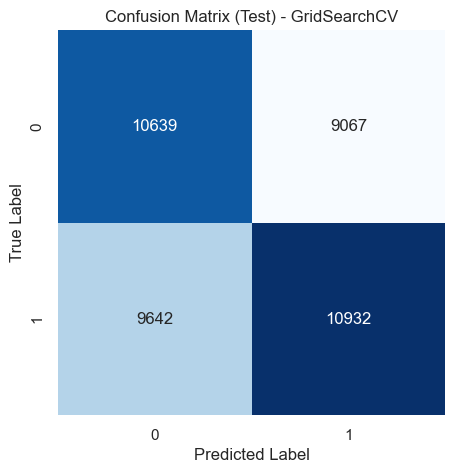

{'Classifier': 'GridSearchCV',
 'Test Accuracy': 0.5355263157894737,
 'Test F1 Score': 0.5388805363172553,
 'Test Recall': 0.531350247885681,
 'Test Precision': 0.5466273313665684,
 'Test ROC AUC': 0.5356182884612614,
 'Train Time': 21.59022045135498,
 'Test Time': 0.003209829330444336,
 'Train Accuracy': 0.5379034260178749,
 'Train F1 Score': 0.5398767698116939,
 'Train Recall': 0.532378572734475,
 'Train Precision': 0.5475891984053356,
 'Train ROC AUC': 0.5380071807712843,
 'Train Prediction Time': 0.006763935089111328}

In [92]:
benchmark_bought(grid_search_logit_bought)

In [93]:
best_logit_model_bought = grid_search_logit_bought.best_estimator_
best_logit_param_bought = grid_search_logit_bought.best_params_
best_logit_model_bought

LogisticRegression(C=0.1, class_weight='balanced', penalty='l1',
                   random_state=42, solver='liblinear')

KNN classifier

In [94]:
knn_bought = KNeighborsClassifier()
param_knn_bought = {
    'n_neighbors': [3, 5, 6]  
}
grid_search_knn_bought = GridSearchCV(estimator=knn_bought, param_grid=param_knn_bought, 
                           scoring='f1', n_jobs=-1, cv=5, verbose=3)

In [95]:
#benchmark_bought(knn_bought)

Random Forest classfier

In [96]:
R_forest_bought = RandomForestClassifier(random_state=42)
param_forest_bought = {
    'max_depth': [3, 6, 10], 
    'n_estimators': [100, 200]}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gridsearch_r_forest_bought = GridSearchCV(
    estimator=R_forest_bought,
    param_grid=param_forest_bought,
    scoring='f1',  
    n_jobs=-1,
    cv=cv_strategy,
    verbose=2
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


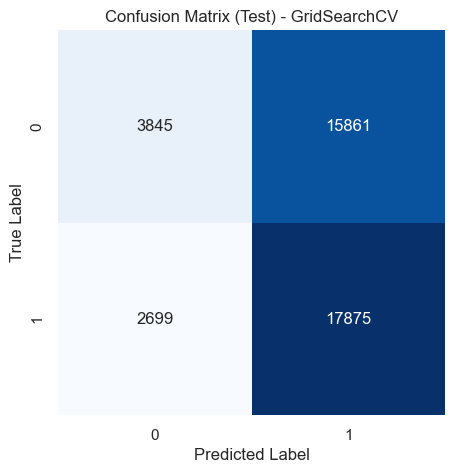

{'Classifier': 'GridSearchCV',
 'Test Accuracy': 0.5392254220456802,
 'Test F1 Score': 0.6582581476707788,
 'Test Recall': 0.8688150092349567,
 'Test Precision': 0.5298494190182594,
 'Test ROC AUC': 0.5319666236675138,
 'Train Time': 220.8256950378418,
 'Test Time': 0.16853904724121094,
 'Train Accuracy': 0.5430734856007945,
 'Train F1 Score': 0.6607967268404611,
 'Train Recall': 0.8740203546834054,
 'Train Precision': 0.5312053217574244,
 'Train ROC AUC': 0.5368584226784084,
 'Train Prediction Time': 0.7337312698364258}

In [97]:
benchmark_bought(gridsearch_r_forest_bought)

In [98]:
best_r_forest_bought = gridsearch_r_forest_bought.best_estimator_
best_r_forest_params_bought = gridsearch_r_forest_bought.best_params_
best_r_forest_params_bought

{'max_depth': 3, 'n_estimators': 100}

XGBoost classifier optimizing via GridSearch

In [154]:
boosting_bought = XGBClassifier()
param_boosting_bought = {
    'max_depth': [3, 6, 10], 
    'learning_rate': [0.01, 0.1], 
    'n_estimators': [100, 200]}
gridsearch_boosting_bought = GridSearchCV(boosting_bought, param_boosting_bought,scoring='f1', n_jobs=-1, cv=5, verbose=3)

XGBoost gridsearch on buying test results

Fitting 5 folds for each of 12 candidates, totalling 60 fits


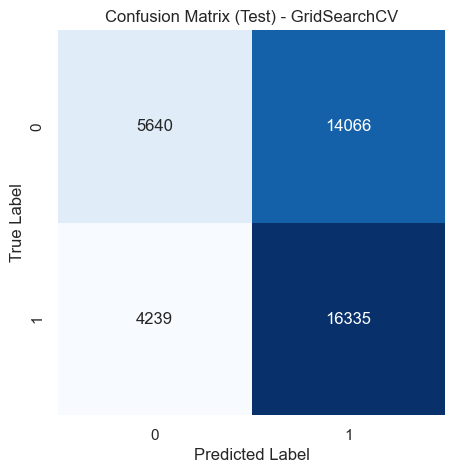

{'Classifier': 'GridSearchCV',
 'Test Accuracy': 0.5455561072492552,
 'Test F1 Score': 0.6409024031387935,
 'Test Recall': 0.7939632545931758,
 'Test Precision': 0.5373178513864676,
 'Test ROC AUC': 0.5400852505585386,
 'Train Time': 129.61497497558594,
 'Test Time': 0.01658034324645996,
 'Train Accuracy': 0.5468905163853028,
 'Train F1 Score': 0.6419234749682413,
 'Train Recall': 0.7975866902309708,
 'Train Precision': 0.5370990511835583,
 'Train ROC AUC': 0.5421825325957257,
 'Train Prediction Time': 0.06243324279785156}

In [155]:
benchmark_bought(gridsearch_boosting_bought)

In [156]:
best_boosting_model_bought = gridsearch_boosting_bought.best_estimator_
best_boosting_param_bought = gridsearch_boosting_bought.best_params_
best_boosting_param_bought

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

After a lot of testing this XGBoosting model below turns out to be the best model for our specific task

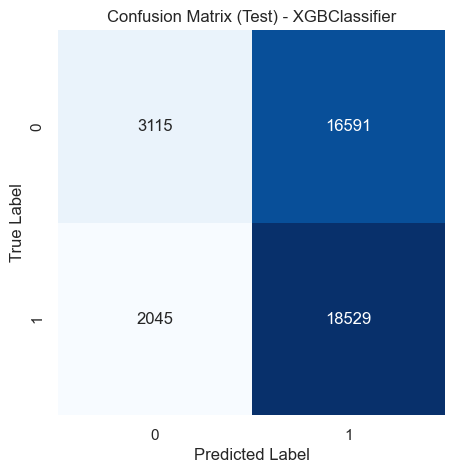

{'Classifier': 'XGBClassifier',
 'Test Accuracy': 0.5373386295928501,
 'Test F1 Score': 0.6653858584407656,
 'Test Recall': 0.9006027024399728,
 'Test Precision': 0.5275911161731207,
 'Test ROC AUC': 0.5293381927910815,
 'Train Time': 4.846099138259888,
 'Test Time': 0.1560823917388916,
 'Train Accuracy': 0.5936506951340615,
 'Train F1 Score': 0.7049779424024081,
 'Train Recall': 0.9534279968310074,
 'Train Precision': 0.5592461787036904,
 'Train ROC AUC': 0.5868942070781658,
 'Train Prediction Time': 0.5537376403808594}

In [357]:
boosting_bought = XGBClassifier(max_depth = 4 ,scale_pos_weight = 1.64, n_estimators = 500, beta = 0.01)
benchmark_bought(boosting_bought)

Feature importance of best model in determining whether customer will buy the product or not

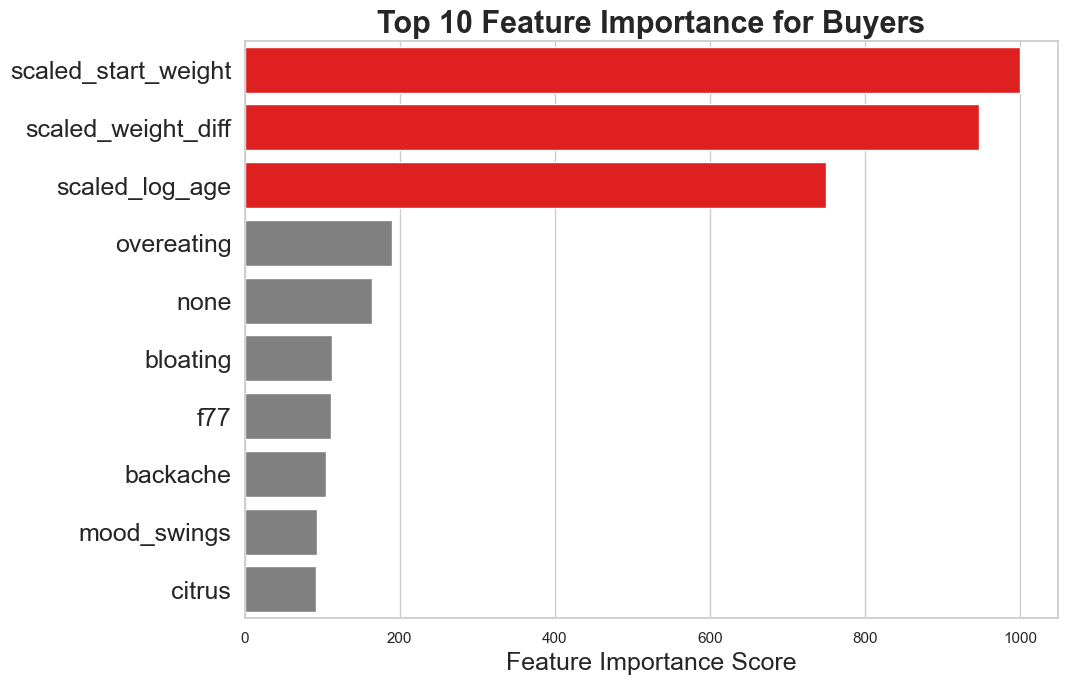

In [358]:
numerical_feature_names = ['scaled_start_weight', 'scaled_weight_diff', 'scaled_log_age', 'Is_United_States', 'Is_Male']
tfidf_feature_names = list(vectorizer.get_feature_names_out())
combined_feature_names = numerical_feature_names + tfidf_feature_names
colors = ['red' if x > 0.12 or x < -0.2 else 'grey' for x in stats_df['difference']]


booster = boosting_bought.get_booster()


importance = booster.get_score(importance_type='weight')
full_feature_name_mapping = {f'f{i}': name for i, name in enumerate(combined_feature_names)}
mapped_importance = {full_feature_name_mapping.get(f, f): score for f, score in importance.items()}


sorted_importance = sorted(mapped_importance.items(), key=lambda item: item[1], reverse=True)

top_10_features = sorted_importance[:10]  

sorted_feature_names, sorted_scores = zip(*top_10_features)

plt.figure(figsize=(10.5, 7.5))
sns.barplot(x=sorted_scores, y=sorted_feature_names, palette=colors )
plt.xlabel('Feature Importance Score', fontsize = 18 )
plt.title('Top 10 Feature Importance for Buyers',fontsize = 22, fontweight = 'bold')
plt.yticks(fontsize=18)

plt.show()

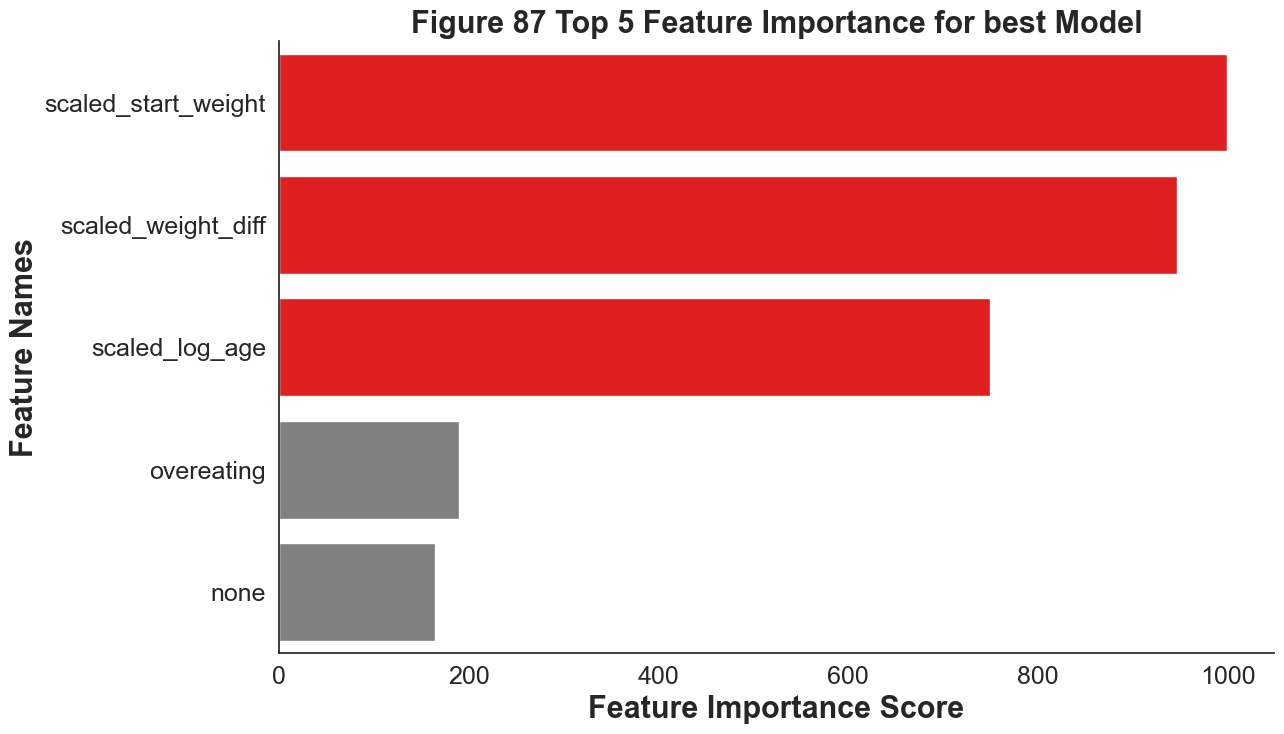

In [361]:
numerical_feature_names = ['scaled_start_weight', 'scaled_weight_diff', 'scaled_log_age', 'Is_United_States', 'Is_Male']
tfidf_feature_names = list(vectorizer.get_feature_names_out())
combined_feature_names = numerical_feature_names + tfidf_feature_names
colors = ['red' if x > 0.12 or x < -0.2 else 'grey' for x in stats_df['difference']]


booster = boosting_bought.get_booster()


mportance = booster.get_score(importance_type='weight')
full_feature_name_mapping = {f'f{i}': name for i, name in enumerate(combined_feature_names)}
mapped_importance = {full_feature_name_mapping.get(f, f): score for f, score in importance.items()}


sorted_importance = sorted(mapped_importance.items(), key=lambda item: item[1], reverse=True)

top_10_features = sorted_importance[:5]  

sorted_feature_names, sorted_scores = zip(*top_10_features)
sns.set_style("white")
plt.figure(figsize=(13, 7.5))
sns.barplot(x=sorted_scores, y=sorted_feature_names, palette= colors)
plt.xlabel('Feature Importance Score', fontsize=22, fontweight='bold')
plt.ylabel('Feature Names', fontsize=22, fontweight='bold')
plt.title('Figure 87 Top 5 Feature Importance for best Model', fontsize=22, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=18)
sns.despine(right=True, top=True)
plt.tight_layout()

plt.show()

## Next part contains building a predictive model based on customer characteristics on upsells

Class imbalance

In [91]:
clients_without_upsell = buyers[buyers['upsell_id'] == 'non-upsale']['client_id'].nunique()


clients_with_upsell = buyers[buyers['upsell_id'] == 'upsale']['client_id'].nunique()

print(f"Unique clients with upsell: {clients_with_upsell}")
print(f"Unique clients without upsell: {clients_without_upsell}")

Unique clients with upsell: 14626
Unique clients without upsell: 87969


In [92]:
buyers['flavour'].value_counts()

flavour
Strawberry    74067
Tropical      23487
none          13826
Premium        7093
None           3248
uncertain       345
Name: count, dtype: int64

In [93]:
buyers['flavour'] = buyers['flavour'].replace({'None': 'none','uncertain':'none'})
buyers['flavour'].value_counts()

flavour
Strawberry    74067
Tropical      23487
none          17419
Premium        7093
Name: count, dtype: int64

In our data we have both cateogrical and numeric variables, therefore different approaches are chosen. Instead of quiz answers we use simplier approach focusing on the number of symptoms, allergies, medical and digestive conditions

In [94]:
columns_to_encode = ['flavour', 'sub_project', 'is_subscription', 'is_supplement', 'gender', 'pregnant', 'upsell_id']
buyers_encoded = pd.get_dummies(data=buyers, columns=columns_to_encode, drop_first=True )

The only categorical variable left to encode is item category. We do not dummify it like other categorical variables since it can take a lot of values and our main concern is 1, 3, 6 month colonbroom products that are either OTP's or subscriptions. Therefore we create 6 variables depending on the Colonbroom product purchase type and duration

In [95]:
buyers_encoded['Is_Colonbroom_1m_OTP'] = buyers_encoded['item_category'].apply(lambda x: 1 if x == 'Colonbroom 1 Month OTP' else 0)
buyers_encoded['Is_Colonbroom_3m_OTP'] = buyers_encoded['item_category'].apply(lambda x: 1 if x == 'Colonbroom 3 Month OTP' else 0)
buyers_encoded['Is_Colonbroom_6m_OTP'] = buyers_encoded['item_category'].apply(lambda x: 1 if x == 'Colonbroom 6 Month OTP' else 0)
buyers_encoded['Is_Colonbroom_1m_subscription'] = buyers_encoded['item_category'].apply(lambda x: 1 if x == 'Colonbroom 1 Month Subscription' else 0)
buyers_encoded['Is_Colonbroom_3m_subscription'] = buyers_encoded['item_category'].apply(lambda x: 1 if x == 'Colonbroom 3 Month Subscription' else 0)

Only initial purchases are chosen

In [96]:
buyers_encoded['item_category'].value_counts()

item_category
Colonbroom 3 Month Subscription    28797
Colonbroom 6 Month Subscription    23713
Colonbroom 1 Month OTP             16233
Colonbroom 3 Month OTP             14446
Colonbroom 1 Month Subscription    12414
Colonbroom 6 Month OTP              5435
DF Capsules                         4649
Fat Burners                         3248
Extra                               2541
Sugar Cravings                      1944
DF 6 Month Supply Box               1688
DF 3 Month Supply Box               1571
Shipping                            1492
DF 1 Month Supply Box               1351
Shakers                              615
Colonbroom 5 Month OTP               604
Colonbroom 5 Month Subscription      539
ColonBroom Trial                     345
Colonbroom 2 Month OTP               137
Colonbroom 4 Month Subscription      116
Colonbroom 2 Month Subscription       95
Colonbroom 4 Month OTP                71
Travel Packs                          12
Bioma 1 Month Bottle                   4
Bi

In [97]:
buyers_encoded['item_category'].value_counts()
buyers_encoded = buyers_encoded[buyers_encoded['item_category'].isin(['Colonbroom 1 Month OTP', 'Colonbroom 3 Month OTP', 'Colonbroom 6 Month OTP', 
                                'Colonbroom 1 Month Subscription', 'Colonbroom 3 Month Subscription', 'Colonbroom 6 Month Subscription'])]


In [98]:
buyers_encoded['item_category'].value_counts()

item_category
Colonbroom 3 Month Subscription    28797
Colonbroom 6 Month Subscription    23713
Colonbroom 1 Month OTP             16233
Colonbroom 3 Month OTP             14446
Colonbroom 1 Month Subscription    12414
Colonbroom 6 Month OTP              5435
Name: count, dtype: int64

In [99]:
buyers_encoded['upsell_id_upsale'].value_counts()

upsell_id_upsale
False    86413
True     14625
Name: count, dtype: int64

Moving on to deal with numeric variables which are: quantity, item amount in usd, age, starting bmi, starting weight, target weight and also quiz answers are converted to numeric variables, symptom count, allergy count, medical count, digestive count. Each variable is looked at independantly

Fixing non-normality of item amount in usd variable

<Axes: xlabel='item_amount_in_usd', ylabel='Count'>

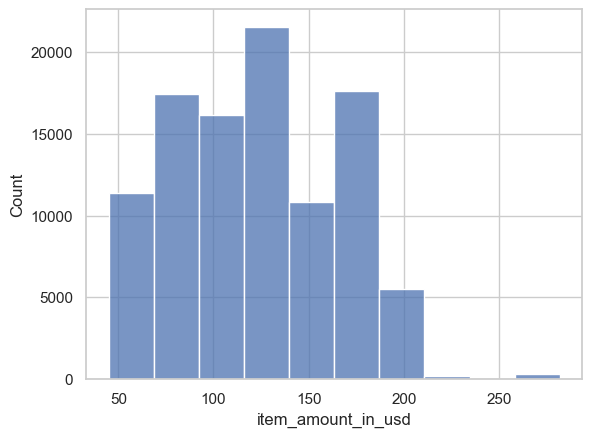

In [100]:
sns.histplot(buyers_encoded['item_amount_in_usd'], bins = 10)

In [101]:
buyers_encoded.loc[:, 'log_amount_usd'] = np.log(buyers_encoded['item_amount_in_usd'])

<Axes: xlabel='log_amount_usd', ylabel='Count'>

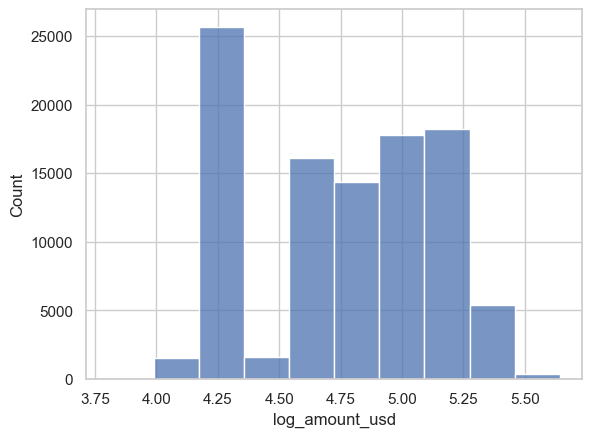

In [103]:
sns.histplot(buyers_encoded['log_amount_usd'], bins = 10)

log - log transformation

In [102]:
buyers_encoded.loc[:, 'log_log_amount_usd'] = np.log(buyers_encoded['log_amount_usd'])

<Axes: xlabel='log_log_amount_usd', ylabel='Count'>

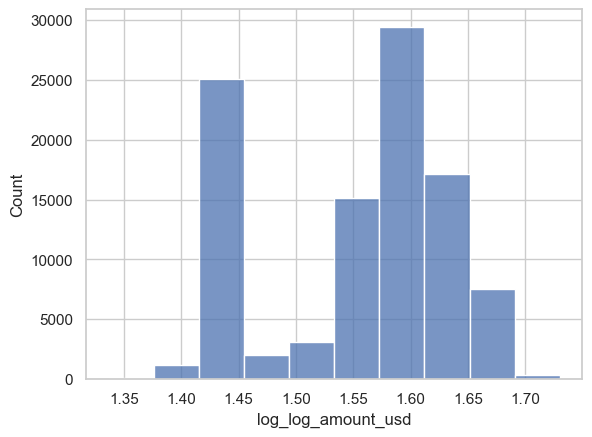

In [105]:
sns.histplot(buyers_encoded['log_log_amount_usd'], bins = 10)

Taking a log of variables, age, starting bmi, starting weight and target weight from previously done analysis they improve normality

In [103]:
buyers_encoded.loc[:, 'log_age'] = np.log(buyers_encoded['age'])
buyers_encoded.loc[:, 'log_starting_bmi'] = np.log(buyers_encoded['starting_bmi'])
buyers_encoded.loc[:, 'log_starting_weight_in_kg'] = np.log(buyers_encoded['starting_weight_in_kg'])
buyers_encoded.loc[:, 'log_target_weight_in_kg'] = np.log(buyers_encoded['target_weight_in_kg'])

Next step is scaling all of the numeric variables

In [104]:
buyers_encoded.loc[:, 'scaled_age'] = scaler.fit_transform(buyers_encoded[['log_age']])
buyers_encoded.loc[:, 'scaled_amount_usd'] = scaler.fit_transform(buyers_encoded[['log_log_amount_usd']])
buyers_encoded.loc[:, 'scaled_starting_bmi'] = scaler.fit_transform(buyers_encoded[['log_starting_bmi']])
buyers_encoded.loc[:, 'scaled_starting_weight_in_kg'] = scaler.fit_transform(buyers_encoded[['log_starting_weight_in_kg']])
buyers_encoded.loc[:, 'scaled_target_weight_in_kg'] = scaler.fit_transform(buyers_encoded[['log_target_weight_in_kg']])

Choosing relevant explanatory variables and diving into X and y

In [105]:
X_variables = [
    'quantity', 
    'symptom_count', 
    'allergy_count', 
    'medical_count', 
    'digestive_count',
    'scaled_age', 
    'scaled_starting_bmi', 
    'scaled_target_weight_in_kg',
    'scaled_starting_weight_in_kg',
    'scaled_amount_usd',
    'flavour_Strawberry',
    'flavour_Tropical',
    'sub_project_Premium',
    'is_supplement_Yes',
    'gender_male',
    #'gender_female',
    'Is_Colonbroom_1m_OTP', 
    'Is_Colonbroom_3m_OTP', 
    'Is_Colonbroom_6m_OTP',
    'is_subscription_Yes', 
    'Is_Colonbroom_1m_subscription', 
    'Is_Colonbroom_3m_subscription', 
    #'Is_Colonbroom_6m_subscription'
]

buyers_encoded_cleaned = buyers_encoded.dropna(subset=['scaled_amount_usd'])
X_upsell = buyers_encoded_cleaned[X_variables]

y_upsell = buyers_encoded_cleaned['upsell_id_upsale']


Performing train - test split

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X_upsell, y_upsell, test_size = 0.2, random_state = 42)

Different benchmark function for this data

In [107]:
def benchmark(clf: BaseEstimator, custom_name: str = "") -> dict:
    model = clf
    clf_descr = custom_name if custom_name else clf.__class__.__name__

    logging.info(f"{'-'*80}\nTraining: {clf_descr}")

    try:
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        t0 = time.time()
        pred_test = model.predict(X_test)
        test_time = time.time() - t0
        
        t0 = time.time()
        pred_train = model.predict(X_train)
        train_pred_time = time.time() - t0

        score_test = accuracy_score(y_test, pred_test)
        f1_test = f1_score(y_test, pred_test, average='binary')
        recall_test = recall_score(y_test, pred_test, average='binary')
        precision_test = precision_score(y_test, pred_test, average='binary')
        roc_auc_test = roc_auc_score(y_test, pred_test)
        
        score_train = accuracy_score(y_train, pred_train)
        f1_train = f1_score(y_train, pred_train, average='binary')
        recall_train = recall_score(y_train, pred_train, average='binary')
        precision_train = precision_score(y_train, pred_train, average='binary')
        roc_auc_train = roc_auc_score(y_train, pred_train)
        
        
        def plot_confusion_matrix(y_true, y_pred, title):
            matrix = confusion_matrix(y_true, y_pred)
            plt.figure(figsize=(5, 5))
            sns.heatmap(matrix, annot=True, fmt='d', cmap='Greens', cbar=False)
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.title(title)
            plt.show()

        plot_confusion_matrix(y_test, pred_test, f"Confusion Matrix (Test) - {clf_descr}")

        logging.info(f"Test Metrics:")
        logging.info(f"Train time: {train_time:.3f}s")
        logging.info(f"Test time:  {test_time:.3f}s")
        logging.info(f"Accuracy:   {score_test:.3f}")
        logging.info(f"F1 Score:   {f1_test:.3f}")
        logging.info(f"Recall:     {recall_test:.3f}")
        logging.info(f"Precision:  {precision_test:.3f}")
        logging.info(f"ROC AUC:    {roc_auc_test:.3f}\n")

        logging.info(f"Training Metrics (on training set):")
        logging.info(f"Prediction time: {train_pred_time:.3f}s")
        logging.info(f"Accuracy:   {score_train:.3f}")
        logging.info(f"F1 Score:   {f1_train:.3f}")
        logging.info(f"Recall:     {recall_train:.3f}")
        logging.info(f"Precision:  {precision_train:.3f}")
        logging.info(f"ROC AUC:    {roc_auc_train:.3f}\n")

    except Exception as e:
        logging.error(f"Error training {clf_descr}: {e}")
        return {
            'Classifier': clf_descr,
            'Error': str(e)
        }

    return {
        'Classifier': clf_descr,
        'Test Accuracy': score_test,
        'Test F1 Score': f1_test,
        'Test Recall': recall_test,
        'Test Precision': precision_test,
        'Test ROC AUC': roc_auc_test,
        'Train Time': train_time,
        'Test Time': test_time,
        'Train Accuracy': score_train,
        'Train F1 Score': f1_train,
        'Train Recall': recall_train,
        'Train Precision': precision_train,
        'Train ROC AUC': roc_auc_train,
        'Train Prediction Time': train_pred_time
    }

Logistic Regression classifier

In [ ]:
logit = LogisticRegression(random_state=42)
param_logit = {
    'C': [0.001, 0.01, 0.1],
    'solver': ['liblinear', 'saga'],  
    'class_weight': ['balanced'],
    'max_iter': [100, 200]}
grid_search_logit = GridSearchCV(estimator=logit, param_grid=param_logit, 
                           scoring='f1', n_jobs=-1, cv=5, verbose=3)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


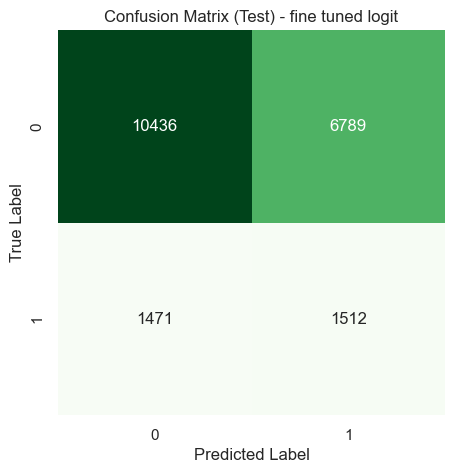

{'Classifier': 'fine tuned logit',
 'Test Accuracy': 0.5912509897070467,
 'Test F1 Score': 0.2679900744416873,
 'Test Recall': 0.5068722762319813,
 'Test Precision': 0.18214672930972173,
 'Test ROC AUC': 0.5563679233119267,
 'Train Time': 13.43392038345337,
 'Test Time': 0.005377769470214844,
 'Train Accuracy': 0.5982927131015712,
 'Train F1 Score': 0.27282092627429905,
 'Train Recall': 0.5231918914275897,
 'Train Precision': 0.1845198424719782,
 'Train ROC AUC': 0.567060766202897,
 'Train Prediction Time': 0.010413169860839844}

In [ ]:
benchmark(grid_search_logit, 'fine tuned logit')

In [ ]:
best_logit_model = grid_search_logit.best_estimator_
best_logit_param = grid_search_logit.best_params_
best_logit_param

{'C': 0.1, 'class_weight': 'balanced', 'max_iter': 100, 'solver': 'liblinear'}

Calculating coefficient for each variable

In [ ]:
feature_names = X_train.columns
coefficients = best_logit_model.coef_[0]  

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by= 'Coefficient',ascending=False)
print(coef_df)

                          Feature  Coefficient
15           Is_Colonbroom_1m_OTP     0.630811
8    scaled_starting_weight_in_kg     0.261027
13              is_supplement_Yes     0.221058
9               scaled_amount_usd     0.109184
18            is_subscription_Yes     0.042754
1                   symptom_count     0.037049
4                 digestive_count     0.030166
5                      scaled_age     0.013969
6             scaled_starting_bmi     0.008972
0                        quantity    -0.004928
3                   medical_count    -0.011197
2                   allergy_count    -0.012053
14                    gender_male    -0.015447
20  Is_Colonbroom_3m_subscription    -0.150305
19  Is_Colonbroom_1m_subscription    -0.151122
16           Is_Colonbroom_3m_OTP    -0.205417
7      scaled_target_weight_in_kg    -0.226597
17           Is_Colonbroom_6m_OTP    -0.247090
11               flavour_Tropical    -0.579767
12            sub_project_Premium    -0.652360
10           

Depicting coefficients graphically

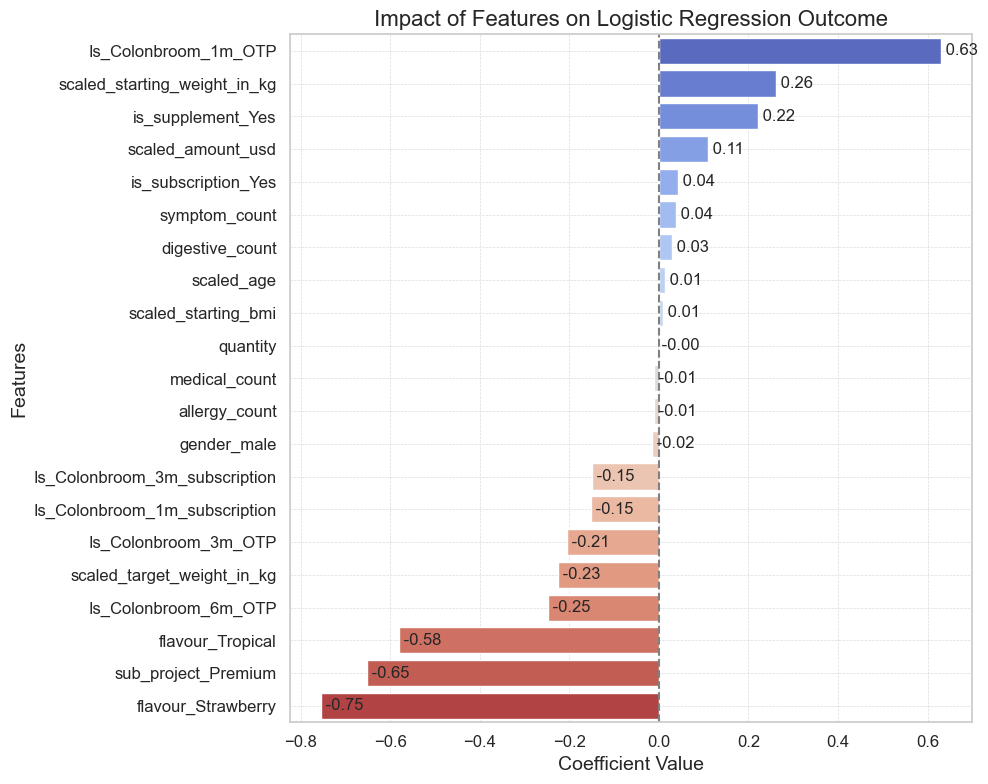

In [ ]:
plt.figure(figsize=(10, 8))

bar_plot = sns.barplot(x='Coefficient', y='Feature', data=coef_df,
                       palette='coolwarm', orient='h')

for p in bar_plot.patches:
    width = p.get_width()
    plt.text(p.get_width(), p.get_y() + p.get_height() / 2.,
             f' {width:.2f}',  
             va='center')

plt.title('Impact of Features on Logistic Regression Outcome', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.axvline(x=0, color='grey', linestyle='--')  
plt.tight_layout()


plt.show()


KNN classifier

In [ ]:
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7], 
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean'],
    'p': [1, 2]  
}
grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid, 
                           scoring='f1', n_jobs=-1, cv=5, verbose=3)


Fitting 5 folds for each of 12 candidates, totalling 60 fits


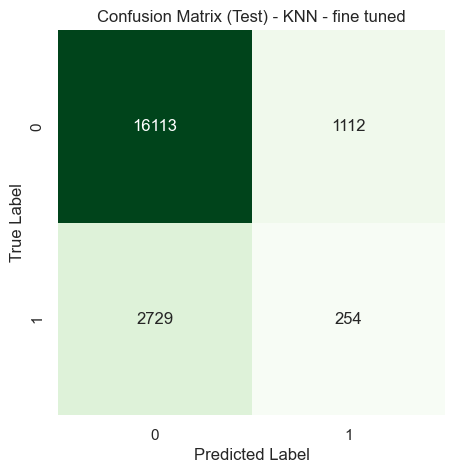

{'Classifier': 'KNN - fine tuned',
 'Test Accuracy': 0.8099267616785432,
 'Test F1 Score': 0.11680846171533686,
 'Test Recall': 0.08514917867918204,
 'Test Precision': 0.18594436310395315,
 'Test ROC AUC': 0.5102959246080961,
 'Train Time': 37.13937973976135,
 'Test Time': 1.1339640617370605,
 'Train Accuracy': 0.9999505134232339,
 'Train F1 Score': 0.9998281934541706,
 'Train Recall': 0.9997423123174712,
 'Train Precision': 0.999914089347079,
 'Train ROC AUC': 0.9998639294720271,
 'Train Prediction Time': 4.3348870277404785}

In [ ]:
benchmark(grid_search_knn, 'KNN - fine tuned')

In [ ]:
best_knn_model = grid_search_knn.best_estimator_
best_knn_param = grid_search_knn.best_params_
best_knn_param

{'metric': 'euclidean', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}

Random Forest model optimizing via GridSearch

In [ ]:
R_forest = RandomForestClassifier(random_state=42)
param_forest = {
    'max_depth': [3, 5, 7, 9],
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [{0:1, 1:20}, 'balanced']
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gridsearch_r_forest = GridSearchCV(
    estimator=R_forest,
    param_grid=param_forest,
    scoring='f1',  
    n_jobs=-1,
    cv=cv_strategy,
    verbose=2
)

Random Forest grid Search results

Fitting 5 folds for each of 32 candidates, totalling 160 fits


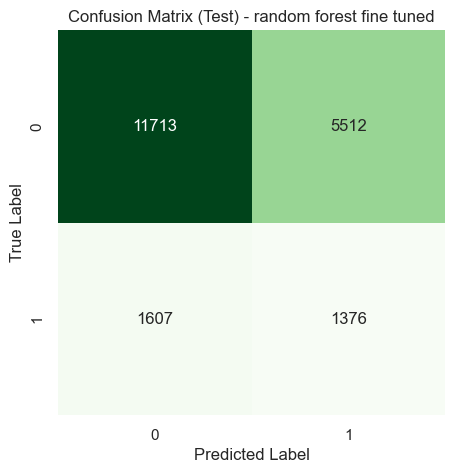

{'Classifier': 'random forest fine tuned',
 'Test Accuracy': 0.6477137767220903,
 'Test F1 Score': 0.2787964745213251,
 'Test Recall': 0.461280590010057,
 'Test Precision': 0.1997677119628339,
 'Test ROC AUC': 0.5706402950050284,
 'Train Time': 120.7073245048523,
 'Test Time': 0.2001786231994629,
 'Train Accuracy': 0.6713101571198812,
 'Train F1 Score': 0.32479414455626715,
 'Train Recall': 0.548874763786291,
 'Train Precision': 0.23063596332924277,
 'Train ROC AUC': 0.6203933280109694,
 'Train Prediction Time': 0.7815673351287842}

In [ ]:
benchmark(gridsearch_r_forest, 'random forest fine tuned')

In [ ]:
best_r_forest = gridsearch_r_forest.best_estimator_
best_r_forest_params = gridsearch_r_forest.best_params_
best_r_forest_params

{'class_weight': 'balanced',
 'max_depth': 9,
 'max_features': 'sqrt',
 'n_estimators': 200}

Feature importance graph for Random Forest model

Text(0, 0.5, 'Features')

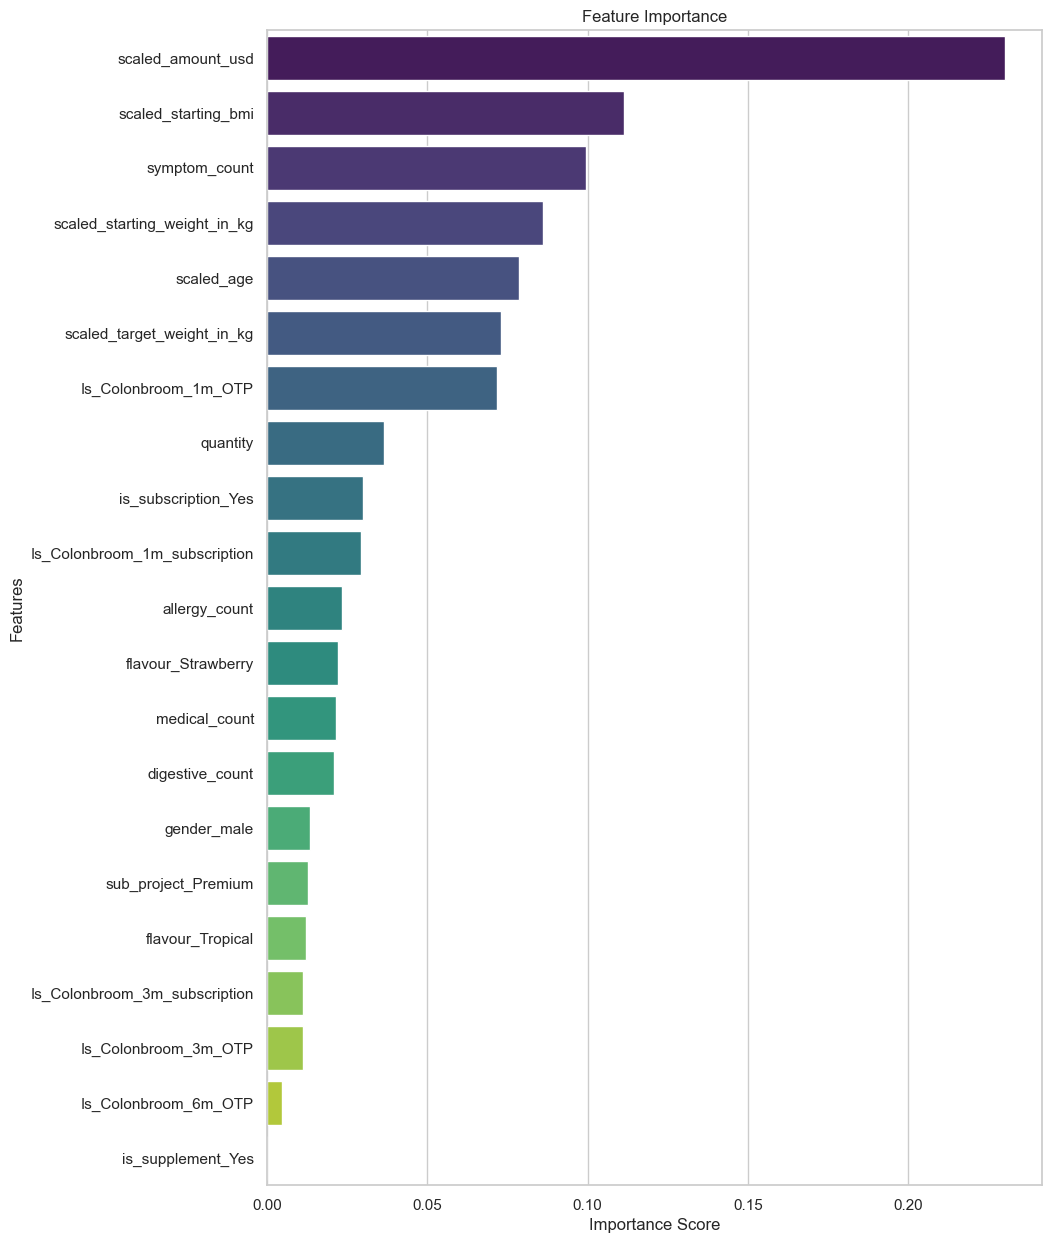

In [ ]:
importances = best_r_forest.feature_importances_

feature_names = X_train.columns
importances_series = pd.Series(importances, index=feature_names)
sorted_importances = importances_series.sort_values(ascending=False)


plt.figure(figsize=(10, 15))
sns.barplot(x=sorted_importances, y=sorted_importances.index, palette="viridis")
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

XGBoost model

Assuming that recall is more important than precision we try to maximize recall instead of f1!

In [ ]:
param_bag = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.1, 0.01],  
    'n_estimators': [50, 150],   
    'scale_pos_weight': [1.6, 2.4, 3.6]  
}

boosting = XGBClassifier()

gridsearch_boosting = GridSearchCV(
    boosting,
    param_bag,
    scoring='recall',  
    n_jobs=-1,
    cv=5,
    verbose=3
)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


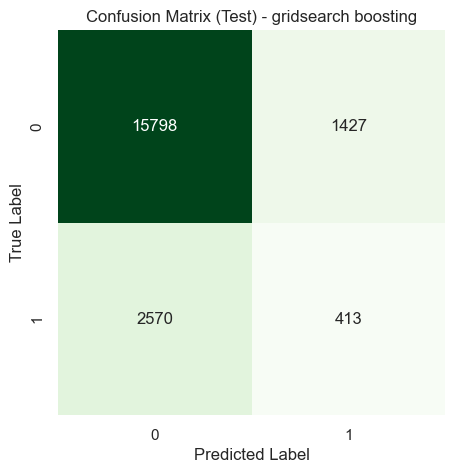

{'Classifier': 'gridsearch boosting',
 'Test Accuracy': 0.8022070467141726,
 'Test F1 Score': 0.17126269956458637,
 'Test Recall': 0.13845122360040227,
 'Test Precision': 0.22445652173913044,
 'Test ROC AUC': 0.5278032605665292,
 'Train Time': 27.062624216079712,
 'Test Time': 0.03616046905517578,
 'Train Accuracy': 0.8348880366200668,
 'Train F1 Score': 0.308927091963546,
 'Train Recall': 0.2562274523277787,
 'Train Precision': 0.3889178617992177,
 'Train ROC AUC': 0.5942422455603166,
 'Train Prediction Time': 0.13327789306640625}

In [ ]:
benchmark(gridsearch_boosting, 'gridsearch boosting')


In [ ]:
best_boosting_model = gridsearch_boosting.best_estimator_
best_boosting_param = gridsearch_boosting.best_params_
best_boosting_param

{'learning_rate': 0.1,
 'max_depth': 6,
 'n_estimators': 150,
 'scale_pos_weight': 3.6}

Feature importances for XGBoost model

Text(0, 0.5, 'Features')

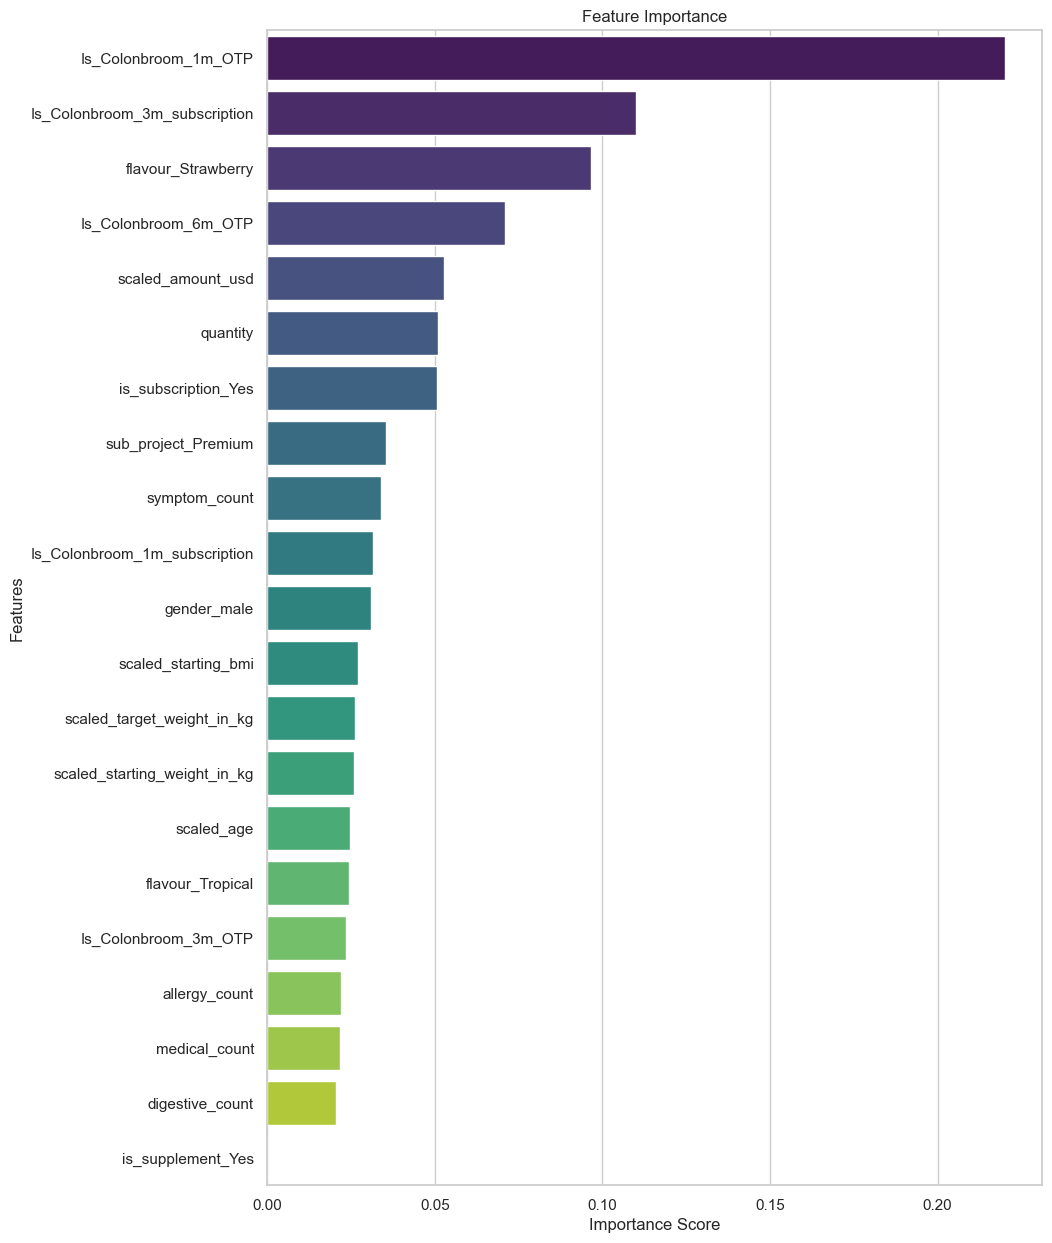

In [ ]:
importances = best_boosting_model.feature_importances_

feature_names = X_train.columns
importances_series = pd.Series(importances, index=feature_names)
sorted_importances = importances_series.sort_values(ascending=False)


plt.figure(figsize=(10, 15))
sns.barplot(x=sorted_importances, y=sorted_importances.index, palette="viridis")
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

Implementing XGBoost classification algorithm via Random search

Fitting 4 folds for each of 25 candidates, totalling 100 fits


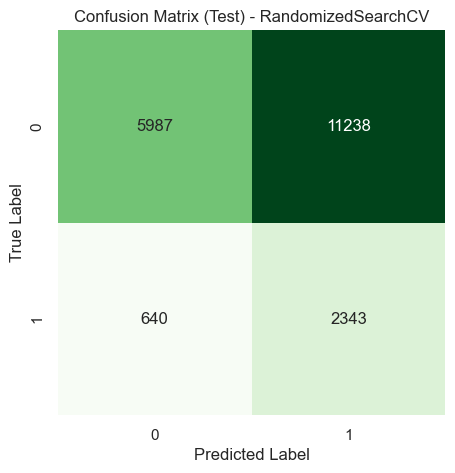

{'Classifier': 'RandomizedSearchCV',
 'Test Accuracy': 0.41221298495645287,
 'Test F1 Score': 0.2829026805119536,
 'Test Recall': 0.7854508883674154,
 'Test Precision': 0.1725204329578087,
 'Test ROC AUC': 0.5665135428774668,
 'Train Time': 78.70647525787354,
 'Test Time': 0.0288848876953125,
 'Train Accuracy': 0.43356427069157494,
 'Train F1 Score': 0.30711723845699845,
 'Train Recall': 0.8715856382064937,
 'Train Precision': 0.1863989565920238,
 'Train ROC AUC': 0.6157228647759069,
 'Train Prediction Time': 0.1475515365600586}

In [ ]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')

param_dist = {
    'n_estimators': randint(50, 1000),
    'learning_rate': uniform(0.01, 0.6),
    'subsample': uniform(0.3, 0.6),
    'max_depth': randint(3, 10),
    'colsample_bytree': uniform(0.5, 0.45),
    'min_child_weight': randint(1, 6),
    'scale_pos_weight': randint(1, 10)
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=25,  
    scoring='recall',  
    n_jobs=-1,  
    cv=4,  
    verbose=1,  
    random_state=42  
)

benchmark(random_search)

#print(f"Best parameters found: {random_search.best_params_}")
##print(f"Best score achieved: {random_search.best_score_}")


Implementing SMOTE, using XGBoost algorithm via GridSearch

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
param_bag = {
    'max_depth': [3, 4],
    'learning_rate': [0.1, 0.2],  
    'n_estimators': [100, 200],  
    'gamma': [0, 1,],  
    'scale_pos_weight': [6, 6.5]  
}

boosting = XGBClassifier()

gridsearch_boosting_smote = GridSearchCV(
    boosting,
    param_bag,
    scoring='f1',  
    n_jobs=-1,
    cv=5,
    verbose=3
)


In [ ]:
gridsearch_boosting_smote.fit(X_train_smote, y_train_smote)
y_smote_preds = gridsearch_boosting_smote.predict(X_test)


Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:
def evaluate_model_performance(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    
    print(f'Accuracy: {accuracy:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'ROC AUC Score: {roc_auc:.4f}')
evaluate_model_performance(y_test, y_smote_preds)

Accuracy: 0.1922
F1 Score: 0.2624
Recall: 0.9735
Precision: 0.1516
ROC AUC Score: 0.5152


Results after implementing SMOTE, with XGBoost algorithm

Confusion matrix, without normalization
[[  979 16246]
 [   79  2904]]


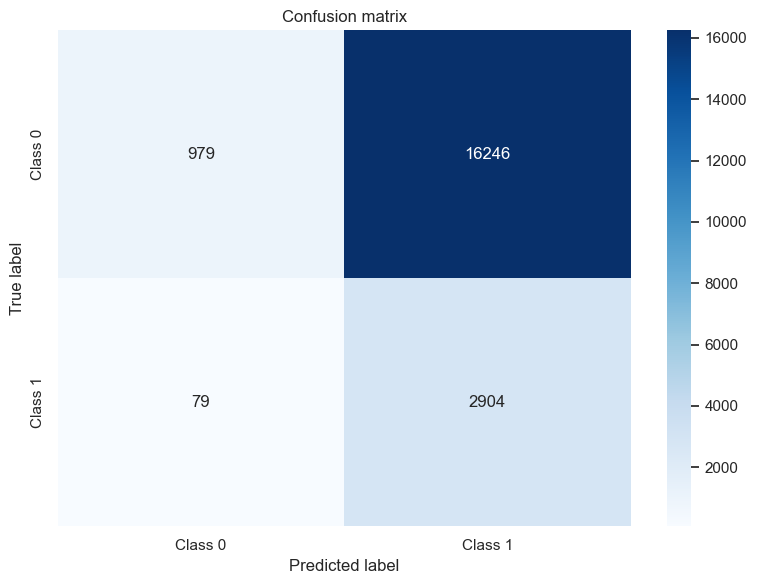

In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap=cmap, 
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

plot_confusion_matrix(y_test, y_smote_preds, classes=['Class 0', 'Class 1'], normalize=False, title='Confusion matrix')
plt.show()


New variable selection method 

In [371]:
buyers_encoded_cleaned.loc[:,'Combined_Quiz'] = buyers_encoded_cleaned.apply(lambda row: ' '.join([row['quiz_linked_to'], row['quiz_poop'], row['quiz_symptoms'], row['quiz_symptoms_two'], row['quiz_allergies'],
 row['quiz_symptoms'], row['quiz_medical_conditions'],row['quiz_digestive'],row['quiz_physically_active'],row['quiz_pregnant'], row['quiz_breastfeeding']]), axis=1)

After new variable 'Combined_Quiz' is created we proceed to implement TF-IDF vectorizer

In [372]:
df_upsell_tfidf = buyers_encoded_cleaned
df_upsell_tfidf.loc[:,'Combined_Quiz'] = df_upsell_tfidf.apply(lambda row: ' '.join([row['quiz_linked_to'], row['quiz_poop'], row['quiz_symptoms'], row['quiz_symptoms_two'], row['quiz_allergies'],
 row['quiz_symptoms'], row['quiz_medical_conditions'],row['quiz_digestive'],row['quiz_physically_active'],row['quiz_pregnant'], row['quiz_breastfeeding']]), axis=1)


In [373]:
(df_upsell_tfidf['Combined_Quiz']).count()

101038

In [374]:
vectorizer = TfidfVectorizer()
tfidf_matrix_upsell =  vectorizer.fit_transform(df_upsell_tfidf['Combined_Quiz'])
tfidf_matrix_upsell.shape

(101038, 77)

In [375]:
missing_values = df_upsell_tfidf.isnull().any()

print(missing_values[missing_values == True])

lead_id    True
dtype: bool


In [376]:
X_upsell_numeric = df_upsell_tfidf[[    
    'quantity', 
    #'symptom_count', 
    #'allergy_count', 
    #'medical_count', 
    #'digestive_count',
    'scaled_age', 
    'scaled_starting_bmi', 
    'scaled_target_weight_in_kg',
    'scaled_starting_weight_in_kg',
    'scaled_amount_usd',
    'flavour_Strawberry',
    'flavour_Tropical',
    'sub_project_Premium',
    'is_supplement_Yes',
    'gender_male',
    #'gender_female'
    'Is_Colonbroom_1m_OTP', 
    'Is_Colonbroom_3m_OTP', 
    'Is_Colonbroom_6m_OTP',
    'is_subscription_Yes', 
    'Is_Colonbroom_1m_subscription', 
    'Is_Colonbroom_3m_subscription', 
    #'Is_Colonbroom_6m_subscription'
    ]]

In [114]:
X_upsell_numeric.head()

,quantity,scaled_age,scaled_starting_bmi,scaled_target_weight_in_kg,scaled_starting_weight_in_kg,scaled_amount_usd,flavour_Strawberry,flavour_Tropical,sub_project_Premium,is_supplement_Yes,gender_male,Is_Colonbroom_1m_OTP,Is_Colonbroom_3m_OTP,Is_Colonbroom_6m_OTP,is_subscription_Yes,Is_Colonbroom_1m_subscription,Is_Colonbroom_3m_subscription
0,3.0,-0.407609,-0.857406,0.306692,-0.133024,0.501805,True,False,False,True,True,0,1,0,False,0,0
1,6.0,0.008471,-1.272209,-1.001829,-1.257798,0.989823,True,False,False,True,False,0,0,0,True,0,0
3,1.0,0.105456,-0.105243,0.719010,0.303944,-1.345908,True,False,False,True,True,1,0,0,False,0,0
4,3.0,1.580023,-0.545628,0.719010,0.303944,0.388791,True,False,False,True,True,0,0,0,True,0,1
5,1.0,1.580023,0.123766,-0.640742,-0.442544,-1.345908,True,False,False,True,False,1,0,0,False,0,0


In [115]:
missing_value_counts = X_upsell_numeric.isnull().sum()

# Print columns with their count of missing values
print(missing_value_counts[missing_value_counts > 0])

Series([], dtype: int64)


In [116]:
print(X_upsell_numeric.dtypes)

quantity                         float64
scaled_age                       float64
scaled_starting_bmi              float64
scaled_target_weight_in_kg       float64
scaled_starting_weight_in_kg     float64
scaled_amount_usd                float64
flavour_Strawberry                  bool
flavour_Tropical                    bool
sub_project_Premium                 bool
is_supplement_Yes                   bool
gender_male                         bool
Is_Colonbroom_1m_OTP               int64
Is_Colonbroom_3m_OTP               int64
Is_Colonbroom_6m_OTP               int64
is_subscription_Yes                 bool
Is_Colonbroom_1m_subscription      int64
Is_Colonbroom_3m_subscription      int64
dtype: object


In [377]:
bool_columns = X_upsell_numeric.select_dtypes(include=['bool']).columns
X_upsell_numeric[bool_columns] = X_upsell_numeric[bool_columns].astype(int)


sparse_numerical_features_upsell = scipy.sparse.csr_matrix(X_upsell_numeric.values)
sparse_numerical_features_upsell.shape

(101038, 17)

In [118]:
tfidf_matrix_upsell.shape

(101038, 77)

Diving variables into target and covariates

In [378]:
X_upsell_vect = hstack([sparse_numerical_features_upsell, tfidf_matrix_upsell])
y_upsell_vect = buyers_encoded_cleaned['upsell_id_upsale']

Implementing train- test split

In [379]:
X_train, X_test, y_train, y_test = train_test_split(X_upsell_vect, y_upsell_vect, test_size = 0.2, random_state = 42)

Optimizing using XGBoost classifier via GridSearch

In [365]:
boosting = XGBClassifier()

Fitting 5 folds for each of 16 candidates, totalling 80 fits


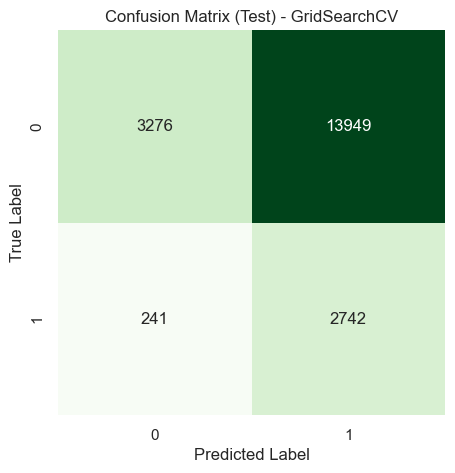

{'Classifier': 'GridSearchCV',
 'Test Accuracy': 0.29780285035629456,
 'Test F1 Score': 0.2787435193656603,
 'Test Recall': 0.9192088501508549,
 'Test Precision': 0.16428015097956983,
 'Test ROC AUC': 0.554698764698069,
 'Train Time': 34.91986918449402,
 'Test Time': 0.0,
 'Train Accuracy': 0.30081652851663987,
 'Train F1 Score': 0.27948544691918353,
 'Train Recall': 0.9415048960659681,
 'Train Precision': 0.1640991092147616,
 'Train ROC AUC': 0.5672576223406675,
 'Train Prediction Time': 0.03125882148742676}

In [380]:

param_bag = {
    'max_depth': [3, 5], 
    'learning_rate': [0.1, 0.01],  
    'n_estimators': [100,200], 
    'scale_pos_weight': [9, 8],  
}

gridsearch_boosting_tfidf = GridSearchCV(
    boosting,
    param_bag,
    scoring='roc_auc',  
    n_jobs=-1,
    cv=5,
    verbose=3
)
benchmark(gridsearch_boosting_tfidf)

In [381]:
best_boosting_model_tfidf = gridsearch_boosting_tfidf.best_estimator_
best_boosting_param_tfidf = gridsearch_boosting_tfidf.best_params_
best_boosting_param_tfidf

{'learning_rate': 0.1,
 'max_depth': 3,
 'n_estimators': 100,
 'scale_pos_weight': 9}

Feature importance for XGBoost algorithm viaa GridSearch using TF-IDF vectors. This is the best model we have found so far

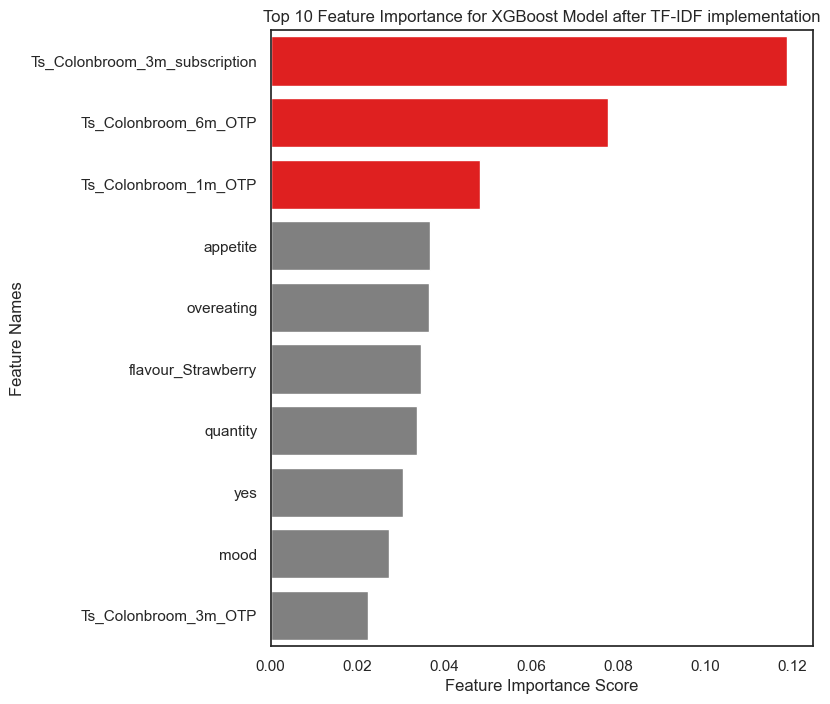

In [384]:

feature_importances = best_boosting_model_tfidf.feature_importances_

numerical_feature_names = [
    'quantity',
    'scaled_age',
    'scaled_starting_bmi',
    'scaled_target_weight_in_kg',
    'scaled_starting_weight_in_kg',
    'scaled_amount_usd',
    'flavour_Strawberry',
    'flavour_Tropical',
    'sub_project_Premium',
    'is_supplement_Yes',
    'gender_male',
    'Ts_Colonbroom_1m_OTP',
    'Ts_Colonbroom_3m_OTP',
    'Ts_Colonbroom_6m_OTP',
    'is_subscription_Yes',
    'Ts_Colonbroom_1m_subscription',
    'Ts_Colonbroom_3m_subscription',
]


tfidf_feature_names = list(vectorizer.get_feature_names_out())

combined_feature_names = numerical_feature_names + tfidf_feature_names


importance_df = pd.DataFrame({
    'Feature Name': combined_feature_names, 
    'Importance': feature_importances
})


importance_df = importance_df.sort_values(by='Importance', ascending=False)


top_10_importance_df = importance_df.head(10)

plt.figure(figsize=(7, 8))
sns.barplot(x='Importance', y='Feature Name', data=top_10_importance_df, palette=colors)

plt.title('Top 10 Feature Importance for XGBoost Model after TF-IDF implementation')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature Names')


plt.show()


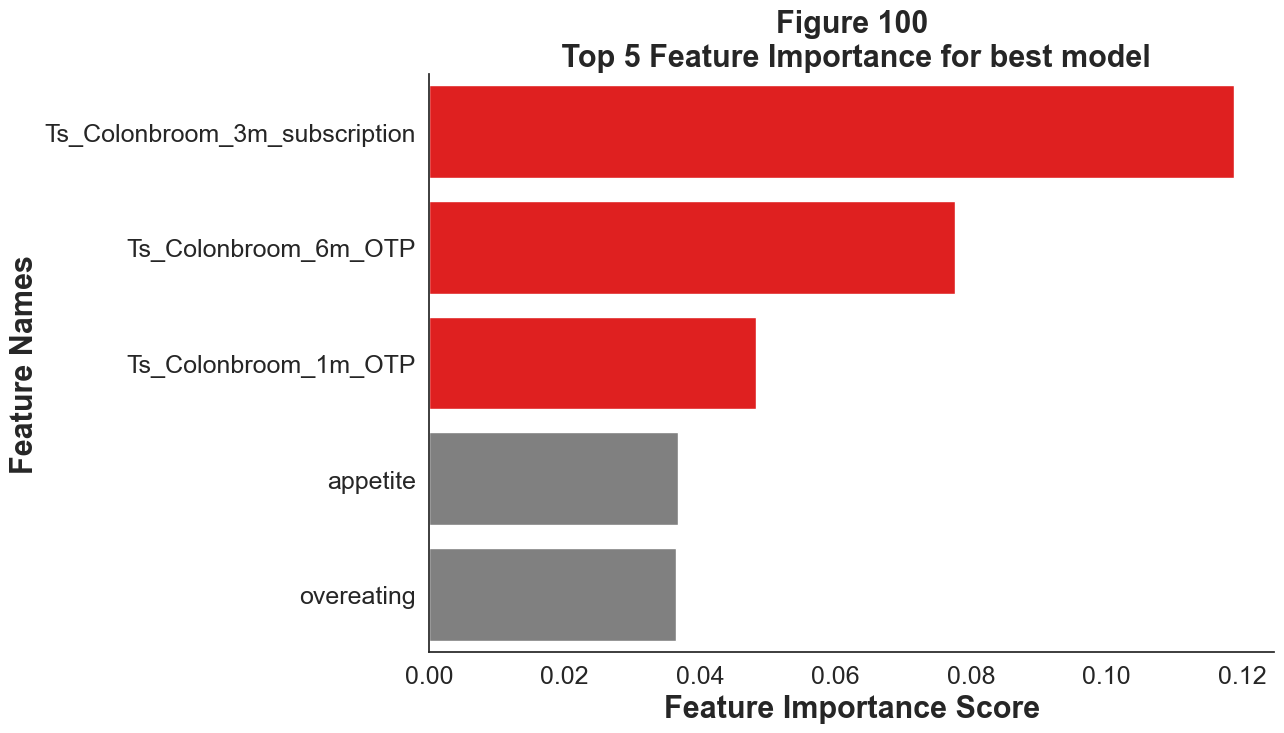

In [387]:
feature_importances = best_boosting_model_tfidf.feature_importances_

numerical_feature_names = [
    'quantity',
    'scaled_age',
    'scaled_starting_bmi',
    'scaled_target_weight_in_kg',
    'scaled_starting_weight_in_kg',
    'scaled_amount_usd',
    'flavour_Strawberry',
    'flavour_Tropical',
    'sub_project_Premium',
    'is_supplement_Yes',
    'gender_male',
    'Ts_Colonbroom_1m_OTP',
    'Ts_Colonbroom_3m_OTP',
    'Ts_Colonbroom_6m_OTP',
    'is_subscription_Yes',
    'Ts_Colonbroom_1m_subscription',
    'Ts_Colonbroom_3m_subscription',
]


tfidf_feature_names = list(vectorizer.get_feature_names_out())

combined_feature_names = numerical_feature_names + tfidf_feature_names


importance_df = pd.DataFrame({
    'Feature Name': combined_feature_names, 
    'Importance': feature_importances
})


importance_df = importance_df.sort_values(by='Importance', ascending=False)


top_10_importance_df = importance_df.head(5)

sns.set_style("white")
plt.figure(figsize=(13, 7.5))
sns.barplot(x='Importance', y='Feature Name', data=top_10_importance_df, palette= colors)

plt.title('Figure 100\n Top 5 Feature Importance for best model', fontsize=22, fontweight="bold")
plt.xlabel('Feature Importance Score', fontsize=22, fontweight="bold")
plt.ylabel('Feature Names', fontsize=22, fontweight="bold")

plt.tick_params(axis='both', which='major', labelsize=18)
sns.despine(right=True, top=True)
plt.tight_layout()


plt.show()

Final part of the predictive model is to determine what upsell is best to offer as upsale

Applying relevant data preprocessing tools

In [121]:
columns_to_encode = ['flavour', 'sub_project', 'is_subscription', 'is_supplement', 'gender', 'pregnant', 'upsell_id']
buyers_pred_upsell = pd.get_dummies(data=buyers, columns=columns_to_encode, drop_first=True)

In [122]:
buyers_pred_upsell.loc[:, 'log_amount_usd'] = np.log(buyers_pred_upsell['item_amount_in_usd'])
buyers_pred_upsell.loc[:, 'log_log_amount_usd'] = np.log(buyers_pred_upsell['log_amount_usd'])


c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [123]:
buyers_pred_upsell.loc[:, 'log_age'] = np.log(buyers_pred_upsell['age'])
buyers_pred_upsell.loc[:, 'log_starting_bmi'] = np.log(buyers_pred_upsell['starting_bmi'])
buyers_pred_upsell.loc[:, 'log_starting_weight_in_kg'] = np.log(buyers_pred_upsell['starting_weight_in_kg'])
buyers_pred_upsell.loc[:, 'log_target_weight_in_kg'] = np.log(buyers_pred_upsell['target_weight_in_kg'])

In [124]:
buyers_pred_upsell.loc[:, 'scaled_age'] = scaler.fit_transform(buyers_pred_upsell[['log_age']])
buyers_pred_upsell.loc[:, 'scaled_amount_usd'] = scaler.fit_transform(buyers_pred_upsell[['log_log_amount_usd']])
buyers_pred_upsell.loc[:, 'scaled_starting_bmi'] = scaler.fit_transform(buyers_pred_upsell[['log_starting_bmi']])
buyers_pred_upsell.loc[:, 'scaled_starting_weight_in_kg'] = scaler.fit_transform(buyers_pred_upsell[['log_starting_weight_in_kg']])
buyers_pred_upsell.loc[:, 'scaled_target_weight_in_kg'] = scaler.fit_transform(buyers_pred_upsell[['log_target_weight_in_kg']])

We have to make sure there are only 6 initial purchases, Colonbroom 1, 3, 6 OTP's and 1, 3, 6 monthly subscriptions

In [125]:
df_upsell_type = buyers_pred_upsell.sort_values(by=['client_id', 'order_id'])

initial_purchases = df_upsell_type[df_upsell_type['is_upsell'] == 'No']
initial_purchases['item_category'].value_counts()

item_category
Colonbroom 3 Month Subscription    28797
Colonbroom 6 Month Subscription    23713
Colonbroom 1 Month OTP             16233
Colonbroom 3 Month OTP             14446
Colonbroom 1 Month Subscription    12414
Colonbroom 6 Month OTP              5435
Colonbroom 5 Month OTP               604
Colonbroom 5 Month Subscription      539
ColonBroom Trial                     345
Shipping                             195
Colonbroom 2 Month OTP               137
Colonbroom 4 Month Subscription      116
Colonbroom 2 Month Subscription       95
Colonbroom 4 Month OTP                71
Fat Burners                           18
Name: count, dtype: int64

In [126]:
subscription_types = [
    'Colonbroom 3 Month Subscription', 
    'Colonbroom 6 Month Subscription', 
    'Colonbroom 1 Month Subscription', 
    'Colonbroom 1 Month OTP', 
    'Colonbroom 3 Month OTP', 
    'Colonbroom 6 Month OTP'
]

initial_purchases_cleaned = initial_purchases[initial_purchases['item_category'].isin(subscription_types)]

In [127]:
initial_purchases_cleaned['item_category'].value_counts()

item_category
Colonbroom 3 Month Subscription    28797
Colonbroom 6 Month Subscription    23713
Colonbroom 1 Month OTP             16233
Colonbroom 3 Month OTP             14446
Colonbroom 1 Month Subscription    12414
Colonbroom 6 Month OTP              5435
Name: count, dtype: int64

We have to dummify colonbroom item categories

In [128]:
columns_to_encode = ['item_category']
initial_purchases_for_upsales = pd.get_dummies(data=initial_purchases_cleaned, columns=columns_to_encode, drop_first=False)

We have dummified Colonbroom products for initial purchases

In [129]:
initial_purchases_for_upsales.head()

,client_id,quantity,is_upsell,order_id,item_amount_in_usd,country,age,starting_bmi,starting_weight_in_kg,target_weight_in_kg,quiz_health_state,quiz_linked_to,quiz_poop,quiz_symptoms,quiz_symptoms_two,quiz_allergies,quiz_medical_conditions,quiz_digestive,quiz_physically_active,quiz_leisure,quiz_pregnant,quiz_breastfeeding,lead_id,buyers,symptom_count,allergy_count,medical_count,digestive_count,flavour_Strawberry,flavour_Tropical,flavour_none,sub_project_Premium,is_subscription_Yes,is_supplement_Yes,gender_female,gender_male,upsell_id_upsale,log_amount_usd,log_log_amount_usd,log_age,log_starting_bmi,log_starting_weight_in_kg,log_target_weight_in_kg,scaled_age,scaled_amount_usd,scaled_starting_bmi,scaled_starting_weight_in_kg,scaled_target_weight_in_kg,item_category_Colonbroom 1 Month OTP,item_category_Colonbroom 1 Month Subscription,item_category_Colonbroom 3 Month OTP,item_category_Colonbroom 3 Month Subscription,item_category_Colonbroom 6 Month OTP,item_category_Colonbroom 6 Month Subscription
0,1.0,3.0,No,2551370.0,137.97,United States,33.0,25.055989,83.91,77.11,undisclosed,undisclosed,everyday,"mood, sugar, digestion, pain",undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,no,NaN,Buyers,5,1,1,1,True,False,False,False,False,True,False,True,False,4.927036,1.594738,3.496508,3.221113,4.429745,4.345233,-0.409919,0.430668,-0.866421,-0.140594,0.309124,False,False,True,False,False,False
1,2.0,6.0,No,2447652.0,167.96,United States,37.0,22.821003,64.41,58.97,great,bloating,everyday,"stomach, sugar, rectal","digestion, sugar, rectal",lactose,none,none,often,30-60min,no,no,NaN,Buyers,6,1,0,0,True,False,False,False,True,True,True,False,False,5.123726,1.633882,3.610918,3.127681,4.165269,4.077029,0.007029,0.650655,-1.281024,-1.262917,-0.998402,False,False,False,False,False,True
3,4.0,1.0,No,2457912.0,69.99,United States,38.0,29.681764,92.99,83.91,undisclosed,undisclosed,everyday,"fungal, sugar",undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,undisclosed,no,NaN,Buyers,3,1,1,1,True,False,False,False,False,True,False,True,False,4.248352,1.446531,3.637586,3.390533,4.532492,4.429745,0.104216,-0.402238,-0.114619,0.295422,0.721129,True,False,False,False,False,False
4,5.0,3.0,No,2585188.0,131.97,United States,57.0,26.878830,92.99,83.91,good,bloating,twice,none,none,none,none,none,sometimes,30-60min,undisclosed,no,NaN,Buyers,0,0,0,0,True,False,False,False,True,True,False,True,False,4.882575,1.585673,4.043051,3.291339,4.532492,4.429745,1.581859,0.379724,-0.554792,0.295422,0.721129,False,False,False,True,False,False
5,6.0,1.0,No,2647956.0,69.99,United States,57.0,31.253004,78.02,63.50,poor,"constipation, weight_gain, bloating",twice,"sugar, heartburn, skin","digestion, pain, skin",citrus,cholesterol,"GERD, IBS",never,30-60min,no,no,NaN,Buyers,6,1,1,2,True,False,False,False,False,True,True,False,False,4.248352,1.446531,4.043051,3.442116,4.356965,4.151040,1.581859,-0.402238,0.114279,-0.449440,-0.637590,True,False,False,False,False,False


Limit our analysis to only United States

In [130]:
initial_purchases_for_upsales = initial_purchases_for_upsales[initial_purchases_for_upsales['country'] == 'United States']

In [131]:
initial_purchases_for_upsales['country'].value_counts()

country
United States    93522
Name: count, dtype: int64

Upsells are not offered to pregnant or breastfeeding woman

In [132]:
initial_purchases_for_upsales['quiz_pregnant'].value_counts()

quiz_pregnant
no             59193
undisclosed    34083
yes              246
Name: count, dtype: int64

In [133]:
initial_purchases_for_upsales = initial_purchases_for_upsales[initial_purchases_for_upsales['quiz_pregnant'].isin(['no', 'undisclosed'])]

In [134]:
initial_purchases_for_upsales['quiz_pregnant'].value_counts()

quiz_pregnant
no             59193
undisclosed    34083
Name: count, dtype: int64

In [135]:
initial_purchases_for_upsales['quiz_breastfeeding'].value_counts()

quiz_breastfeeding
no             91868
yes              798
undisclosed      610
Name: count, dtype: int64

In [136]:
initial_purchases_for_upsales = initial_purchases_for_upsales[initial_purchases_for_upsales['quiz_breastfeeding'].isin(['no', 'undisclosed'])]

In [137]:
initial_purchases_for_upsales['quiz_breastfeeding'].value_counts()

quiz_breastfeeding
no             91868
undisclosed      610
Name: count, dtype: int64

There are a lot of variations upsells for individual customer but we limit our analysis, that one customer can make only one upsale and we predict what it will be

In [138]:
upsell_items = df_upsell_type[df_upsell_type['is_upsell'] == 'Yes'].groupby('client_id')['item_category'].apply(list)
upsell_items.value_counts()

item_category
[DF Capsules]                                                                               3365
[Extra]                                                                                     2250
[Fat Burners]                                                                               1732
[DF 3 Month Supply Box]                                                                     1113
[DF 6 Month Supply Box]                                                                     1108
[Shipping]                                                                                  1084
[DF 1 Month Supply Box]                                                                      898
[Sugar Cravings]                                                                             683
[Shakers]                                                                                    531
[DF Capsules, Sugar Cravings]                                                                493
[DF 6 Month Supp

After adjusting to only one upsell, Making sure we have only 6 categories of upsells to predict: Extra, wmb, fatburner capsules, sugarcravings and shakers, glucomannan

In [139]:
excluded_items = ['Travel Packs', 'Bioma 1 Month Bottle', 'Bioma 3 Month Bottle', 'Bioma 6 Month Bottle', 'Shipping']

In [140]:
filtered_upsell_items = upsell_items[~upsell_items.apply(
    lambda x: any(item in x for item in excluded_items))]

In [141]:
filtered_upsell_items.value_counts()

item_category
[DF Capsules]                                                                               3365
[Extra]                                                                                     2250
[Fat Burners]                                                                               1732
[DF 3 Month Supply Box]                                                                     1113
[DF 6 Month Supply Box]                                                                     1108
[DF 1 Month Supply Box]                                                                      898
[Sugar Cravings]                                                                             683
[Shakers]                                                                                    531
[DF Capsules, Sugar Cravings]                                                                493
[DF 6 Month Supply Box, Fat Burners]                                                         244
[DF 3 Month Supp

In [142]:
single_upsell_items = filtered_upsell_items[filtered_upsell_items.apply(lambda x: len(x) == 1)]

In [143]:
single_upsell_items.value_counts()

item_category
[DF Capsules]              3365
[Extra]                    2250
[Fat Burners]              1732
[DF 3 Month Supply Box]    1113
[DF 6 Month Supply Box]    1108
[DF 1 Month Supply Box]     898
[Sugar Cravings]            683
[Shakers]                   531
Name: count, dtype: int64

In [144]:
categories = ['DF Capsules', 'Extra', 'Fat Burners','Sugar Cravings', 'DF 1 Month Supply Box', 'DF 3 Month Supply Box', 'DF 6 Month Supply Box', 'Shakers']
upsell_items = df1[df1['item_category'].isin(categories)]

In [145]:
upsell_items['item_category'].value_counts()

item_category
DF Capsules              4906
Fat Burners              3507
Extra                    2775
Sugar Cravings           2064
DF 6 Month Supply Box    1803
DF 3 Month Supply Box    1645
DF 1 Month Supply Box    1430
Shakers                   679
Name: count, dtype: int64

In [146]:
single_upsell_df = single_upsell_items.to_frame(name='upsell_item').reset_index()

single_upsell_df['upsell_item'] = single_upsell_df['upsell_item'].str.get(0)
single_upsell_df['upsell_item'].value_counts()

upsell_item
DF Capsules              3365
Extra                    2250
Fat Burners              1732
DF 3 Month Supply Box    1113
DF 6 Month Supply Box    1108
DF 1 Month Supply Box     898
Sugar Cravings            683
Shakers                   531
Name: count, dtype: int64

In [147]:
old_values = ['DF 1 Month Supply Box', 'DF 3 Month Supply Box', 'DF 6 Month Supply Box']
new_value = 'wmb'

In [148]:
single_upsell_df['upsell_item'] = single_upsell_df['upsell_item'].replace(old_values, new_value)

In [149]:
old_values_1 = ['Fat Burners']
new_value_1 = 'fatburnercapsules'

In [150]:
single_upsell_df['upsell_item'] = single_upsell_df['upsell_item'].replace(old_values_1, new_value_1)

In [151]:
old_values_2 = ['DF Capsules']
new_value_2 = 'glucomannan'

In [152]:
single_upsell_df['upsell_item'] = single_upsell_df['upsell_item'].replace(old_values_2, new_value_2)

In [153]:
single_upsell_df['upsell_item'].value_counts()

upsell_item
glucomannan          3365
wmb                  3119
Extra                2250
fatburnercapsules    1732
Sugar Cravings        683
Shakers               531
Name: count, dtype: int64

In [156]:
upsell_items['item_category'] = upsell_items['item_category'].replace(old_values, new_value)
upsell_items['item_category'] = upsell_items['item_category'].replace(old_values_1, new_value_1)
upsell_items['item_category'] = upsell_items['item_category'].replace(old_values_2, new_value_2)


upsell_items['item_category'].value_counts()

C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\3442942868.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upsell_items['item_category'] = upsell_items['item_category'].replace(old_values, new_value)
C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\3442942868.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upsell_items['item_category'] = upsell_items['item_category'].replace(old_values_1, new_value_1)
C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\3442942868.py:3: SettingWithCopyWarning: 
A value

item_category
glucomannan          4906
wmb                  4878
fatburnercapsules    3507
Extra                2775
Sugar Cravings       2064
Shakers               679
Name: count, dtype: int64

In [157]:
upsell_items['upsell_item'] = upsell_items['item_category']

C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\2618833865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upsell_items['upsell_item'] = upsell_items['item_category']


In [158]:
single_upsell_df = pd.merge(single_upsell_df , upsell_items, how='inner', on=['client_id', 'upsell_item'])

In [159]:
single_upsell_df['upsell_price'] = single_upsell_df['item_amount_in_usd']

In [160]:
single_upsell_df['upsell_quantity'] = single_upsell_df['quantity']

In [162]:
single_upsell_df['upsell_item'].value_counts()

upsell_item
glucomannan          3365
wmb                  3119
Extra                2250
fatburnercapsules    1734
Sugar Cravings        683
Shakers               531
Name: count, dtype: int64

In [163]:
single_upsell_df_cleaned = single_upsell_df[['client_id', 'upsell_item','upsell_price', 'upsell_quantity']]

In [164]:
single_upsell_df_cleaned['upsell_item'].value_counts()

upsell_item
glucomannan          3365
wmb                  3119
Extra                2250
fatburnercapsules    1734
Sugar Cravings        683
Shakers               531
Name: count, dtype: int64

We have 10853 initial purchases that resulted in buying an upsell that are used know, we will try to make a model which accurately predicts the type of upsell

In [165]:

upsale_prediction_df = initial_purchases_for_upsales.merge(single_upsell_df_cleaned, on='client_id', how='left')

upsale_prediction_df_cleaned = upsale_prediction_df.dropna(subset=['upsell_item'])
upsale_prediction_df_cleaned.count()

client_id                                        10853
quantity                                         10853
is_upsell                                        10853
order_id                                         10853
item_amount_in_usd                               10853
country                                          10853
age                                              10853
starting_bmi                                     10853
starting_weight_in_kg                            10853
target_weight_in_kg                              10853
quiz_health_state                                10853
quiz_linked_to                                   10853
quiz_poop                                        10853
quiz_symptoms                                    10853
quiz_symptoms_two                                10853
quiz_allergies                                   10853
quiz_medical_conditions                          10853
quiz_digestive                                   10853
quiz_physi

Filtering to 1 Month OTP's since they have different recommendation sequence

In [166]:
upsale_prediction_df_cleaned['item_category_Colonbroom 1 Month OTP'].value_counts()

item_category_Colonbroom 1 Month OTP
False    8160
True     2693
Name: count, dtype: int64

In [167]:
upsale_prediction_df_clean_1m_OTP = upsale_prediction_df_cleaned[upsale_prediction_df_cleaned['item_category_Colonbroom 1 Month OTP'] == True]

In [168]:
upsale_prediction_df_clean_1m_OTP['item_category_Colonbroom 1 Month OTP'].value_counts()

item_category_Colonbroom 1 Month OTP
True    2693
Name: count, dtype: int64

In [169]:
upsale_prediction_df_clean_1m_OTP['upsell_item'].value_counts()

upsell_item
Extra                1913
glucomannan           350
fatburnercapsules     196
wmb                   151
Sugar Cravings         73
Shakers                10
Name: count, dtype: int64

We drop shakers from our analysis as it is virtually impossible to predict out of 10 given observations

In [170]:
mask = upsale_prediction_df_clean_1m_OTP['upsell_item'] != 'Shakers'
upsale_prediction_df_clean_1m_OTP = upsale_prediction_df_clean_1m_OTP[mask]

In [171]:
upsale_prediction_df_clean_1m_OTP['upsell_item'].value_counts()

upsell_item
Extra                1913
glucomannan           350
fatburnercapsules     196
wmb                   151
Sugar Cravings         73
Name: count, dtype: int64

In [172]:
upsale_prediction_df_clean_1m_OTP['upsell_item'].count()

2683

Splitting into X and y

In [173]:
X =  upsale_prediction_df_clean_1m_OTP[['quantity', 
    'symptom_count', 
    'allergy_count', 
    'medical_count', 
    'digestive_count',
    'scaled_age', 
    'scaled_starting_bmi', 
    'scaled_target_weight_in_kg',
    'scaled_starting_weight_in_kg',
    'scaled_amount_usd',
    'sub_project_Premium',
    'is_supplement_Yes',
    'gender_male',
    'flavour_Strawberry',
    'flavour_Tropical',
    'is_subscription_Yes',
    'item_category_Colonbroom 1 Month Subscription',
    'item_category_Colonbroom 3 Month Subscription',
    'item_category_Colonbroom 6 Month Subscription',
    'item_category_Colonbroom 3 Month OTP',
    'item_category_Colonbroom 6 Month OTP',
    'item_category_Colonbroom 1 Month OTP'

]]
y = upsale_prediction_df_clean_1m_OTP['upsell_item']

According to the flow below we model our predictions. WMB are 1, 3 and 6 Month Supply Boxes we believe they are all shown at the same time

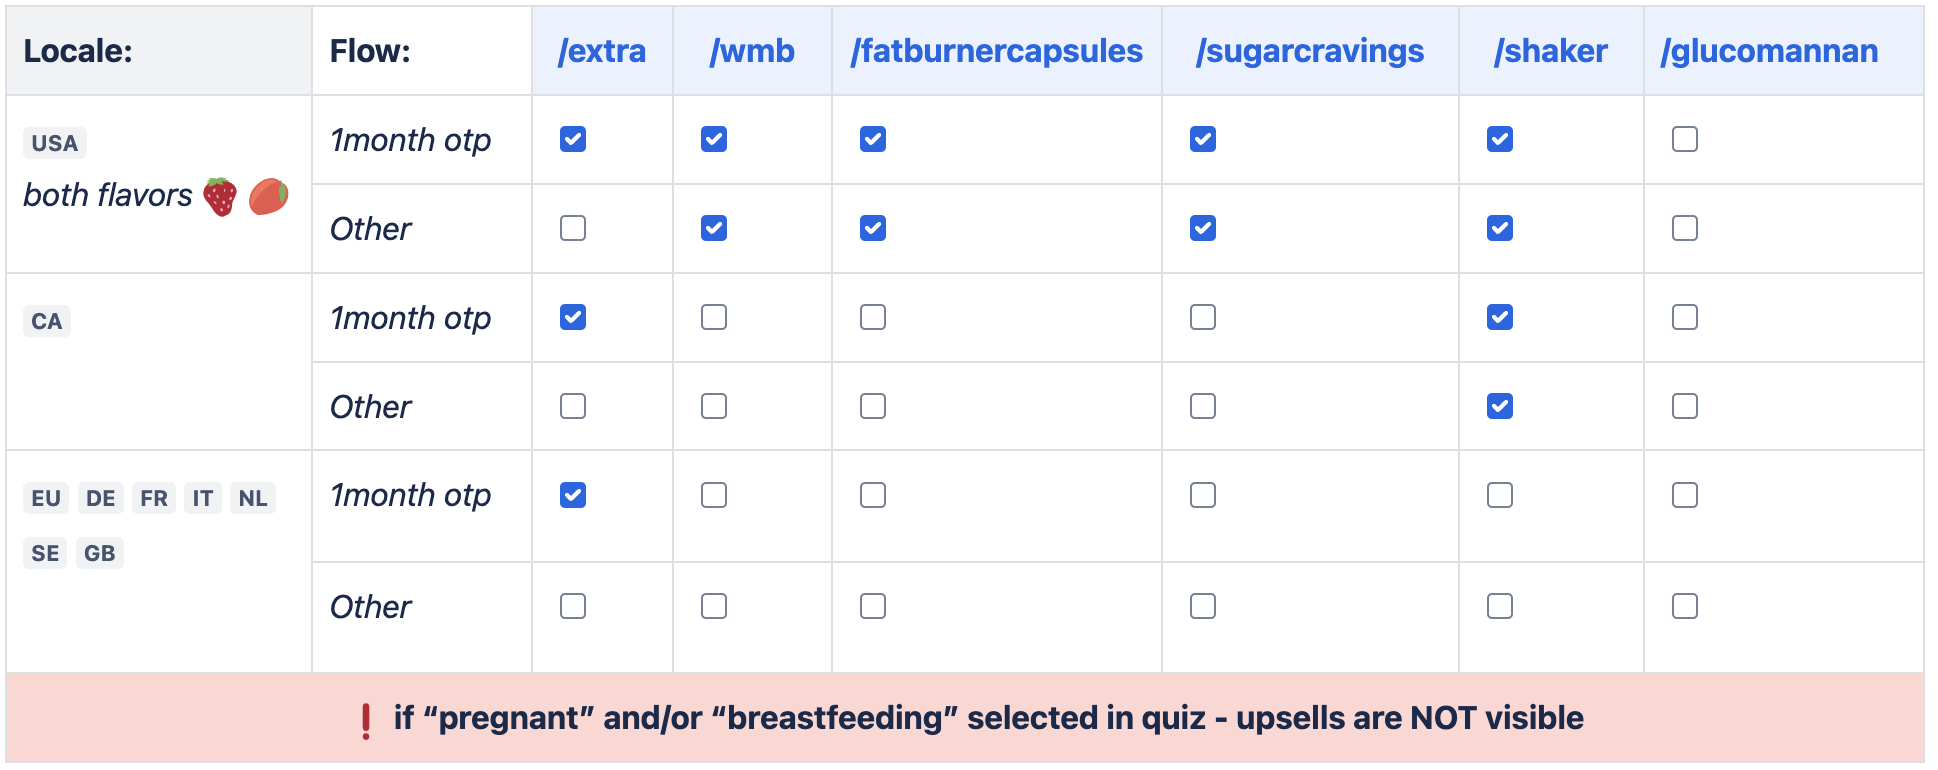

Adjusting class weights based on frequency of bought item

In [174]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [175]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

In [176]:
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


In [218]:
y_train_series = pd.Series(y_train)
class_counts = y_train_series.value_counts()
class_weights = class_counts.max() / class_counts
weights = np.array(class_weights.loc[y_train_series])

In [178]:
gb_clf = XGBClassifier(random_state=42)

In [179]:
param_grid = {
    'max_depth': [3, 6, 10],               
    'learning_rate': [0.01],        
    'n_estimators': [100, 200, 300],         
}
grid_search = GridSearchCV(gb_clf, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=3)


In [180]:
grid_search.fit(X_train_smote, y_train_smote)

best_gradient_boosting_clf = grid_search.best_estimator_

y_pred = best_gradient_boosting_clf.predict(X_test)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print(report)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
                   precision    recall  f1-score   support

            Extra       0.73      0.60      0.66       383
   Sugar Cravings       0.00      0.00      0.00        12
fatburnercapsules       0.09      0.13      0.11        39
      glucomannan       0.12      0.11      0.11        72
              wmb       0.02      0.03      0.02        31

         accuracy                           0.45       537
        macro avg       0.19      0.17      0.18       537
     weighted avg       0.54      0.45      0.49       537



In [220]:
param_grid = {
    'max_depth': [3, 6, 10, 13],               
    'learning_rate': [0.01, 0.1],        
    'n_estimators': [100, 200, 300, 500],         
}
grid_search = GridSearchCV(gb_clf, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=3)

In [221]:
grid_search.fit(X_train, y_train, sample_weight = weights)


best_gradient_boosting_clf_smote = grid_search.best_estimator_

y_pred = best_gradient_boosting_clf_smote.predict(X_test)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print(report)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
                   precision    recall  f1-score   support

            Extra       0.75      0.92      0.82       383
   Sugar Cravings       0.00      0.00      0.00        12
fatburnercapsules       0.12      0.03      0.04        39
      glucomannan       0.36      0.24      0.29        72
              wmb       0.00      0.00      0.00        31

         accuracy                           0.69       537
        macro avg       0.25      0.24      0.23       537
     weighted avg       0.59      0.69      0.63       537



In [185]:
param_distributions = {
    'max_depth': randint(3, 14),
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': randint(100, 501),
    'min_child_weight': randint(1, 10),
    'gamma': [0, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.7, 0.9],
    'colsample_bytree': [0.5, 0.7, 0.9],
    'colsample_bylevel': [0.5, 0.7, 0.9],
    'colsample_bynode': [0.5, 0.7, 0.9],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2],
    'scale_pos_weight': [1, 2, 3]
}
random_search = RandomizedSearchCV(
    estimator=gb_clf,
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

In [186]:
random_search.fit(X_train, y_train, sample_weight = weights)
best_gradient_boosting_random = random_search.best_estimator_

y_pred = best_gradient_boosting_random.predict(X_test)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print(report)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:160: UserWarning: [10:36:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


                   precision    recall  f1-score   support

            Extra       0.71      0.81      0.76       383
   Sugar Cravings       0.00      0.00      0.00        12
fatburnercapsules       0.04      0.03      0.03        39
      glucomannan       0.11      0.08      0.09        72
              wmb       0.00      0.00      0.00        31

         accuracy                           0.59       537
        macro avg       0.17      0.18      0.18       537
     weighted avg       0.52      0.59      0.55       537



To try to improve the accuracy of our model we use TF-IDF vectors once again for Quiz Responses

In [187]:
upsale_prediction_df_cleaned.loc[:,'Combined_Quiz'] = upsale_prediction_df_cleaned.apply(lambda row: ' '.join([row['quiz_linked_to'], row['quiz_poop'], row['quiz_symptoms'], row['quiz_symptoms_two'], row['quiz_allergies'],
 row['quiz_symptoms'], row['quiz_medical_conditions'],row['quiz_digestive'],row['quiz_physically_active'],row['quiz_pregnant'], row['quiz_breastfeeding']]), axis=1)

C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\1019010346.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upsale_prediction_df_cleaned.loc[:,'Combined_Quiz'] = upsale_prediction_df_cleaned.apply(lambda row: ' '.join([row['quiz_linked_to'], row['quiz_poop'], row['quiz_symptoms'], row['quiz_symptoms_two'], row['quiz_allergies'],


After new variable 'Combined_Quiz' is created we proceed to implement TF-IDF vectorizer

In [188]:
upsale_prediction_df_tfidf = upsale_prediction_df_cleaned

In [189]:
upsale_prediction_tdidf_1m_OTP = upsale_prediction_df_tfidf[upsale_prediction_df_tfidf['item_category_Colonbroom 1 Month OTP'] == True]

In [190]:
upsale_prediction_tdidf_1m_OTP['upsell_item'].value_counts()

upsell_item
Extra                1913
glucomannan           350
fatburnercapsules     196
wmb                   151
Sugar Cravings         73
Shakers                10
Name: count, dtype: int64

In [191]:
shakers_clients_df = upsale_prediction_tdidf_1m_OTP[upsale_prediction_tdidf_1m_OTP['upsell_item'] == 'Shakers']
client_ids_with_shakers = shakers_clients_df['client_id']
client_ids_list = client_ids_with_shakers.tolist()
client_ids_list

[1845.0,
 108411.0,
 108942.0,
 109693.0,
 110035.0,
 110132.0,
 110231.0,
 110640.0,
 110876.0,
 110953.0]

Deleting shakers from our analysis

In [192]:
mask = upsale_prediction_tdidf_1m_OTP['upsell_item'] != 'Shakers'
upsale_prediction_tdidf_1m_OTP = upsale_prediction_tdidf_1m_OTP[mask]

In [193]:
upsale_prediction_tdidf_1m_OTP['upsell_item'].value_counts()

upsell_item
Extra                1913
glucomannan           350
fatburnercapsules     196
wmb                   151
Sugar Cravings         73
Name: count, dtype: int64

In [194]:
upsale_prediction_tdidf_1m_OTP['Combined_Quiz'].count()

2683

Applying TF-IDF vectorization

In [195]:
vectorizer = TfidfVectorizer()
tfidf_matrix_upsell_predict =  vectorizer.fit_transform(upsale_prediction_tdidf_1m_OTP['Combined_Quiz'])
tfidf_matrix_upsell_predict.shape

(2683, 70)

In [196]:
X_upsell_predict_numeric = upsale_prediction_tdidf_1m_OTP[[    
    'quantity', 
    #'symptom_count', 
    #'allergy_count', 
    #'medical_count', 
    #'digestive_count',
    'scaled_age', 
    'scaled_starting_bmi', 
    'scaled_target_weight_in_kg',
    'scaled_starting_weight_in_kg',
    'scaled_amount_usd',
    'flavour_Strawberry',
    'flavour_Tropical',
    'sub_project_Premium',
    'is_supplement_Yes',
    'gender_male',
    #'gender_female',
     'item_category_Colonbroom 1 Month Subscription',
    'item_category_Colonbroom 3 Month Subscription',
    'item_category_Colonbroom 6 Month Subscription',
    'item_category_Colonbroom 3 Month OTP',
    'item_category_Colonbroom 6 Month OTP',
    'item_category_Colonbroom 1 Month OTP',
    'is_subscription_Yes'
    ]]

In [197]:
X_upsell_predict_numeric_1m_OTP = X_upsell_predict_numeric[X_upsell_predict_numeric['item_category_Colonbroom 1 Month OTP'] == True]

In [199]:
bool_columns = X_upsell_predict_numeric_1m_OTP.select_dtypes(include=['bool']).columns
X_upsell_predict_numeric_1m_OTP[bool_columns] = X_upsell_predict_numeric_1m_OTP[bool_columns].astype(int)

In [200]:
sparse_numerical_features_upsell_predict = scipy.sparse.csr_matrix(X_upsell_predict_numeric_1m_OTP.values)
sparse_numerical_features_upsell_predict.shape

(2683, 18)

In [203]:
X_upsell_vect_predict = hstack([sparse_numerical_features_upsell_predict, tfidf_matrix_upsell_predict])

In [201]:
y = upsale_prediction_tdidf_1m_OTP['upsell_item'] 
y_encoded = label_encoder.fit_transform(y)
y_upsell_vect_predict = y_encoded

In [222]:
X_train, X_test, y_train, y_test = train_test_split(X_upsell_vect_predict, y_upsell_vect_predict, test_size = 0.2, random_state = 42)

In [223]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

In [224]:
unique_classes, counts = np.unique(y_train, return_counts=True)
weights = {class_label: 1.0 / count for class_label, count in zip(unique_classes, counts)}
sample_weights = np.array([weights[class_label] for class_label in y_train])

In [225]:
class_names = label_encoder.classes_

In [229]:
param_grid = {
    'n_estimators': [100, 300,],
    'scale_pos_weight' :[15]
}
grid_search = GridSearchCV(
    gb_clf, 
    param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=3
)
grid_search.fit(X_train, y_train, sample_weight=sample_weights)


best_gradient_boosting_clf = grid_search.best_estimator_

y_pred = best_gradient_boosting_clf.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
                   precision    recall  f1-score   support

            Extra       0.71      1.00      0.83       383
   Sugar Cravings       0.00      0.00      0.00        12
fatburnercapsules       0.00      0.00      0.00        39
      glucomannan       0.00      0.00      0.00        72
              wmb       0.00      0.00      0.00        31

         accuracy                           0.71       537
        macro avg       0.14      0.20      0.17       537
     weighted avg       0.51      0.71      0.59       537



c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:160: UserWarning: [11:19:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifie

In [230]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [232]:
param_distributions = {
    'max_depth': randint(3, 14),
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': randint(100, 501),
    'scale_pos_weight': [1, 2, 3, 4, 5, 6]
}
random_search = RandomizedSearchCV(
    estimator=gb_clf,
    param_distributions=param_distributions,
    n_iter=2,
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1,
    scoring = 'f1_weighted'
)

In [235]:
param_grid = {
    'n_estimators': [100, 300,],
    'max_depth' :[3, 5, 9]
}
grid_search = GridSearchCV(
    gb_clf, 
    param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=3
)
grid_search.fit(X_train_smote, y_train_smote)


best_gradient_boosting_clf = grid_search.best_estimator_

y_pred = best_gradient_boosting_clf.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
                   precision    recall  f1-score   support

            Extra       0.73      0.93      0.82       383
   Sugar Cravings       0.00      0.00      0.00        12
fatburnercapsules       0.20      0.03      0.05        39
      glucomannan       0.28      0.14      0.19        72
              wmb       0.25      0.03      0.06        31

         accuracy                           0.69       537
        macro avg       0.29      0.23      0.22       537
     weighted avg       0.59      0.69      0.62       537



In [213]:
random_search.fit(X_train_smote, y_train_smote)
best_gradient_boosting_random = random_search.best_estimator_

y_pred = best_gradient_boosting_random.predict(X_test)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print(report)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:160: UserWarning: [11:09:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


                   precision    recall  f1-score   support

            Extra       0.74      0.95      0.83       383
   Sugar Cravings       0.00      0.00      0.00        12
fatburnercapsules       0.17      0.03      0.04        39
      glucomannan       0.35      0.15      0.21        72
              wmb       0.17      0.03      0.05        31

         accuracy                           0.70       537
        macro avg       0.29      0.23      0.23       537
     weighted avg       0.60      0.70      0.63       537



Evalute model on the validation set in comparison to current strategy employed by KiloHealth

In [240]:
current_strategy_predictions = np.zeros(len(y_val), dtype=int)
new_model_predictions = best_gradient_boosting_random.predict(X_val)

In [241]:
report_current = classification_report(y_val, current_strategy_predictions, target_names=label_encoder.classes_)
print(report_current)

                   precision    recall  f1-score   support

            Extra       0.71      1.00      0.83       380
   Sugar Cravings       0.00      0.00      0.00        21
fatburnercapsules       0.00      0.00      0.00        42
      glucomannan       0.00      0.00      0.00        65
              wmb       0.00      0.00      0.00        29

         accuracy                           0.71       537
        macro avg       0.14      0.20      0.17       537
     weighted avg       0.50      0.71      0.59       537



c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [242]:
report_new_model = classification_report(y_val, new_model_predictions, target_names=label_encoder.classes_)
print(report_new_model)

                   precision    recall  f1-score   support

            Extra       0.73      0.92      0.81       380
   Sugar Cravings       0.00      0.00      0.00        21
fatburnercapsules       0.22      0.05      0.08        42
      glucomannan       0.29      0.18      0.22        65
              wmb       0.00      0.00      0.00        29

         accuracy                           0.68       537
        macro avg       0.25      0.23      0.22       537
     weighted avg       0.57      0.68      0.61       537



The second part is building algorithm that takes into account all other initial purchases except of Colonbroom 1 Month OTP

For such initial purchase, upsell sequence is different and item 'extra' is not offered

In [243]:
upsale_prediction_other_colonbroom = upsale_prediction_df_cleaned[upsale_prediction_df_cleaned['item_category_Colonbroom 1 Month OTP'] == False]

In [245]:
upsale_prediction_other_colonbroom['item_category_Colonbroom 1 Month OTP'].value_counts()

item_category_Colonbroom 1 Month OTP
False    8160
Name: count, dtype: int64

In [251]:
upsale_prediction_other_colonbroom['upsell_item'].value_counts()

upsell_item
glucomannan          2990
wmb                  2946
fatburnercapsules    1536
Sugar Cravings        603
Shakers                53
Extra                  32
Name: count, dtype: int64

In [289]:
mask_3 = ~upsale_prediction_other_colonbroom['upsell_item'].isin(['Extra'])
upsale_prediction_other_colonbroom_clean = upsale_prediction_other_colonbroom[mask_3].copy()

In [290]:
upsale_prediction_other_colonbroom_clean['upsell_item'].value_counts()

upsell_item
glucomannan          2990
wmb                  2946
fatburnercapsules    1536
Sugar Cravings        603
Shakers                53
Name: count, dtype: int64

In [291]:
upsale_prediction_other_colonbroom_clean['Combined_Quiz'].count()

8128

In [292]:
vectorizer = TfidfVectorizer()
tfidf_matrix_upsell_predict_other =  vectorizer.fit_transform(upsale_prediction_other_colonbroom_clean['Combined_Quiz'])
tfidf_matrix_upsell_predict_other.shape

(8128, 71)

In [293]:
upsale_prediction_other_colonbroom_clean.head()

,client_id,quantity,is_upsell,order_id,item_amount_in_usd,country,age,starting_bmi,starting_weight_in_kg,target_weight_in_kg,quiz_health_state,quiz_linked_to,quiz_poop,quiz_symptoms,quiz_symptoms_two,quiz_allergies,quiz_medical_conditions,quiz_digestive,quiz_physically_active,quiz_leisure,quiz_pregnant,quiz_breastfeeding,lead_id,buyers,symptom_count,allergy_count,medical_count,digestive_count,flavour_Strawberry,flavour_Tropical,flavour_none,sub_project_Premium,is_subscription_Yes,is_supplement_Yes,gender_female,gender_male,upsell_id_upsale,log_amount_usd,log_log_amount_usd,log_age,log_starting_bmi,log_starting_weight_in_kg,log_target_weight_in_kg,scaled_age,scaled_amount_usd,scaled_starting_bmi,scaled_starting_weight_in_kg,scaled_target_weight_in_kg,item_category_Colonbroom 1 Month OTP,item_category_Colonbroom 1 Month Subscription,item_category_Colonbroom 3 Month OTP,item_category_Colonbroom 3 Month Subscription,item_category_Colonbroom 6 Month OTP,item_category_Colonbroom 6 Month Subscription,upsell_item,upsell_price,upsell_quantity,Combined_Quiz
13,15.0,3.0,No,2624600.0,131.96,United States,46.0,36.062435,86.64,80.29,good,"diarrhea, weight_gain",everyday,"breath, skin, sugar, rectal","digestion, skin",none,none,none,often,30-60min,undisclosed,no,NaN,Buyers,6,0,0,0,False,True,False,False,True,True,False,True,True,4.882499,1.585657,3.828641,3.585252,4.461762,4.385645,0.800482,0.379637,0.749447,-0.004728,0.506138,False,False,False,True,False,False,glucomannan,29.99,1.0,"diarrhea, weight_gain everyday breath, skin, s..."
22,26.0,3.0,No,2404110.0,137.97,United States,47.0,40.179012,130.18,99.79,average,"bloating, weight_gain",everyday,"sugar, Backache, rectal","appetite, pain",seafood,"cholesterol, thyroid",none,often,60-90min,undisclosed,no,NaN,Buyers,5,1,2,0,False,True,False,False,False,True,False,True,True,4.927036,1.594738,3.850148,3.693345,4.868918,4.603068,0.878857,0.430668,1.229110,1.723071,1.566099,False,False,True,False,False,False,wmb,49.99,1.0,"bloating, weight_gain everyday sugar, Backache..."
46,58.0,3.0,No,2711464.0,137.98,United States,38.0,24.121416,73.03,65.77,worse,"weight_gain, constipation, bloating",once,"heartburn, stomach, rectal, moodswings, Backac...","mood, pain, appetite, digestion",gluten,none,IBS,sometimes,60-90min,no,no,NaN,Buyers,10,1,0,1,True,False,False,False,False,True,True,False,True,4.927109,1.594752,3.637586,3.183100,4.290870,4.186164,0.104216,0.430751,-1.035103,-0.729918,-0.466357,False,False,True,False,False,False,glucomannan,77.97,1.0,"weight_gain, constipation, bloating once heart..."
71,88.0,3.0,No,2495701.0,179.97,United States,59.0,23.799383,77.11,72.57,average,"constipation, weight_gain, bloating",everyday,Backache,none,none,other,IBS,often,30-60min,undisclosed,no,NaN,Buyers,1,0,1,1,False,False,False,True,False,True,False,True,True,5.192790,1.647271,4.077537,3.169660,4.345233,4.284552,1.707538,0.725902,-1.094745,-0.499226,0.013295,False,False,True,False,False,False,wmb,107.97,3.0,"constipation, weight_gain, bloating everyday B..."
93,110.0,6.0,No,2711647.0,143.93,United States,36.0,28.700617,92.99,77.11,worse,"weight_gain, bloating",everyday,"sugar, heartburn, stomach, Backache",pain,none,gout,none,sometimes,30-60min,undisclosed,no,NaN,Buyers,5,0,1,0,True,False,False,False,True,True,False,True,True,4.969327,1.603284,3.583519,3.356919,4.532492,4.345233,-0.092822,0.478700,-0.263782,0.295422,0.309124,False,False,False,False,False,True,glucomannan,134.94,2.0,"weight_gain, bloating everyday sugar, heartbur..."


In [294]:
X_upsell_predict_numeric_other = upsale_prediction_other_colonbroom_clean[[    
    'quantity', 
    'symptom_count', 
    'allergy_count', 
    'medical_count', 
    'digestive_count',
    'scaled_age', 
    'scaled_starting_bmi', 
    'scaled_target_weight_in_kg',
    'scaled_starting_weight_in_kg',
    'scaled_amount_usd',
    'flavour_Strawberry',
    'flavour_Tropical',
    'flavour_none',
    'sub_project_Premium',
    'is_supplement_Yes',
    'gender_male',
    #'gender_female',
     'item_category_Colonbroom 1 Month Subscription',
    'item_category_Colonbroom 3 Month Subscription',
    'item_category_Colonbroom 6 Month Subscription',
    'item_category_Colonbroom 3 Month OTP',
    'item_category_Colonbroom 6 Month OTP',
    'item_category_Colonbroom 1 Month OTP',
    'is_subscription_Yes'
    ]]

In [295]:
X_upsell_predict_numeric_other['item_category_Colonbroom 1 Month OTP'].value_counts()

item_category_Colonbroom 1 Month OTP
False    8128
Name: count, dtype: int64

In [296]:
bool_columns = X_upsell_predict_numeric_other.select_dtypes(include=['bool']).columns
X_upsell_predict_numeric_other[bool_columns] = X_upsell_predict_numeric_other[bool_columns].astype(int)

C:\Users\Tomas\AppData\Local\Temp\ipykernel_2844\1486887366.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_upsell_predict_numeric_other[bool_columns] = X_upsell_predict_numeric_other[bool_columns].astype(int)


In [297]:
sparse_numerical_features_upsell_predict_other = scipy.sparse.csr_matrix(X_upsell_predict_numeric_other.values)
sparse_numerical_features_upsell_predict_other.shape

(8128, 23)

In [298]:
X_upsell_vect_predict_other = hstack([sparse_numerical_features_upsell_predict_other, tfidf_matrix_upsell_predict_other])

In [299]:
y = upsale_prediction_other_colonbroom_clean['upsell_item'] 
y_encoded = label_encoder.fit_transform(y)
y_upsell_vect_predict_other = y_encoded

In [300]:
y.count()

8128

In [301]:
X_train, X_test, y_train, y_test = train_test_split(X_upsell_vect_predict_other, y_upsell_vect_predict_other, test_size = 0.2, random_state = 42)

In [302]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

In [303]:
unique_classes, counts = np.unique(y_train, return_counts=True)
weights = {class_label: 1.0 / count for class_label, count in zip(unique_classes, counts)}
sample_weights = np.array([weights[class_label] for class_label in y_train])

In [304]:
class_names = label_encoder.classes_

In [307]:
param_grid = {
    'n_estimators': [100, 300,],
}
grid_search = GridSearchCV(
    gb_clf, 
    param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=3
)
grid_search.fit(X_train, y_train)


best_gradient_boosting_clf = grid_search.best_estimator_

y_pred = best_gradient_boosting_clf.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        11
   Sugar Cravings       0.15      0.02      0.03       127
fatburnercapsules       0.36      0.16      0.22       313
      glucomannan       0.68      0.81      0.74       603
              wmb       0.62      0.81      0.70       572

         accuracy                           0.62      1626
        macro avg       0.36      0.36      0.34      1626
     weighted avg       0.55      0.62      0.56      1626



c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [308]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [328]:
param_grid = {
    'n_estimators': [100, 300,],
}
grid_search = GridSearchCV(
    gb_clf, 
    param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=3
)
grid_search.fit(X_train_smote, y_train_smote)


best_gradient_boosting_clf = grid_search.best_estimator_

y_pred = best_gradient_boosting_clf.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        11
   Sugar Cravings       0.14      0.02      0.04       127
fatburnercapsules       0.29      0.18      0.22       313
      glucomannan       0.67      0.76      0.71       603
              wmb       0.59      0.76      0.67       572

         accuracy                           0.59      1626
        macro avg       0.34      0.34      0.33      1626
     weighted avg       0.53      0.59      0.55      1626



In [310]:
param_distributions = {
    'max_depth': randint(3, 14),
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': randint(100, 501),
}
random_search = RandomizedSearchCV(
    estimator=gb_clf,
    param_distributions=param_distributions,
    n_iter=4,
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1,
    scoring = 'f1_weighted'
)

In [311]:
random_search.fit(X_train_smote, y_train_smote)
best_gradient_boosting_random = random_search.best_estimator_

y_pred = best_gradient_boosting_random.predict(X_test)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print(report)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        11
   Sugar Cravings       0.08      0.01      0.01       127
fatburnercapsules       0.30      0.14      0.19       313
      glucomannan       0.67      0.78      0.72       603
              wmb       0.60      0.80      0.68       572

         accuracy                           0.60      1626
        macro avg       0.33      0.35      0.32      1626
     weighted avg       0.52      0.60      0.54      1626



c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [312]:
param_distributions = {
    'max_depth': randint(3, 14),
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': randint(100, 501),
}
random_search = RandomizedSearchCV(
    estimator=gb_clf,
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1,
    scoring = 'f1_weighted'
)

In [313]:
random_search.fit(X_train_smote, y_train_smote)
best_gradient_boosting_random = random_search.best_estimator_

y_pred = best_gradient_boosting_random.predict(X_test)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print(report)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        11
   Sugar Cravings       0.18      0.02      0.03       127
fatburnercapsules       0.32      0.15      0.21       313
      glucomannan       0.68      0.78      0.73       603
              wmb       0.60      0.80      0.69       572

         accuracy                           0.60      1626
        macro avg       0.36      0.35      0.33      1626
     weighted avg       0.54      0.60      0.55      1626



c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Tomas\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

Comparing current KiloHealth strategy to our predictory model

In [323]:
current_strategy_predictions = np.full(len(y_val), 4, dtype=int)
new_model_predictions = best_gradient_boosting_random.predict(X_val)

Current KiloHealth model implementation on validation set

In [327]:
report_current = classification_report(y_val, current_strategy_predictions, target_names=label_encoder.classes_)
print(report_current)

                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        16
   Sugar Cravings       0.00      0.00      0.00       123
fatburnercapsules       0.00      0.00      0.00       287
      glucomannan       0.00      0.00      0.00       611
              wmb       0.36      1.00      0.53       589

         accuracy                           0.36      1626
        macro avg       0.07      0.20      0.11      1626
     weighted avg       0.13      0.36      0.19      1626



Evaluating our best model on validation set

In [326]:
report_new_model = classification_report(y_val, new_model_predictions, target_names=label_encoder.classes_)
print(report_new_model)

                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        16
   Sugar Cravings       0.06      0.01      0.01       123
fatburnercapsules       0.32      0.16      0.21       287
      glucomannan       0.71      0.81      0.76       611
              wmb       0.61      0.80      0.70       589

         accuracy                           0.63      1626
        macro avg       0.34      0.36      0.34      1626
     weighted avg       0.55      0.63      0.58      1626



Mapping out feature importances

In [315]:
numerical_feature_names = X_upsell_predict_numeric_other.columns.tolist()
tfidf_feature_names = vectorizer.get_feature_names_out()  
combined_feature_names = numerical_feature_names + list(tfidf_feature_names)
importances = best_gradient_boosting_random.feature_importances_
feature_importance_dict = {name: score for name, score in zip(combined_feature_names, importances)}

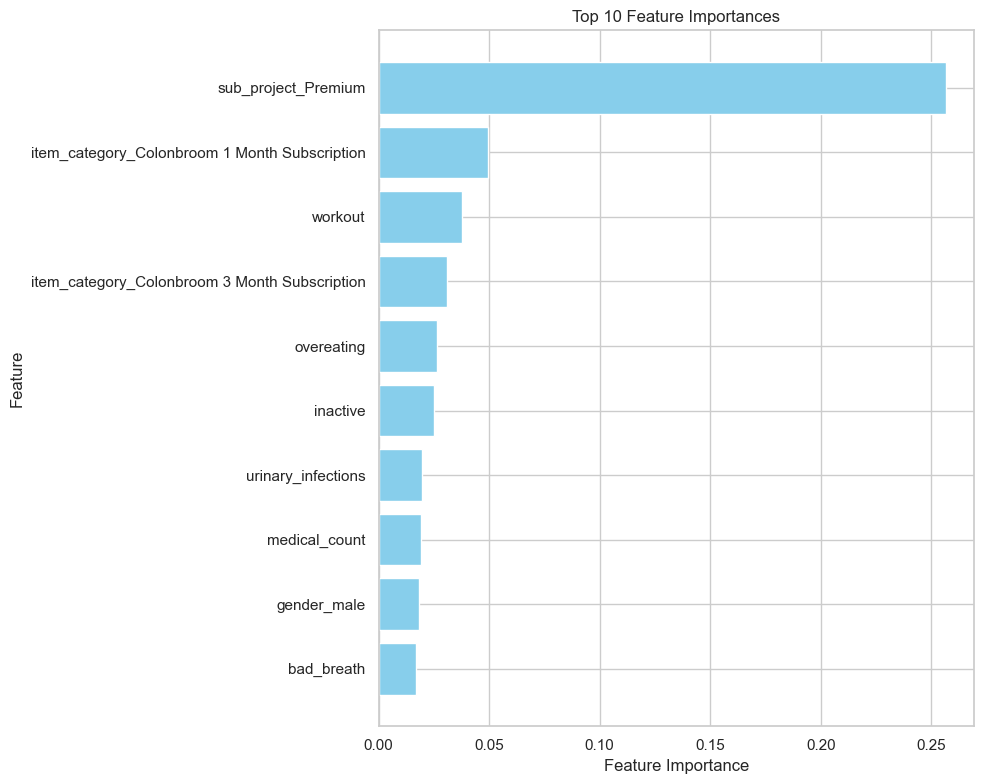

In [319]:
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)
top_features = sorted_features[:10]
top_feature_names, top_importances = zip(*top_features)
plt.figure(figsize=(10, 8))
plt.barh(range(len(top_feature_names)), top_importances, color='skyblue')
plt.yticks(range(len(top_feature_names)), top_feature_names)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()  
plt.tight_layout()  
plt.show()

Our final predictory model part consists of running the same models, but removing 'glucommanan' observation since it is not offered for upsell by the company

In [330]:
mask_4 = ~upsale_prediction_other_colonbroom['upsell_item'].isin(['Extra', 'glucomannan'])
upsale_prediction_other_colonbroom_clean_new = upsale_prediction_other_colonbroom[mask_4].copy()

After removing glucomannan upsells

In [332]:
upsale_prediction_other_colonbroom_clean_new['upsell_item'].value_counts()

upsell_item
wmb                  2946
fatburnercapsules    1536
Sugar Cravings        603
Shakers                53
Name: count, dtype: int64

In [334]:
upsale_prediction_other_colonbroom_clean_new['Combined_Quiz'].count()

5138

In [335]:
vectorizer = TfidfVectorizer()
tfidf_matrix_upsell_predict_other_new =  vectorizer.fit_transform(upsale_prediction_other_colonbroom_clean_new['Combined_Quiz'])
tfidf_matrix_upsell_predict_other_new.shape

(5138, 71)

In [336]:
X_upsell_predict_numeric_other_new = upsale_prediction_other_colonbroom_clean_new[[    
    'quantity', 
    'symptom_count', 
    'allergy_count', 
    'medical_count', 
    'digestive_count',
    'scaled_age', 
    'scaled_starting_bmi', 
    'scaled_target_weight_in_kg',
    'scaled_starting_weight_in_kg',
    'scaled_amount_usd',
    'flavour_Strawberry',
    'flavour_Tropical',
    'flavour_none',
    'sub_project_Premium',
    'is_supplement_Yes',
    'gender_male',
    #'gender_female',
     'item_category_Colonbroom 1 Month Subscription',
    'item_category_Colonbroom 3 Month Subscription',
    'item_category_Colonbroom 6 Month Subscription',
    'item_category_Colonbroom 3 Month OTP',
    'item_category_Colonbroom 6 Month OTP',
    'item_category_Colonbroom 1 Month OTP',
    'is_subscription_Yes'
    ]]

In [337]:
bool_columns = X_upsell_predict_numeric_other_new.select_dtypes(include=['bool']).columns
X_upsell_predict_numeric_other_new[bool_columns] = X_upsell_predict_numeric_other_new[bool_columns].astype(int)

In [338]:
sparse_numerical_features_upsell_predict_other_new = scipy.sparse.csr_matrix(X_upsell_predict_numeric_other_new.values)
sparse_numerical_features_upsell_predict_other_new.shape

(5138, 23)

In [339]:
X_upsell_vect_predict_other_new = hstack([sparse_numerical_features_upsell_predict_other_new, tfidf_matrix_upsell_predict_other_new])

In [340]:
y = upsale_prediction_other_colonbroom_clean_new['upsell_item'] 
y_encoded = label_encoder.fit_transform(y)
y_upsell_vect_predict_other_new = y_encoded

In [341]:
y.count()

5138

In [342]:
X_train, X_test, y_train, y_test = train_test_split(X_upsell_vect_predict_other_new, y_upsell_vect_predict_other_new, test_size = 0.2, random_state = 42)

In [343]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

In [344]:
unique_classes, counts = np.unique(y_train, return_counts=True)
weights = {class_label: 1.0 / count for class_label, count in zip(unique_classes, counts)}
sample_weights = np.array([weights[class_label] for class_label in y_train])

In [345]:
class_names = label_encoder.classes_

In [346]:
param_grid = {
    'n_estimators': [100, 300,],
}
grid_search = GridSearchCV(
    gb_clf, 
    param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=3
)
grid_search.fit(X_train, y_train)


best_gradient_boosting_clf = grid_search.best_estimator_

y_pred = best_gradient_boosting_clf.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        11
   Sugar Cravings       0.14      0.05      0.08       115
fatburnercapsules       0.46      0.37      0.41       319
              wmb       0.63      0.79      0.70       583

         accuracy                           0.57      1028
        macro avg       0.31      0.30      0.30      1028
     weighted avg       0.52      0.57      0.53      1028



In [347]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [348]:
param_grid = {
    'n_estimators': [100, 300,],
}
grid_search = GridSearchCV(
    gb_clf, 
    param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=3
)
grid_search.fit(X_train_smote, y_train_smote)


best_gradient_boosting_clf = grid_search.best_estimator_

y_pred = best_gradient_boosting_clf.predict(X_test)
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        11
   Sugar Cravings       0.29      0.14      0.19       115
fatburnercapsules       0.43      0.35      0.39       319
              wmb       0.64      0.77      0.70       583

         accuracy                           0.56      1028
        macro avg       0.34      0.32      0.32      1028
     weighted avg       0.52      0.56      0.54      1028



In [351]:
param_distributions = {
    'max_depth': randint(3, 14),
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': randint(100, 501),
}
random_search = RandomizedSearchCV(
    estimator=gb_clf,
    param_distributions=param_distributions,
    n_iter=28,
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1,
    scoring = 'f1_weighted'
)

In [352]:
random_search.fit(X_train_smote, y_train_smote)
best_gradient_boosting_random = random_search.best_estimator_

y_pred = best_gradient_boosting_random.predict(X_test)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print(report)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        11
   Sugar Cravings       0.21      0.09      0.12       115
fatburnercapsules       0.46      0.34      0.39       319
              wmb       0.64      0.82      0.72       583

         accuracy                           0.58      1028
        macro avg       0.33      0.31      0.31      1028
     weighted avg       0.53      0.58      0.54      1028



In [353]:
current_strategy_predictions = np.full(len(y_val), 3, dtype=int)
new_model_predictions = best_gradient_boosting_random.predict(X_val)

In [354]:
report_current = classification_report(y_val, current_strategy_predictions, target_names=label_encoder.classes_)
print(report_current)

                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        14
   Sugar Cravings       0.00      0.00      0.00       109
fatburnercapsules       0.00      0.00      0.00       329
              wmb       0.56      1.00      0.72       576

         accuracy                           0.56      1028
        macro avg       0.14      0.25      0.18      1028
     weighted avg       0.31      0.56      0.40      1028



In [355]:
report_new_model = classification_report(y_val, new_model_predictions, target_names=label_encoder.classes_)
print(report_new_model)

                   precision    recall  f1-score   support

          Shakers       0.00      0.00      0.00        14
   Sugar Cravings       0.31      0.14      0.19       109
fatburnercapsules       0.49      0.38      0.43       329
              wmb       0.65      0.81      0.72       576

         accuracy                           0.59      1028
        macro avg       0.36      0.33      0.33      1028
     weighted avg       0.55      0.59      0.56      1028

